# 10. Portfolio Optimization: Tail risk, Risk Parity and Robust Models

In [1]:
from pathlib import Path
import warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import cvxpy as cp
from cycler import cycler
from IPython.display import display
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import covariance, expected_returns, selection, attribution
from quantfinlab.portfolio import prices_to_returns, make_rebalance_dates
from quantfinlab.portfolio.covariance import make_psd
from quantfinlab.portfolio.walkforward import run_walkforward_grid, append_frontiergrid_from_best_maxsharpe
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import views as bl_views
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.risk import drawdown_episodes_table, drawdown_summary_table, stress_table, var_es_table, capm_table, rolling_volatility
from quantfinlab.plotting.portfolio import plot_strategy_nav, plot_strategy_drawdowns
from quantfinlab.reports import risk_report
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7", "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({"figure.figsize": (7, 3.5), "figure.dpi": 140, "savefig.dpi": 250, "axes.grid": True, "grid.alpha": 0.20, "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 11, "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8})
project_title = "Portfolio Optimization Models: Tail risk, Risk Parity and Robust Optimization"
repo_root = Path.cwd()
if not (repo_root / "data" / "ETF_data.csv").exists() and (repo_root.parent / "data" / "ETF_data.csv").exists():
    repo_root = repo_root.parent
data_path = repo_root / "data" / "ETF_data.csv"


In [2]:
loaded = load_yfinance_panel(data_path, fields=("close",), source="yfinance_export", lowercase=False)
close_all = loaded["close"].sort_index()
print(project_title)
print("loaded close table:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())


Portfolio Optimization Models: Tail risk, Risk Parity and Robust Optimization
loaded close table: (4111, 63) 2010-01-04 to 2026-05-07


In [3]:
start_date = "2013-01-01"
assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "IEF", "SHY", "AGG", "LQD", "HYG", "GLD", "VNQ", "DBC"]
signal_only_assets = ["UUP"] if "UUP" in close_all.columns else []
close_after_start = close_all.loc[pd.Timestamp(start_date):].copy()
missing_assets = [ticker for ticker in assets if ticker not in close_after_start.columns]
if missing_assets:
    raise ValueError(f"missing required investable ETF columns: {missing_assets}")
first_all_valid = close_after_start[assets].dropna(how="any").index.min()
if pd.isna(first_all_valid):
    raise ValueError("no date where all investable ETFs have adjusted close data")
close = close_after_start.loc[first_all_valid:, assets].ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)
close = close.reindex(returns.index).ffill(limit=3)
signal_tickers = list(dict.fromkeys(assets + signal_only_assets))
signal_close = close_after_start.loc[first_all_valid:, signal_tickers].ffill(limit=3).reindex(returns.index).ffill(limit=3)
signal_returns = prices_to_returns(signal_close, kind="simple").replace([np.inf, -np.inf], np.nan).reindex(returns.index).fillna(0.0)


In [4]:
coverage_rows = []
for ticker in assets + signal_only_assets:
    px = close_after_start[ticker]
    valid = px.dropna()
    first = valid.index.min() if len(valid) else pd.NaT
    coverage_rows.append({"ticker": ticker, "first_date": first, "last_date": valid.index.max() if len(valid) else pd.NaT, "observations": int(len(valid)), "missing_after_first_valid": float(px.loc[first:].isna().sum()) if len(valid) else np.nan, "investable": ticker in assets})
coverage_table = pd.DataFrame(coverage_rows)
data_table = pd.DataFrame([{"number_of_assets": len(assets), "first_date": returns.index.min(), "last_date": returns.index.max(), "daily_return_rows": len(returns), "missing_values_after_alignment": int(returns[assets].isna().sum().sum())}])
display(data_table)
display(coverage_table)
print("signal assets:", list(signal_returns.columns))


,number_of_assets,first_date,last_date,daily_return_rows,missing_values_after_alignment
0,14,2013-01-03,2026-05-07,3356,0


,ticker,first_date,last_date,observations,missing_after_first_valid,investable
0,SPY,2013-01-02,2026-05-07,3357,0.0,True
1,QQQ,2013-01-02,2026-05-07,3357,0.0,True
2,IWM,2013-01-02,2026-05-07,3357,0.0,True
3,EFA,2013-01-02,2026-05-07,3357,0.0,True
4,EEM,2013-01-02,2026-05-07,3357,0.0,True
5,TLT,2013-01-02,2026-05-07,3357,0.0,True
6,IEF,2013-01-02,2026-05-07,3357,0.0,True
7,SHY,2013-01-02,2026-05-07,3357,0.0,True
8,AGG,2013-01-02,2026-05-07,3357,0.0,True
9,LQD,2013-01-02,2026-05-07,3357,0.0,True


signal assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'LQD', 'HYG', 'GLD', 'VNQ', 'DBC', 'UUP']


In [5]:
rebal_freq = "ME"
cov_lookback = 756
mu_lookback = 252
annualization = 252
ewma_lambda = 0.97
risk_free_rate_annual = 0.04
risk_free_daily = (1 + risk_free_rate_annual) ** (1 / annualization) - 1
cost_bps = 10.0
w_min = 0.0
w_max = 0.40
mv_lambda = 6.0
fixed_benchmark_weights = {"SPY": 0.24, "QQQ": 0.10, "IWM": 0.06, "EFA": 0.12, "EEM": 0.06, "TLT": 0.10, "IEF": 0.08, "SHY": 0.04, "AGG": 0.06, "LQD": 0.04, "HYG": 0.03, "GLD": 0.05, "VNQ": 0.04, "DBC": 0.04}
benchmark_w = pd.Series(fixed_benchmark_weights, dtype=float).reindex(assets).fillna(0.0)
benchmark_w = benchmark_w / float(benchmark_w.sum())
sleeve_groups = {"equities": ["SPY", "QQQ", "IWM", "EFA", "EEM"], "duration": ["TLT", "IEF", "SHY", "AGG"], "credit": ["LQD", "HYG"], "diversifiers": ["GLD", "VNQ", "DBC"]}
sleeve_map = {asset: sleeve for sleeve, names in sleeve_groups.items() for asset in names}
asset_cap_map = {"SPY": 0.35, "QQQ": 0.25, "IWM": 0.15, "EFA": 0.20, "EEM": 0.15, "TLT": 0.25, "IEF": 0.25, "SHY": 0.20, "AGG": 0.25, "LQD": 0.15, "HYG": 0.08, "GLD": 0.10, "VNQ": 0.08, "DBC": 0.05}
asset_caps = pd.Series({asset: asset_cap_map.get(asset, w_max) for asset in assets}, index=assets, dtype=float)


In [6]:
rebalance_dates = make_rebalance_dates(returns.index, freq=rebal_freq, min_history_days=max(cov_lookback, mu_lookback, 756))
fixed_universe_by_date = {pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)} for dt in rebalance_dates}
universe_table = pd.DataFrame({"asset": assets, "sleeve": [sleeve_map.get(asset, "other") for asset in assets], "asset_cap": asset_caps.reindex(assets).values})
benchmark_table = pd.DataFrame({"asset": assets, "sleeve": [sleeve_map.get(asset, "other") for asset in assets], "benchmark_weight": benchmark_w.reindex(assets).values, "asset_cap": asset_caps.reindex(assets).values})
rebalance_summary = pd.DataFrame([{"count": len(rebalance_dates), "first_rebalance": rebalance_dates[0], "last_rebalance": rebalance_dates[-1], "frequency": rebal_freq, "cov_lookback": cov_lookback, "mu_lookback": mu_lookback}])
display(universe_table)
display(benchmark_table.round(4))
display(rebalance_summary)


,asset,sleeve,asset_cap
0,SPY,equities,0.35
1,QQQ,equities,0.25
2,IWM,equities,0.15
3,EFA,equities,0.20
4,EEM,equities,0.15
5,TLT,duration,0.25
6,IEF,duration,0.25
7,SHY,duration,0.20
8,AGG,duration,0.25
9,LQD,credit,0.15


,asset,sleeve,benchmark_weight,asset_cap
0,SPY,equities,0.2264,0.35
1,QQQ,equities,0.0943,0.25
2,IWM,equities,0.0566,0.15
3,EFA,equities,0.1132,0.20
4,EEM,equities,0.0566,0.15
5,TLT,duration,0.0943,0.25
6,IEF,duration,0.0755,0.25
7,SHY,duration,0.0377,0.20
8,AGG,duration,0.0566,0.25
9,LQD,credit,0.0377,0.15


,count,first_rebalance,last_rebalance,frequency,cov_lookback,mu_lookback
0,125,2016-01-29,2026-05-07,ME,756,252


In [7]:
cov_models = {"Sample": covariance.sample_covariance, "LedoitWolf": covariance.ledoit_wolf_covariance, "OAS": covariance.oas_covariance, "EWMA": covariance.ewma_covariance}
mu_models = {"Momentum": expected_returns.momentum_mu, "BayesStein": expected_returns.bayes_stein_mu, "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu}
walkforward_grid = run_walkforward_grid(returns=returns[assets], close=close[assets], rebalance_dates=rebalance_dates, universe_by_date=fixed_universe_by_date, cov_models=cov_models, mu_models=mu_models, cov_lookback=cov_lookback, mu_lookback=mu_lookback, min_cov_observations=cov_lookback - 1, min_mu_observations=mu_lookback - 1, max_weight=w_max, min_weight=w_min, long_only=True, trading_cost_bps=cost_bps, turnover_penalty_bps=cost_bps, fallback="equal", rf_daily=risk_free_daily, annualization=annualization, ewma_lambda=ewma_lambda, optimizer_params={"MV": {"mv_lambda": mv_lambda}, "RidgeMV": {"mv_lambda": mv_lambda}, "FrontierGrid": {"grid_n": 15}})
walkforward_grid = append_frontiergrid_from_best_maxsharpe(walkforward_grid, grid_n=15)


In [8]:
def ordered_strategy_table(table):
    cols = ["Sharpe", "Max Drawdown", "Turnover", "CAGR"]
    ascending = [False, False, True, False]
    present = [col for col in cols if col in table.columns]
    asc = [ascending[cols.index(col)] for col in present]
    return table.replace([np.inf, -np.inf], np.nan).sort_values(present, ascending=asc)
benchmark_summary = walkforward_grid.results.copy()
benchmark_summary_ranked = ordered_strategy_table(benchmark_summary)

In [9]:
def pick_best_strategy(summary, optimizer):
    candidates = summary[summary["Optimizer"].eq(optimizer)].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if candidates.empty:
        return None
    return str(ordered_strategy_table(candidates).index[0])
grid_equal_weight_name = "EW" if "EW" in walkforward_grid.backtests else pick_best_strategy(benchmark_summary, "EW")
best_minvar_name = pick_best_strategy(benchmark_summary, "MinVar")
best_mv_name = pick_best_strategy(benchmark_summary, "MV")
best_maxsharpe_name = pick_best_strategy(benchmark_summary, "MaxSharpe")
if best_maxsharpe_name is None:
    best_maxsharpe_name = pick_best_strategy(benchmark_summary, "FrontierGrid")
if grid_equal_weight_name is None or best_minvar_name is None or best_mv_name is None or best_maxsharpe_name is None:
    raise ValueError("could not select all required benchmark strategies from the walk-forward grid")
_, _, best_minvar_cov = selection.parse_strategy_spec(best_minvar_name, walkforward_grid.backtests[best_minvar_name])
_, best_mv_mu, best_mv_cov = selection.parse_strategy_spec(best_mv_name, walkforward_grid.backtests[best_mv_name])
_, best_maxsharpe_mu, best_maxsharpe_cov = selection.parse_strategy_spec(best_maxsharpe_name, walkforward_grid.backtests[best_maxsharpe_name])
benchmark_results = {"Equal Weight": walkforward_grid.backtests[grid_equal_weight_name], best_minvar_name: walkforward_grid.backtests[best_minvar_name], best_mv_name: walkforward_grid.backtests[best_mv_name], best_maxsharpe_name: walkforward_grid.backtests[best_maxsharpe_name]}
selected_benchmark_names = pd.Series({"equal_weight_name": grid_equal_weight_name, "best_minvar_name": best_minvar_name, "best_mv_name": best_mv_name, "best_maxsharpe_name": best_maxsharpe_name, "best_minvar_cov": best_minvar_cov, "best_mv_cov": best_mv_cov, "best_mv_mu": best_mv_mu, "best_maxsharpe_cov": best_maxsharpe_cov, "best_maxsharpe_mu": best_maxsharpe_mu})
selected_benchmark_table = benchmark_summary.loc[[grid_equal_weight_name, best_minvar_name, best_mv_name, best_maxsharpe_name]].copy()
print(selected_benchmark_names.to_string())
display(selected_benchmark_table.round(4))


equal_weight_name                                    EW
best_minvar_name                           MinVar (OAS)
best_mv_name                MV (LedoitWolf, BayesStein)
best_maxsharpe_name    MaxSharpe (LedoitWolf, Momentum)
best_minvar_cov                                     OAS
best_mv_cov                                  LedoitWolf
best_mv_mu                                   BayesStein
best_maxsharpe_cov                           LedoitWolf
best_maxsharpe_mu                              Momentum


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
EW,EW,-,-,0.0855,0.0933,0.4916,-0.2041,0.4187,0.6029,0.0114,1.4252,0.0010,14.0000,0
MinVar (OAS),MinVar,-,OAS,0.0686,0.0754,0.3806,-0.1975,0.3476,0.4338,0.0031,0.3903,0.0003,9.1867,0
"MV (LedoitWolf, BayesStein)",MV,BayesStein,LedoitWolf,0.0735,0.0687,0.4860,-0.1181,0.6225,0.5852,0.0270,3.3724,0.0021,4.8250,0
"MaxSharpe (LedoitWolf, Momentum)",MaxSharpe,Momentum,LedoitWolf,0.1179,0.1132,0.6908,-0.1546,0.7623,0.8527,0.2730,34.1262,0.0182,3.2789,0


In [10]:
family_q_caps = {"liquid_leadership": 0.042, "dual_momentum": 0.022, "inflation_rotation": 0.024, "risk_adj_momentum": 0.014, "credit_switch": 0.010, "reflation_breadth": 0.042, "growth_duration": 0.032, "correlation_stress": 0.024, "international_rotation": 0.018, "duration_quality": 0.010}
roles = {"assets": assets, "risk_assets": ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"], "risky": ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"], "cyclical": ["IWM", "EEM", "VNQ", "HYG"], "defensive": ["TLT", "IEF", "SHY", "AGG", "LQD", "GLD"], "duration": ["TLT", "IEF", "SHY", "AGG"], "credit": ["LQD", "HYG"], "real_assets": ["GLD", "VNQ", "DBC"], "international": ["EFA", "EEM"], "growth": ["QQQ", "SPY"], "small_caps": ["IWM"], "dollar": ["UUP"] if "UUP" in signal_returns.columns else [], "sleeve_map": sleeve_map}
view_settings = bl_views.ViewSettings(family_q_caps=family_q_caps, family_display_names=bl_views.DEFAULT_PRIMARY_DISPLAY_NAMES, assets=assets, annualization=annualization, entry_z=0.50, q_strength_scale=1.25, view_horizon_days=21)
bl_settings = bl.BLSettings(rebalance_freq=rebal_freq, cov_lookback=cov_lookback, mu_lookback=mu_lookback, annualization=annualization, risk_free_rate_annual=risk_free_rate_annual, tau=0.05, ewma_lambda=ewma_lambda, delta_fallback=2.5, delta_min=0.50, delta_max=8.00, transaction_cost_bps=cost_bps, max_weight=w_max, min_weight=w_min, active_weight_limit=0.15, active_weight_relaxed=0.22, max_selected_views=len(family_q_caps), redundancy_similarity=0.85, max_same_direction=3, confidence_mode="learned", use_learned_q=True, full_view_covariance=True, empirical_omega_rescale=False, posterior_mu_clip=0.30, te_gamma_fallback=3.0)
view_functions = [bl_views.liquid_leadership, bl_views.dual_momentum, bl_views.inflation_rotation, bl_views.risk_adjusted_momentum, bl_views.credit_switch, bl_views.reflation_breadth, bl_views.growth_duration, bl_views.correlation_stress, bl_views.international_rotation, bl_views.duration_quality]
bl_constraints = {"asset_caps": asset_caps.to_dict()}


In [11]:
learned_bl_run = bl.learned_confidence_bl(returns=returns[assets], signal_returns=signal_returns, rebalance_dates=rebalance_dates, benchmark_weights=benchmark_w, roles=roles, view_functions=view_functions, view_settings=view_settings, settings=bl_settings, constraints=bl_constraints)
learned_bl_result = run_many_weights_backtests({"Learned-Confidence BL": learned_bl_run.weights}, returns=returns[assets], cost_bps=cost_bps, rf_daily=risk_free_daily, w_min=w_min, w_max=w_max, long_only=True, normalize=True, weight_timing="next_close")["Learned-Confidence BL"]
print("candidate view rows:", len(learned_bl_run.candidate_view_log))
print("selected view rows:", len(learned_bl_run.selected_view_log))
print("confidence rows:", len(learned_bl_run.confidence_log))
print("posterior rows:", len(learned_bl_run.posterior_log))


candidate view rows: 540
selected view rows: 534
confidence rows: 534
posterior rows: 124


In [12]:
strategic_weights = pd.DataFrame([benchmark_w.reindex(assets).rename(pd.Timestamp(dt)) for dt in rebalance_dates[:-1]])
strategic_result = run_many_weights_backtests({"Strategic Benchmark": strategic_weights}, returns=returns[assets], cost_bps=cost_bps, rf_daily=risk_free_daily, w_min=w_min, w_max=w_max, long_only=True, normalize=True, weight_timing="next_close")["Strategic Benchmark"]
bl_metric_table = selection.build_strategy_summary({"Learned-Confidence BL": learned_bl_result}, rf_daily=risk_free_daily, annualization=annualization)
display(bl_metric_table.round(4))
sanity_results = {"Strategic Benchmark": strategic_result, "Equal Weight": walkforward_grid.backtests[grid_equal_weight_name], "Learned-Confidence BL": learned_bl_result}
for sanity_name in ["MinVar (OAS)", "MV (LedoitWolf, BayesStein)"]:
    if sanity_name in walkforward_grid.backtests:
        sanity_results[sanity_name] = walkforward_grid.backtests[sanity_name]
sanity_actual = selection.build_strategy_summary(sanity_results, rf_daily=risk_free_daily, annualization=annualization)
sanity_actual = sanity_actual.rename(columns={"CAGR": "cagr", "Vol": "annualized_volatility", "Sharpe": "sharpe", "Sortino": "sortino", "Max Drawdown": "max_drawdown", "Calmar": "calmar", "Turnover": "avg_turnover", "Effective N": "effective_n"})
expected_project6 = pd.DataFrame({"cagr": {"Strategic Benchmark": 0.0914, "Equal Weight": 0.0855, "MinVar (OAS)": 0.0686, "MV (LedoitWolf, BayesStein)": 0.0735, "Learned-Confidence BL": 0.1015}, "annualized_volatility": {"Learned-Confidence BL": 0.1031}, "sharpe": {"Strategic Benchmark": 0.5291, "Equal Weight": 0.4916, "MinVar (OAS)": 0.3806, "MV (LedoitWolf, BayesStein)": 0.4860, "Learned-Confidence BL": 0.6103}, "sortino": {"Learned-Confidence BL": 0.7671}, "max_drawdown": {"Strategic Benchmark": -0.2242, "Equal Weight": -0.2041, "MinVar (OAS)": -0.1975, "MV (LedoitWolf, BayesStein)": -0.1181, "Learned-Confidence BL": -0.2207}, "calmar": {"Learned-Confidence BL": 0.4600}, "avg_turnover": {"Learned-Confidence BL": 0.1761}, "effective_n": {"Learned-Confidence BL": 6.7530}})
sanity_compare = sanity_actual[[c for c in expected_project6.columns if c in sanity_actual.columns]].join(expected_project6, rsuffix="_expected")
for col in expected_project6.columns:
    if col in sanity_actual.columns:
        sanity_compare[col + "_diff"] = sanity_compare[col] - sanity_compare[col + "_expected"]
display(sanity_compare.round(4))
bl_far = False
if "Learned-Confidence BL" in sanity_compare.index:
    row = sanity_compare.loc["Learned-Confidence BL"]
    bl_far = bool(abs(row.get("cagr_diff", 0.0)) > 0.03 or abs(row.get("sharpe_diff", 0.0)) > 0.20 or abs(row.get("max_drawdown_diff", 0.0)) > 0.08)
if bl_far:
    print("learned-confidence BL is materially away from the project 6 sanity anchors with the current data/settings")
    display(pd.Series(vars(bl_settings)).to_frame("setting"))


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Learned-Confidence BL,Learned-Confidence BL,-,-,0.1026,0.1092,0.5918,-0.2187,0.4691,0.7282,0.1762,21.8452,0.0134,5.9795,0


,cagr,annualized_volatility,sharpe,sortino,max_drawdown,calmar,avg_turnover,effective_n,cagr_expected,annualized_volatility_expected,sharpe_expected,sortino_expected,max_drawdown_expected,calmar_expected,avg_turnover_expected,effective_n_expected,cagr_diff,annualized_volatility_diff,sharpe_diff,sortino_diff,max_drawdown_diff,calmar_diff,avg_turnover_diff,effective_n_diff
Strategy,,,,,,,,,,,,,,,,,,,,,,,,
Strategic Benchmark,0.0990,0.1104,0.5572,0.6846,-0.2302,0.4299,0.0147,9.4420,0.0914,NaN,0.5291,NaN,-0.2242,NaN,NaN,NaN,0.0076,NaN,0.0281,NaN,-0.006,NaN,NaN,NaN
Equal Weight,0.0855,0.0933,0.4916,0.6029,-0.2041,0.4187,0.0114,14.0000,0.0855,NaN,0.4916,NaN,-0.2041,NaN,NaN,NaN,-0.0000,NaN,0.0000,NaN,-0.000,NaN,NaN,NaN
Learned-Confidence BL,0.1026,0.1092,0.5918,0.7282,-0.2187,0.4691,0.1762,5.9795,0.1015,0.1031,0.6103,0.7671,-0.2207,0.46,0.1761,6.753,0.0011,0.0061,-0.0185,-0.0389,0.002,0.0091,0.0001,-0.7735
MinVar (OAS),0.0686,0.0754,0.3806,0.4338,-0.1975,0.3476,0.0031,9.1867,0.0686,NaN,0.3806,NaN,-0.1975,NaN,NaN,NaN,0.0000,NaN,0.0000,NaN,0.000,NaN,NaN,NaN
"MV (LedoitWolf, BayesStein)",0.0735,0.0687,0.4860,0.5852,-0.1181,0.6225,0.0270,4.8250,0.0735,NaN,0.4860,NaN,-0.1181,NaN,NaN,NaN,0.0000,NaN,-0.0000,NaN,0.000,NaN,NaN,NaN


In [13]:
results = {}
results["Equal Weight"] = walkforward_grid.backtests[grid_equal_weight_name]
results[best_minvar_name] = walkforward_grid.backtests[best_minvar_name]
results[best_mv_name] = walkforward_grid.backtests[best_mv_name]
results[best_maxsharpe_name] = walkforward_grid.backtests[best_maxsharpe_name]
results["Learned-Confidence BL"] = learned_bl_result

def compact_result_table(result_map):
    out = selection.build_strategy_summary(result_map, rf_daily=risk_free_daily, annualization=annualization).copy()
    out = out.rename(columns={"CAGR": "cagr", "Vol": "ann_vol", "Sharpe": "sharpe", "Sortino": "sortino", "Max Drawdown": "max_drawdown", "Calmar": "calmar", "Turnover": "avg_turnover", "Total Turnover": "total_turnover", "Cost Drag": "cost_drag", "Effective N": "avg_effective_n"})
    rows = []
    for name, result in result_map.items():
        weights = result.weights.reindex(columns=assets).fillna(0.0) if not result.weights.empty else pd.DataFrame(columns=assets)
        rows.append({"model": name, "avg_max_weight": float(attribution.max_weight(weights).mean()) if not weights.empty else np.nan})
    extra = pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()
    if not extra.empty:
        out = out.join(extra, how="left")
    cols = ["cagr", "ann_vol", "sharpe", "sortino", "max_drawdown", "calmar", "avg_turnover", "total_turnover", "cost_drag", "avg_effective_n", "avg_max_weight"]
    return out[[c for c in cols if c in out.columns]]
benchmark_table_compact = compact_result_table(results)
display(benchmark_table_compact.round(4))


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Equal Weight,0.0855,0.0933,0.4916,0.6029,-0.2041,0.4187,0.0114,1.4252,0.0010,14.0000,0.0714
MinVar (OAS),0.0686,0.0754,0.3806,0.4338,-0.1975,0.3476,0.0031,0.3903,0.0003,9.1867,0.2389
"MV (LedoitWolf, BayesStein)",0.0735,0.0687,0.4860,0.5852,-0.1181,0.6225,0.0270,3.3724,0.0021,4.8250,0.3443
"MaxSharpe (LedoitWolf, Momentum)",0.1179,0.1132,0.6908,0.8527,-0.1546,0.7623,0.2730,34.1262,0.0182,3.2789,0.3857
Learned-Confidence BL,0.1026,0.1092,0.5918,0.7282,-0.2187,0.4691,0.1762,21.8452,0.0134,5.9795,0.2956


In [14]:
def psd_sqrt(mat, eps=1e-10):
    arr = np.asarray(mat, dtype=float)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.maximum(vals, eps)
    out = (vecs * np.sqrt(vals)) @ vecs.T
    return 0.5 * (out + out.T)

def cap_array(index, max_weight=None):
    idx = pd.Index(index)
    if max_weight is None:
        return pd.Series(float(w_max), index=idx, dtype=float)
    if isinstance(max_weight, (pd.Series, dict)):
        cap = pd.Series(max_weight, dtype=float).reindex(idx).fillna(w_max)
    else:
        arr = np.asarray(max_weight, dtype=float).reshape(-1)
        cap = pd.Series(arr, index=idx, dtype=float) if arr.size == len(idx) else pd.Series(float(max_weight), index=idx, dtype=float)
    cap = cap.replace([np.inf, -np.inf], np.nan).fillna(w_max).clip(lower=0.0)
    if float(cap.sum()) < 1.0 - 1e-10:
        cap = pd.Series(max(float(w_max), 1.0 / len(idx)), index=idx, dtype=float)
    return cap

def clean_weight_array(values, index, max_weight=None):
    idx = pd.Index(index)
    caps = cap_array(idx, max_weight)
    w = pd.Series(values, index=idx, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    w = np.minimum(w, caps)
    if float(w.sum()) <= 1e-12:
        w = pd.Series(1.0 / len(idx), index=idx, dtype=float)
    else:
        w = w / float(w.sum())
    for _ in range(50):
        over = w > caps + 1e-12
        if not bool(over.any()):
            break
        extra = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if float(room.sum()) <= 1e-12:
            break
        w.loc[room.index] = w.loc[room.index] + extra * room / float(room.sum())
    w = np.minimum(w.clip(lower=0.0), caps)
    return w / float(w.sum()) if float(w.sum()) > 1e-12 else pd.Series(1.0 / len(idx), index=idx, dtype=float)


In [15]:
def solve_cvx_problem(problem):
    installed = set(cp.installed_solvers())
    for solver in ["CLARABEL", "ECOS", "SCS"]:
        if solver not in installed:
            continue
        try:
            problem.solve(solver=solver, verbose=False)
            if problem.status in ["optimal", "optimal_inaccurate"]:
                return problem.status
        except Exception:
            pass
    return str(problem.status)

def backtest_weight_frame(name, weights):
    return run_many_weights_backtests({name: weights}, returns=returns[assets], cost_bps=cost_bps, rf_daily=risk_free_daily, w_min=w_min, w_max=w_max, long_only=True, normalize=True, weight_timing="next_close")[name]

def make_weight_frame_from_func(name, weight_func):
    usable_dates = [pd.Timestamp(dt) for dt in walkforward_grid.metadata["rebalance_dates"] if pd.Timestamp(dt) in walkforward_grid.cache][:-1]
    rows = []
    fallback_count = 0
    prev_w = pd.Series(1.0 / len(assets), index=assets, dtype=float)
    for dt in usable_dates:
        state = walkforward_grid.cache[pd.Timestamp(dt)]
        tickers = list(state.get("tickers", assets))
        raw = weight_func(pd.Timestamp(dt), state, prev_w.reindex(tickers).fillna(0.0))
        if raw is None:
            fallback_count += 1
            raw = prev_w.reindex(tickers).fillna(0.0)
        w = clean_weight_array(raw, tickers).reindex(assets).fillna(0.0)
        w = clean_weight_array(w, assets)
        rows.append(w.rename(pd.Timestamp(dt)))
        prev_w = w
    local_fallback_counts[name] = fallback_count
    return pd.DataFrame(rows).reindex(columns=assets).fillna(0.0)
local_fallback_counts = {}
model_rebalance_dates = [pd.Timestamp(dt) for dt in walkforward_grid.metadata["rebalance_dates"] if pd.Timestamp(dt) in walkforward_grid.cache][:-1]
first_cache_date = model_rebalance_dates[0]
display(pd.Series(list(walkforward_grid.cache[first_cache_date].keys()), name=str(first_cache_date.date())).to_frame("cache_keys"))


,cache_keys
0,tickers
1,R_cov
2,R_mu
3,mu_raw_map
4,mu_ann_map
5,mu_info_map
6,cov_ann_map
7,avg_dollar_volume


In [16]:
cvar_alpha = 0.95
min_cvar_rows = []
def min_cvar_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    caps = cap_array(tickers).to_numpy(dtype=float)
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    r = r_train.to_numpy(dtype=float)
    t, n = r.shape
    w = cp.Variable(n)
    eta = cp.Variable()
    u = cp.Variable(t)
    losses = -r @ w
    cvar = eta + cp.sum(u) / ((1.0 - cvar_alpha) * t)
    problem = cp.Problem(cp.Minimize(cvar), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, u >= 0.0, u >= losses - eta])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None
    out = clean_weight_array(w.value, tickers)
    loss_values = -r @ out.reindex(tickers).values
    var = float(np.quantile(loss_values, cvar_alpha))
    tail = loss_values[loss_values >= var]
    min_cvar_rows.append({"date": dt, "var_95_loss": var, "cvar_95_loss": float(tail.mean()) if len(tail) else var, "status": status})
    return out
min_cvar_weights = make_weight_frame_from_func("Min-CVaR 95", min_cvar_weight)
min_cvar_result = backtest_weight_frame("Min-CVaR 95", min_cvar_weights)
results["Min-CVaR 95"] = min_cvar_result
min_cvar_diag = pd.DataFrame(min_cvar_rows).set_index("date")
display(min_cvar_weights.iloc[-1].sort_values(ascending=False).to_frame("Min-CVaR 95").round(4))
display(compact_result_table({"Min-CVaR 95": min_cvar_result}).round(4))
display(min_cvar_diag.tail(1).round(6))


,Min-CVaR 95
SHY,0.4000
HYG,0.3185
AGG,0.2299
DBC,0.0509
GLD,0.0008
IEF,0.0000
LQD,0.0000
QQQ,0.0000
SPY,0.0000
EFA,0.0000


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Min-CVaR 95,0.0239,0.0361,-0.4098,-0.4998,-0.1254,0.1902,0.0248,3.0708,0.0027,2.9716,0.4


,var_95_loss,cvar_95_loss,status
date,,,
2026-04-30,0.003293,0.00457,optimal


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Min-CVaR 95,0.0239,0.0361,-0.4098,-0.4998,-0.1254,0.1902,0.0248,3.0708,0.0027,2.9716,0.4000
Mean-CVaR 95,0.0964,0.0954,0.6025,0.7506,-0.1461,0.6598,0.3063,37.9865,0.0212,3.3669,0.3887


,ew_cvar_95_loss,budget_scale,cvar_budget,cvar_95_loss,mu_ann
date,,,,,
2025-12-31,0.011690,0.9,0.010521,0.010500,0.008269
2026-01-30,0.011662,0.9,0.010496,0.010475,0.011557
2026-02-27,0.011506,0.9,0.010355,0.010331,0.011223
2026-03-31,0.011949,0.9,0.010754,0.010728,0.010948
2026-04-30,0.011949,0.9,0.010754,0.010733,0.042202


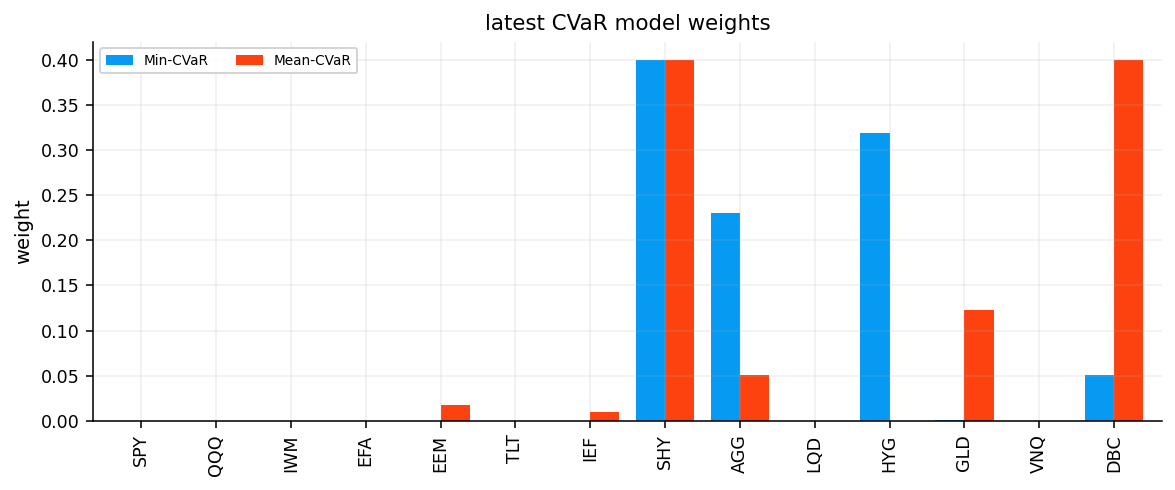

In [17]:
mean_cvar_rows = []
def training_cvar_loss(r, wv):
    loss_values = -r @ wv
    var = float(np.quantile(loss_values, cvar_alpha))
    tail = loss_values[loss_values >= var]
    return float(tail.mean()) if len(tail) else var

def mean_cvar_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    caps = cap_array(tickers).to_numpy(dtype=float)
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    r = r_train.to_numpy(dtype=float)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    ew = np.repeat(1.0 / len(tickers), len(tickers))
    ew_cvar = training_cvar_loss(r, ew)
    t, n = r.shape
    for scale in [0.90, 1.00, 1.10]:
        budget = scale * ew_cvar
        w = cp.Variable(n)
        eta = cp.Variable()
        u = cp.Variable(t)
        losses = -r @ w
        cvar = eta + cp.sum(u) / ((1.0 - cvar_alpha) * t)
        problem = cp.Problem(cp.Maximize(mu_ann.values @ w), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, u >= 0.0, u >= losses - eta, cvar <= budget])
        status = solve_cvx_problem(problem)
        if w.value is not None and status in ["optimal", "optimal_inaccurate"]:
            out = clean_weight_array(w.value, tickers)
            cvar_value = training_cvar_loss(r, out.reindex(tickers).values)
            mean_cvar_rows.append({"date": dt, "ew_cvar_95_loss": ew_cvar, "budget_scale": scale, "cvar_budget": budget, "cvar_95_loss": cvar_value, "mu_ann": float(mu_ann.values @ out.reindex(tickers).values), "status": status})
            return out
    return None
mean_cvar_weights = make_weight_frame_from_func("Mean-CVaR 95", mean_cvar_weight)
mean_cvar_result = backtest_weight_frame("Mean-CVaR 95", mean_cvar_weights)
results["Mean-CVaR 95"] = mean_cvar_result
mean_cvar_diag = pd.DataFrame(mean_cvar_rows).set_index("date")
cvar_table = compact_result_table({"Min-CVaR 95": min_cvar_result, "Mean-CVaR 95": mean_cvar_result})
cvar_latest_weights = pd.concat({"Min-CVaR": min_cvar_weights.iloc[-1], "Mean-CVaR": mean_cvar_weights.iloc[-1]}, axis=1)
display(cvar_table.round(4))
display(mean_cvar_diag[["ew_cvar_95_loss", "budget_scale", "cvar_budget", "cvar_95_loss", "mu_ann"]].tail(5).round(6))
ax = cvar_latest_weights.plot(kind="bar", figsize=(8.5, 3.6), width=0.78)
ax.set_title("latest CVaR model weights")
ax.set_ylabel("weight")
ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()


In [18]:
def latest_mean_cvar_budget(scale):
    dt = model_rebalance_dates[-1]
    state = walkforward_grid.cache[dt]
    tickers = list(state["tickers"])
    caps = cap_array(tickers).to_numpy(dtype=float)
    r = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any").to_numpy(dtype=float)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    ew_cvar = training_cvar_loss(r, np.repeat(1.0 / len(tickers), len(tickers)))
    t, n = r.shape
    w = cp.Variable(n)
    eta = cp.Variable()
    u = cp.Variable(t)
    losses = -r @ w
    cvar = eta + cp.sum(u) / ((1.0 - cvar_alpha) * t)
    budget = float(scale) * ew_cvar
    problem = cp.Problem(cp.Maximize(mu_ann.values @ w), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, u >= 0.0, u >= losses - eta, cvar <= budget])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return {"budget_scale": scale, "cvar_budget": budget, "status": status}
    out = clean_weight_array(w.value, tickers)
    return {"budget_scale": scale, "cvar_budget": budget, "expected_ann_return": float(mu_ann.values @ out.reindex(tickers).values), "cvar_95_loss": training_cvar_loss(r, out.reindex(tickers).values), "effective_n": float(1.0 / np.square(out.values).sum()), "max_weight": float(out.max()), "status": status}
latest_cvar_path = pd.DataFrame([latest_mean_cvar_budget(x) for x in [0.80, 0.90, 1.00, 1.10, 1.25]])
display(latest_cvar_path.round(6))


,budget_scale,cvar_budget,expected_ann_return,cvar_95_loss,effective_n,max_weight,status
0,0.80,0.009559,0.036450,0.009541,3.098604,0.4,optimal
1,0.90,0.010754,0.042202,0.010733,2.958887,0.4,optimal
2,1.00,0.011949,0.047507,0.011922,2.807025,0.4,optimal
3,1.10,0.013144,0.052092,0.013114,2.895575,0.4,optimal
4,1.25,0.014937,0.058424,0.014899,2.928389,0.4,optimal


,Risk Parity
SHY,0.2801
HYG,0.1457
LQD,0.1054
AGG,0.0884
IEF,0.0725
VNQ,0.0568
DBC,0.0550
GLD,0.0429
TLT,0.0372
EFA,0.0270


,percent_risk_contribution
equities,0.2483
duration,0.2531
credit,0.2499
diversifiers,0.2486


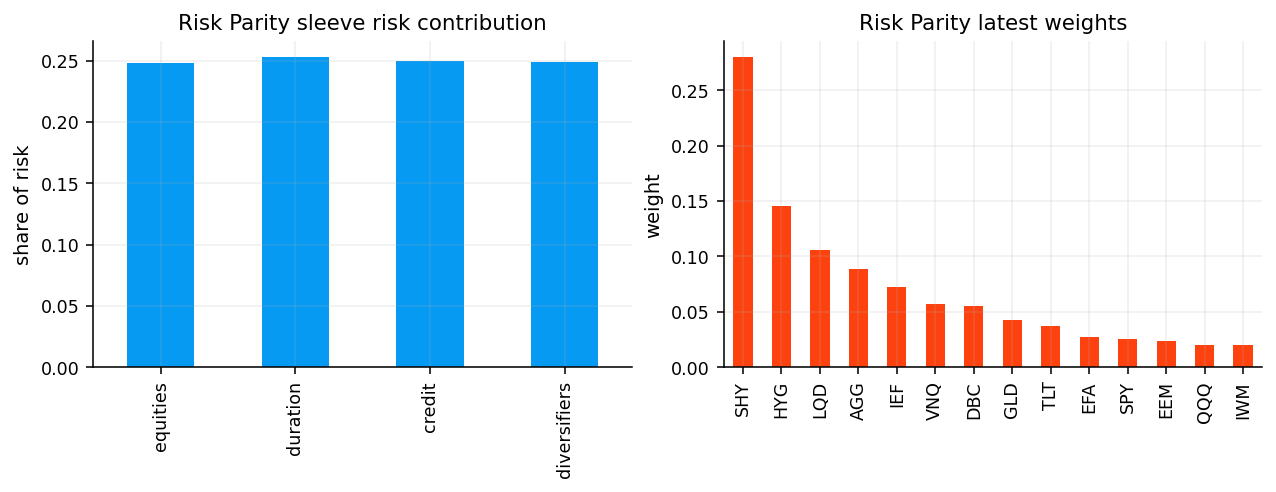

,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Risk Parity,0.0455,0.0491,0.1376,0.1718,-0.1377,0.3308,0.0131,1.6251,0.0012,5.9556,0.3502


In [19]:
def erc_vector(cov_arr, upper=None):
    cov = make_psd(np.asarray(cov_arr, dtype=float), eps=1e-10)
    n = cov.shape[0]
    cap = np.ones(n, dtype=float) if upper is None else np.asarray(upper, dtype=float)
    if cap.size != n or float(cap.sum()) < 1.0:
        cap = np.ones(n, dtype=float)
    x0 = np.minimum(np.ones(n, dtype=float) / n, cap)
    x0 = x0 / float(x0.sum())
    bounds = [(0.0, float(c)) for c in cap]
    cons = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    def objective(w):
        sigma_w = cov @ w
        port_vol = math.sqrt(max(float(w @ sigma_w), 1e-18))
        rc = w * sigma_w / port_vol
        return float(np.sum((rc - port_vol / n) ** 2))
    res = opt.minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=cons, options={"maxiter": 700, "ftol": 1e-12})
    if not res.success or not np.all(np.isfinite(res.x)):
        return x0
    return clean_weight_array(res.x, range(n), cap).values

def sleeve_risk_parity_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    cov_ann = pd.DataFrame(make_psd(np.asarray(state["cov_ann_map"][best_minvar_cov], dtype=float), eps=1e-10), index=tickers, columns=tickers)
    sleeve_inner = {}
    sleeve_returns = {}
    sleeve_names = []
    for sleeve, names in sleeve_groups.items():
        names = [name for name in names if name in tickers]
        if not names:
            continue
        sub_cov = cov_ann.loc[names, names].values
        inner = pd.Series(erc_vector(sub_cov), index=names, dtype=float)
        sleeve_inner[sleeve] = inner
        sleeve_returns[sleeve] = r_train[names] @ inner.reindex(names).values
        sleeve_names.append(sleeve)
    sleeve_frame = pd.DataFrame(sleeve_returns).dropna(how="any")
    if sleeve_frame.shape[1] < 2:
        return None
    sleeve_cov = sleeve_frame.cov().values * annualization
    sleeve_w = pd.Series(erc_vector(sleeve_cov), index=sleeve_names, dtype=float)
    final = pd.Series(0.0, index=tickers, dtype=float)
    for sleeve in sleeve_names:
        final.loc[sleeve_inner[sleeve].index] = sleeve_w.loc[sleeve] * sleeve_inner[sleeve]
    return clean_weight_array(final, tickers)
rp_weights = make_weight_frame_from_func("Risk Parity", sleeve_risk_parity_weight)
rp_result = backtest_weight_frame("Risk Parity", rp_weights)
results["Risk Parity"] = rp_result
latest_rp_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_rp_cov = pd.DataFrame(make_psd(latest_rp_state["cov_ann_map"][best_minvar_cov], eps=1e-10), index=assets, columns=assets)
latest_rp_w = rp_weights.iloc[-1].reindex(assets).fillna(0.0)
asset_rc = attribution.risk_contribution(latest_rp_w, latest_rp_cov.loc[assets, assets], tickers=assets)
sleeve_rc = pd.Series({sleeve: asset_rc.reindex(names).fillna(0.0).sum() for sleeve, names in sleeve_groups.items()})
sleeve_rc = sleeve_rc / float(sleeve_rc.sum())
display(latest_rp_w.sort_values(ascending=False).to_frame("Risk Parity").round(4))
display(sleeve_rc.to_frame("percent_risk_contribution").round(4))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
sleeve_rc.plot(kind="bar", ax=axes[0], color=colors[0])
axes[0].set_title("Risk Parity sleeve risk contribution")
axes[0].set_ylabel("share of risk")
latest_rp_w.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color=colors[1])
axes[1].set_title("Risk Parity latest weights")
axes[1].set_ylabel("weight")
plt.show()
display(compact_result_table({"Risk Parity": rp_result}).round(4))


,HRP
SHY,0.4000
HYG,0.1334
AGG,0.0711
IEF,0.0550
LQD,0.0515
DBC,0.0421
VNQ,0.0379
EFA,0.0360
GLD,0.0346
TLT,0.0296


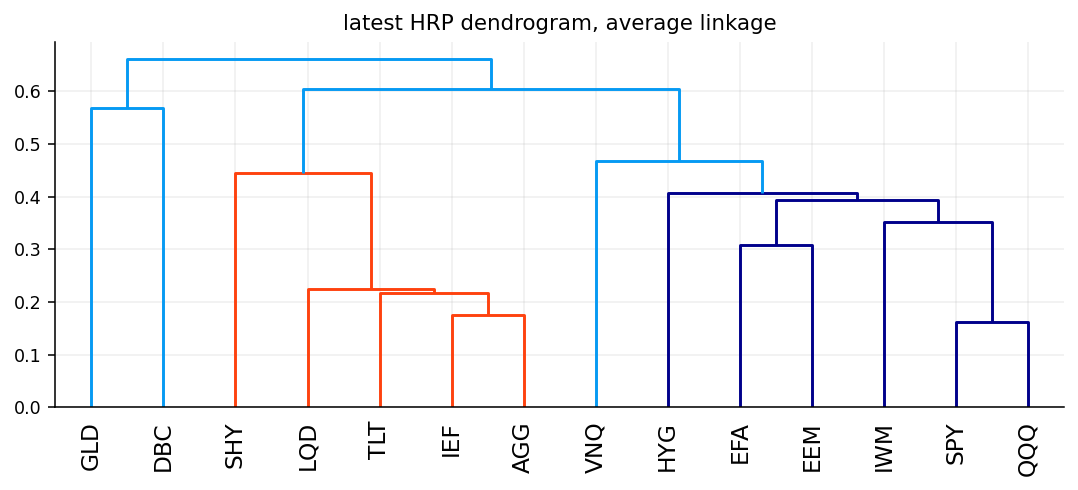

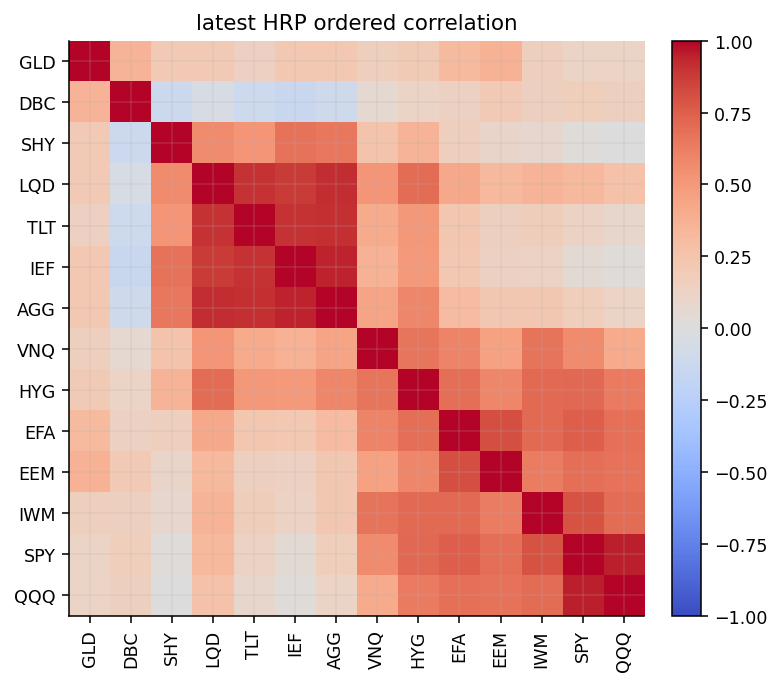

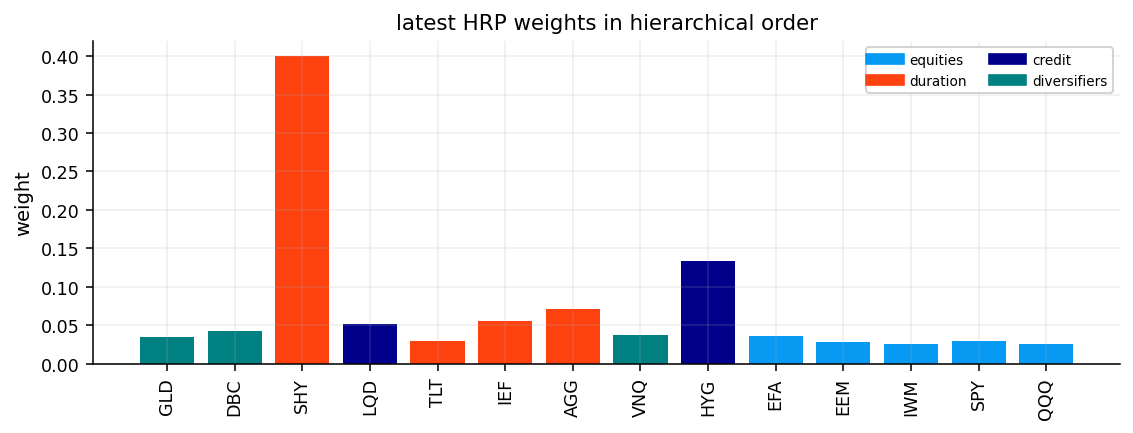

In [20]:
def corr_distance_link(cov_ann, method="average"):
    cov = pd.DataFrame(cov_ann).astype(float)
    diag = np.sqrt(np.maximum(np.diag(cov.values), 1e-12))
    corr = cov.values / np.outer(diag, diag)
    corr = np.clip(np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0), -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    distance = np.sqrt(np.clip((1.0 - corr) / 2.0, 0.0, 1.0))
    link = hierarchy.linkage(squareform(distance, checks=False), method=method)
    return corr, distance, link

def cluster_variance(cov, items):
    sub = cov[np.ix_(items, items)]
    diag = np.maximum(np.diag(sub), 1e-12)
    ivp = 1.0 / diag
    ivp = ivp / ivp.sum()
    return float(ivp @ sub @ ivp)

def hrp_allocation(cov_ann, tickers):
    cov = make_psd(np.asarray(cov_ann, dtype=float), eps=1e-10)
    corr, distance, link = corr_distance_link(cov, method="average")
    order = list(hierarchy.leaves_list(link))
    alloc = pd.Series(0.0, index=range(len(tickers)), dtype=float)
    def split(items, weight):
        if len(items) == 1:
            alloc.loc[items[0]] += weight
            return
        k = len(items) // 2
        left, right = items[:k], items[k:]
        left_var = cluster_variance(cov, left)
        right_var = cluster_variance(cov, right)
        left_weight = right_var / (left_var + right_var) if left_var + right_var > 1e-18 else 0.5
        split(left, weight * left_weight)
        split(right, weight * (1.0 - left_weight))
    split(order, 1.0)
    return clean_weight_array(pd.Series(alloc.values, index=tickers, dtype=float), tickers), corr, link, order

def hrp_weight(dt, state, prev_w):
    weights, corr, link, order = hrp_allocation(state["cov_ann_map"][best_minvar_cov], list(state["tickers"]))
    return weights
hrp_weights = make_weight_frame_from_func("HRP", hrp_weight)
hrp_result = backtest_weight_frame("HRP", hrp_weights)
results["HRP"] = hrp_result
latest_hrp_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_hrp_weights, latest_hrp_corr, latest_hrp_link, latest_hrp_order = hrp_allocation(latest_hrp_state["cov_ann_map"][best_minvar_cov], assets)
display(hrp_weights.iloc[-1].sort_values(ascending=False).to_frame("HRP").round(4))
fig, ax = plt.subplots(figsize=(7.8, 3.6))
hierarchy.dendrogram(latest_hrp_link, labels=assets, leaf_rotation=90, ax=ax)
ax.set_title("latest HRP dendrogram, average linkage")
plt.tight_layout()
plt.show()
ordered_assets = [assets[i] for i in latest_hrp_order]
fig, ax = plt.subplots(figsize=(5.8, 5.0))
im = ax.imshow(pd.DataFrame(latest_hrp_corr, index=assets, columns=assets).loc[ordered_assets, ordered_assets], cmap="coolwarm", vmin=-1.0, vmax=1.0)
ax.set_title("latest HRP ordered correlation")
ax.set_xticks(range(len(ordered_assets)), ordered_assets, rotation=90)
ax.set_yticks(range(len(ordered_assets)), ordered_assets)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
hrp_ordered_weights = hrp_weights.iloc[-1].reindex(ordered_assets).fillna(0.0)
sleeve_color = {sleeve: colors[i] for i, sleeve in enumerate(sleeve_groups)}
bar_colors = [sleeve_color.get(sleeve_map.get(asset, "other"), colors[0]) for asset in ordered_assets]
fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.bar(hrp_ordered_weights.index, hrp_ordered_weights.values, color=bar_colors)
ax.set_title("latest HRP weights in hierarchical order")
ax.set_ylabel("weight")
ax.tick_params(axis="x", rotation=90)
handles = [plt.Line2D([0], [0], color=sleeve_color[sleeve], lw=6) for sleeve in sleeve_groups]
ax.legend(handles, list(sleeve_groups), fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()


,asset,cluster
13,DBC,1
11,GLD,1
4,EEM,2
3,EFA,2
10,HYG,2
2,IWM,2
1,QQQ,2
0,SPY,2
12,VNQ,2
8,AGG,3


,NCO-MV
GLD,0.30
DBC,0.30
SHY,0.16
AGG,0.16
IEF,0.08
HYG,0.00
EEM,0.00
EFA,0.00
LQD,0.00
TLT,0.00


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
HRP,0.0520,0.0503,0.2580,0.3287,-0.1448,0.3591,0.0187,2.3201,0.0017,5.0965,0.400
NCO-MV,0.0786,0.0802,0.4958,0.5928,-0.1896,0.4145,0.2637,32.6957,0.0203,5.2855,0.275


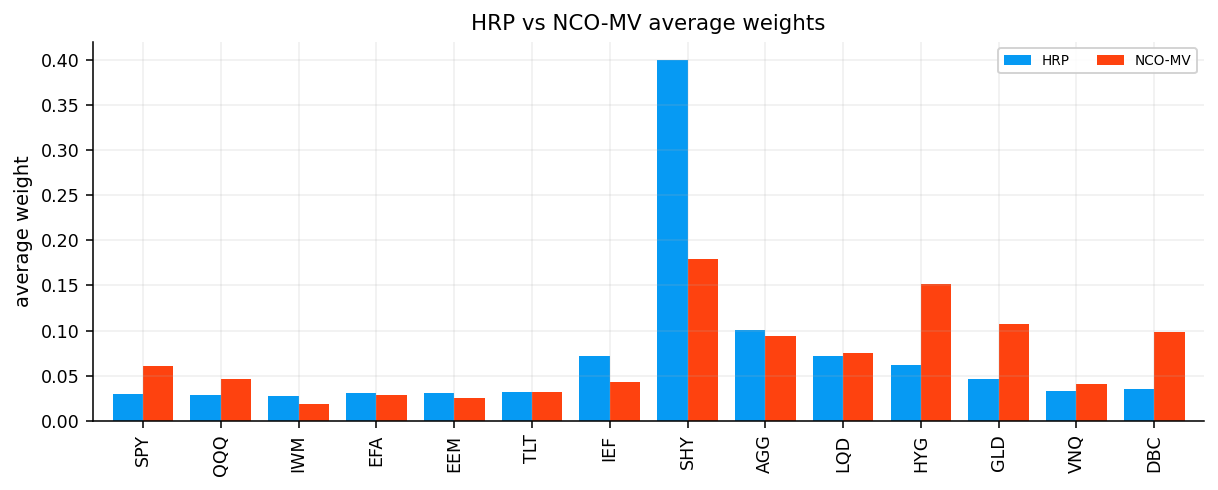

,assets,cluster_weight,forecast_return,standalone_vol
cluster,,,,
1,"GLD, DBC",0.6,0.0823,0.1472
2,"SPY, QQQ, IWM, EFA, EEM, HYG, VNQ",0.0,-0.0019,0.1089
3,"TLT, IEF, SHY, AGG, LQD",0.4,-0.0091,0.0433


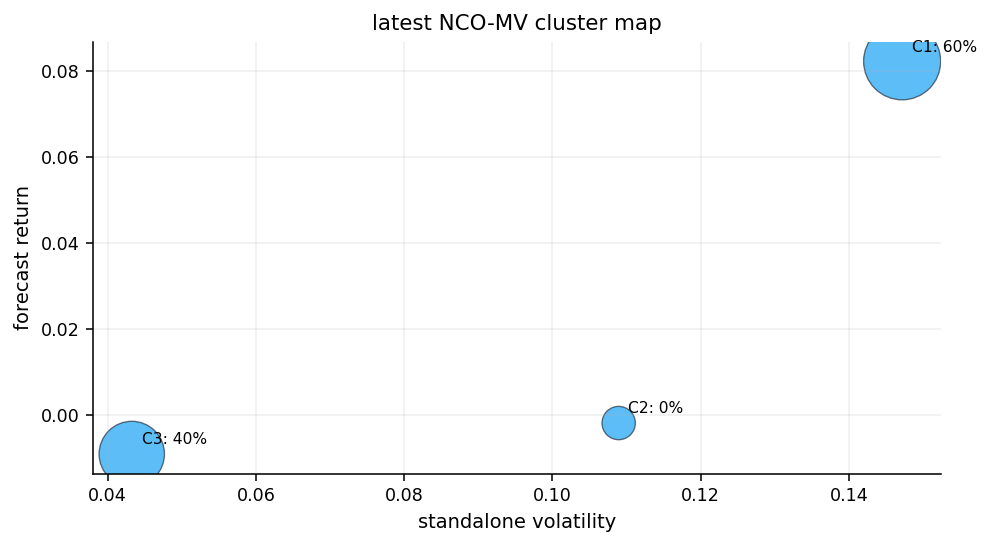

In [21]:
def solve_mv_vector(mu_arr, cov_arr, cap=0.40, lam=3.0):
    mu = np.asarray(mu_arr, dtype=float).reshape(-1)
    cov = make_psd(np.asarray(cov_arr, dtype=float), eps=1e-10)
    n = len(mu)
    cap_value = max(float(cap), 1.0 / n)
    caps = np.repeat(cap_value, n)
    w = cp.Variable(n)
    problem = cp.Problem(cp.Maximize(mu @ w - 0.5 * float(lam) * cp.quad_form(w, cp.psd_wrap(cov))), [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return clean_weight_array(np.ones(n, dtype=float), range(n), caps).values
    return clean_weight_array(w.value, range(n), caps).values

def nco_labels_from_cov(cov_ann, n_clusters=3):
    cov = make_psd(np.asarray(cov_ann, dtype=float), eps=1e-10)
    corr, distance, link = corr_distance_link(cov, method="average")
    labels = hierarchy.fcluster(link, t=int(n_clusters), criterion="maxclust")
    return labels, link

def nco_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    cov_ann = make_psd(np.asarray(state["cov_ann_map"][best_maxsharpe_cov], dtype=float), eps=1e-10)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    labels, link = nco_labels_from_cov(cov_ann, n_clusters=3)
    cluster_ids = sorted(pd.unique(labels))
    inner = {}
    cluster_returns = {}
    cluster_mu = []
    for cid in cluster_ids:
        locs = np.where(labels == cid)[0]
        names = [tickers[i] for i in locs]
        inner_cap = max(w_max, 1.0 / len(names))
        w_in = solve_mv_vector(mu_ann.reindex(names).values, cov_ann[np.ix_(locs, locs)], cap=inner_cap, lam=3.0)
        inner[cid] = pd.Series(w_in, index=names, dtype=float)
        cluster_returns[cid] = r_train[names] @ inner[cid].reindex(names).values
        cluster_mu.append(float(mu_ann.reindex(names).values @ inner[cid].reindex(names).values))
    cluster_frame = pd.DataFrame(cluster_returns).dropna(how="any")
    if cluster_frame.shape[1] < 2:
        return None
    cluster_cov = cluster_frame.cov().values * annualization
    outer = solve_mv_vector(np.asarray(cluster_mu, dtype=float), cluster_cov, cap=0.60, lam=3.0)
    final = pd.Series(0.0, index=tickers, dtype=float)
    for j, cid in enumerate(cluster_ids):
        final.loc[inner[cid].index] = outer[j] * inner[cid]
    return clean_weight_array(final, tickers)
nco_weights = make_weight_frame_from_func("NCO-MV", nco_weight)
nco_result = backtest_weight_frame("NCO-MV", nco_weights)
results["NCO-MV"] = nco_result
latest_nco_labels, latest_nco_link = nco_labels_from_cov(latest_hrp_state["cov_ann_map"][best_maxsharpe_cov], n_clusters=3)
cluster_membership = pd.DataFrame({"asset": assets, "cluster": latest_nco_labels}).sort_values(["cluster", "asset"])
hier_avg_weights = pd.concat({"HRP": hrp_weights.mean(), "NCO-MV": nco_weights.mean()}, axis=1).reindex(assets)
display(cluster_membership)
display(nco_weights.iloc[-1].sort_values(ascending=False).to_frame("NCO-MV").round(4))
display(compact_result_table({"HRP": hrp_result, "NCO-MV": nco_result}).round(4))
ax = hier_avg_weights.plot(kind="bar", figsize=(8.8, 3.6), width=0.78)
ax.set_title("HRP vs NCO-MV average weights")
ax.set_ylabel("average weight")
ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()
latest_nco_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_nco_cov = make_psd(np.asarray(latest_nco_state["cov_ann_map"][best_maxsharpe_cov], dtype=float), eps=1e-10)
latest_nco_mu = latest_nco_state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(assets).fillna(0.0).astype(float)
latest_nco_w = nco_weights.iloc[-1].reindex(assets).fillna(0.0)
nco_cluster_rows = []
for cid in sorted(pd.unique(latest_nco_labels)):
    names = [asset for asset, label in zip(assets, latest_nco_labels) if label == cid]
    weight = float(latest_nco_w.reindex(names).sum())
    if weight > 1e-12:
        within = latest_nco_w.reindex(names).fillna(0.0) / weight
    else:
        within = pd.Series(1.0 / len(names), index=names, dtype=float)
    locs = [assets.index(name) for name in names]
    sub_cov = latest_nco_cov[np.ix_(locs, locs)]
    vol = float(math.sqrt(max(within.values @ sub_cov @ within.values, 0.0)))
    ret = float(latest_nco_mu.reindex(names).values @ within.values)
    nco_cluster_rows.append({"cluster": int(cid), "assets": ", ".join(names), "cluster_weight": weight, "forecast_return": ret, "standalone_vol": vol})
nco_cluster_stats = pd.DataFrame(nco_cluster_rows).set_index("cluster")
display(nco_cluster_stats.round(4))
fig, ax = plt.subplots(figsize=(7.2, 4.0))
sizes = 250 + 2200 * nco_cluster_stats["cluster_weight"].clip(lower=0.02)
ax.scatter(nco_cluster_stats["standalone_vol"], nco_cluster_stats["forecast_return"], s=sizes, color=colors[0], alpha=0.65, edgecolor="#1f2937", linewidth=0.7)
for cid, row in nco_cluster_stats.iterrows():
    ax.annotate(f"C{cid}: {row['cluster_weight']:.0%}", (row["standalone_vol"], row["forecast_return"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_title("latest NCO-MV cluster map")
ax.set_xlabel("standalone volatility")
ax.set_ylabel("forecast return")
plt.tight_layout()
plt.show()


In [22]:
hier_summary = compact_result_table({"HRP": hrp_result, "NCO-MV": nco_result})
best_hier_name = hier_summary.sort_values(["sharpe", "max_drawdown", "avg_turnover", "cagr"], ascending=[False, False, True, False]).index[0]
print("selected hierarchical model:", best_hier_name)
display(hier_summary.round(4))


selected hierarchical model: NCO-MV


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
HRP,0.0520,0.0503,0.2580,0.3287,-0.1448,0.3591,0.0187,2.3201,0.0017,5.0965,0.400
NCO-MV,0.0786,0.0802,0.4958,0.5928,-0.1896,0.4145,0.2637,32.6957,0.0203,5.2855,0.275


In [23]:
def selected_mv_inputs(state):
    tickers = list(state["tickers"])
    cov_ann = make_psd(np.asarray(state["cov_ann_map"][best_maxsharpe_cov], dtype=float), eps=1e-10)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    t_mu = int(len(state["R_mu"]))
    return tickers, mu_ann, cov_ann, t_mu
box_radius = 0.50
robust_mv_lambda = 3.0
box_rows = []
def box_robust_weight(dt, state, prev_w):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    se_ann = np.sqrt(np.maximum(np.diag(cov_ann), 0.0)) / math.sqrt(max(t_mu, 1))
    robust_mu = mu_ann.to_numpy(dtype=float) - box_radius * se_ann
    w = cp.Variable(n)
    problem = cp.Problem(cp.Maximize(robust_mu @ w - 0.5 * robust_mv_lambda * cp.quad_form(w, cp.psd_wrap(cov_ann))), [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None
    out = clean_weight_array(w.value, tickers)
    box_rows.append({"date": dt, "status": status, "robust_return": float(robust_mu @ out.reindex(tickers).values)})
    return out
box_robust_weights = make_weight_frame_from_func("Box Robust MV", box_robust_weight)
box_robust_result = backtest_weight_frame("Box Robust MV", box_robust_weights)
results["Box Robust MV"] = box_robust_result
latest_box_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_tickers, latest_mu_ann, latest_cov_ann, latest_t_mu = selected_mv_inputs(latest_box_state)
latest_se_ann = np.sqrt(np.maximum(np.diag(latest_cov_ann), 0.0)) / math.sqrt(max(latest_t_mu, 1))
latest_box_table = pd.DataFrame({"asset": latest_tickers, "mu_ann": latest_mu_ann.values, "se_ann": latest_se_ann, "robust_mu": latest_mu_ann.values - box_radius * latest_se_ann, "weight": box_robust_weights.iloc[-1].reindex(latest_tickers).values})
display(latest_box_table.round(4))
display(compact_result_table({"Box Robust MV": box_robust_result}).round(4))


,asset,mu_ann,se_ann,robust_mu,weight
0,SPY,-0.0312,0.0096,-0.0360,0.0
1,QQQ,-0.0345,0.0123,-0.0407,0.0
2,IWM,-0.0147,0.0132,-0.0213,0.0
3,EFA,0.0011,0.0094,-0.0036,0.0
4,EEM,0.0098,0.0110,0.0042,0.0
5,TLT,-0.0149,0.0089,-0.0194,0.0
6,IEF,-0.0100,0.0045,-0.0122,0.0
7,SHY,-0.0079,0.0018,-0.0088,0.2
8,AGG,-0.0098,0.0038,-0.0116,0.0
9,LQD,-0.0157,0.0049,-0.0182,0.0


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Box Robust MV,0.091,0.0956,0.5503,0.6663,-0.1646,0.5532,0.3192,39.5866,0.0222,3.3343,0.3892


,radius,empirical_return,uncertainty_penalty,robust_return,volatility,effective_n,max_weight,status
0,0.00,0.0643,0.0000,0.0643,0.1182,2.7778,0.4,optimal
1,0.10,0.0643,0.0007,0.0635,0.1182,2.7778,0.4,optimal
2,0.25,0.0643,0.0019,0.0624,0.1182,2.7778,0.4,optimal
3,0.50,0.0643,0.0037,0.0605,0.1182,2.7778,0.4,optimal
4,1.00,0.0643,0.0075,0.0568,0.1182,2.7778,0.4,optimal
5,1.50,0.0643,0.0112,0.0531,0.1182,2.7778,0.4,optimal


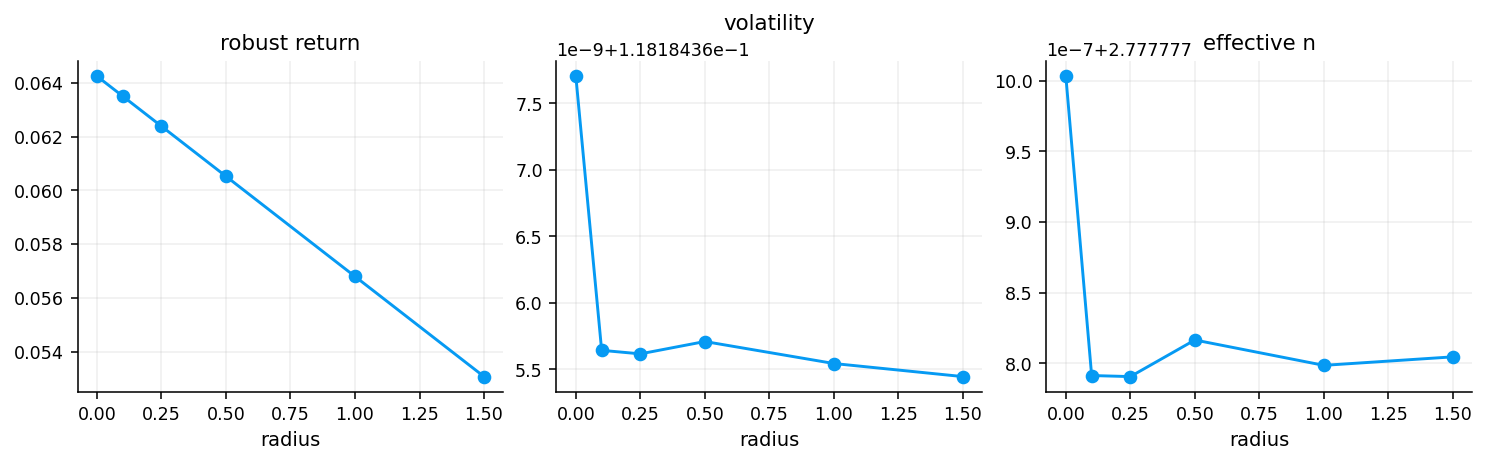

,asset,mu_ann,box_robust_mu,box_weight,ellipsoid_weight
0,SPY,-0.0312,-0.0360,0.0,0.0
1,QQQ,-0.0345,-0.0407,0.0,0.0
2,IWM,-0.0147,-0.0213,0.0,0.0
3,EFA,0.0011,-0.0036,0.0,0.0
4,EEM,0.0098,0.0042,0.0,0.0
5,TLT,-0.0149,-0.0194,0.0,0.0
6,IEF,-0.0100,-0.0122,0.0,0.0
7,SHY,-0.0079,-0.0088,0.2,0.2
8,AGG,-0.0098,-0.0116,0.0,0.0
9,LQD,-0.0157,-0.0182,0.0,0.0


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Box Robust MV,0.0910,0.0956,0.5503,0.6663,-0.1646,0.5532,0.3192,39.5866,0.0222,3.3343,0.3892
Ellipsoid Robust MV,0.0905,0.0923,0.5608,0.6754,-0.1559,0.5803,0.3137,38.8992,0.0218,3.4786,0.3816


In [24]:
ellipsoid_radius = 1.00
ellipsoid_rows = []
def solve_ellipsoid_portfolio(state, radius):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    omega_sqrt = psd_sqrt(cov_ann / max(t_mu, 1))
    w = cp.Variable(n)
    penalty = float(radius) * cp.norm(omega_sqrt @ w, 2)
    problem = cp.Problem(cp.Maximize(mu_ann.values @ w - penalty - 0.5 * robust_mv_lambda * cp.quad_form(w, cp.psd_wrap(cov_ann))), [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None, status
    return clean_weight_array(w.value, tickers), status

def ellipsoid_robust_weight(dt, state, prev_w):
    out, status = solve_ellipsoid_portfolio(state, ellipsoid_radius)
    if out is None:
        return None
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    omega_sqrt = psd_sqrt(cov_ann / max(t_mu, 1))
    wv = out.reindex(tickers).values
    ellipsoid_rows.append({"date": dt, "status": status, "empirical_return": float(mu_ann.values @ wv), "uncertainty_penalty": float(ellipsoid_radius * np.linalg.norm(omega_sqrt @ wv))})
    return out
ellipsoid_robust_weights = make_weight_frame_from_func("Ellipsoid Robust MV", ellipsoid_robust_weight)
ellipsoid_robust_result = backtest_weight_frame("Ellipsoid Robust MV", ellipsoid_robust_weights)
results["Ellipsoid Robust MV"] = ellipsoid_robust_result
radius_rows = []
for radius in [0.0, 0.10, 0.25, 0.50, 1.00, 1.50]:
    w_radius, status = solve_ellipsoid_portfolio(latest_box_state, radius)
    if w_radius is None:
        radius_rows.append({"radius": radius, "status": status})
        continue
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(latest_box_state)
    omega_sqrt = psd_sqrt(cov_ann / max(t_mu, 1))
    wv = w_radius.reindex(tickers).values
    empirical_return = float(mu_ann.values @ wv)
    uncertainty_penalty = float(radius * np.linalg.norm(omega_sqrt @ wv))
    radius_rows.append({"radius": radius, "empirical_return": empirical_return, "uncertainty_penalty": uncertainty_penalty, "robust_return": empirical_return - uncertainty_penalty, "volatility": float(math.sqrt(max(wv @ cov_ann @ wv, 0.0))), "effective_n": float(1.0 / np.square(wv).sum()), "max_weight": float(w_radius.max()), "status": status})
ellipsoid_radius_path = pd.DataFrame(radius_rows)
display(ellipsoid_radius_path.round(4))
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for ax, col, title in zip(axes, ["robust_return", "volatility", "effective_n"], ["robust return", "volatility", "effective n"]):
    ax.plot(ellipsoid_radius_path["radius"], ellipsoid_radius_path[col], marker="o", color=colors[0])
    ax.set_title(title)
    ax.set_xlabel("radius")
plt.show()
box_ellipsoid_latest = pd.DataFrame({"asset": latest_tickers, "mu_ann": latest_mu_ann.values, "box_robust_mu": latest_mu_ann.values - box_radius * latest_se_ann, "box_weight": box_robust_weights.iloc[-1].reindex(latest_tickers).values, "ellipsoid_weight": ellipsoid_robust_weights.iloc[-1].reindex(latest_tickers).values})
display(box_ellipsoid_latest.round(4))
display(compact_result_table({"Box Robust MV": box_robust_result, "Ellipsoid Robust MV": ellipsoid_robust_result}).round(4))


In [25]:
robust_summary = compact_result_table({"Box Robust MV": box_robust_result, "Ellipsoid Robust MV": ellipsoid_robust_result})
best_robust_name = robust_summary.sort_values(["sharpe", "max_drawdown", "avg_turnover", "cagr"], ascending=[False, False, True, False]).index[0]
print("selected robust model:", best_robust_name)
display(robust_summary.round(4))


selected robust model: Ellipsoid Robust MV


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Box Robust MV,0.0910,0.0956,0.5503,0.6663,-0.1646,0.5532,0.3192,39.5866,0.0222,3.3343,0.3892
Ellipsoid Robust MV,0.0905,0.0923,0.5608,0.6754,-0.1559,0.5803,0.3137,38.8992,0.0218,3.4786,0.3816


,radius,sqrt_delta,empirical_return,dro_penalty,robust_return,volatility,effective_n,max_weight,status
0,0.00,0.0000,0.0643,0.0000,0.0643,0.1182,2.7778,0.4,optimal
1,0.10,0.0009,0.0643,0.0005,0.0637,0.1182,2.7778,0.4,optimal
2,0.25,0.0023,0.0643,0.0014,0.0629,0.1182,2.7778,0.4,optimal
3,0.50,0.0045,0.0643,0.0027,0.0615,0.1182,2.7778,0.4,optimal
4,1.00,0.0091,0.0643,0.0054,0.0588,0.1182,2.7842,0.4,optimal
5,2.00,0.0182,0.0643,0.0106,0.0537,0.1189,2.9315,0.4,optimal
6,5.00,0.0454,0.0625,0.0255,0.0371,0.1163,3.1807,0.4,optimal
7,10.00,0.0908,0.0538,0.0452,0.0087,0.1024,4.0465,0.4,optimal


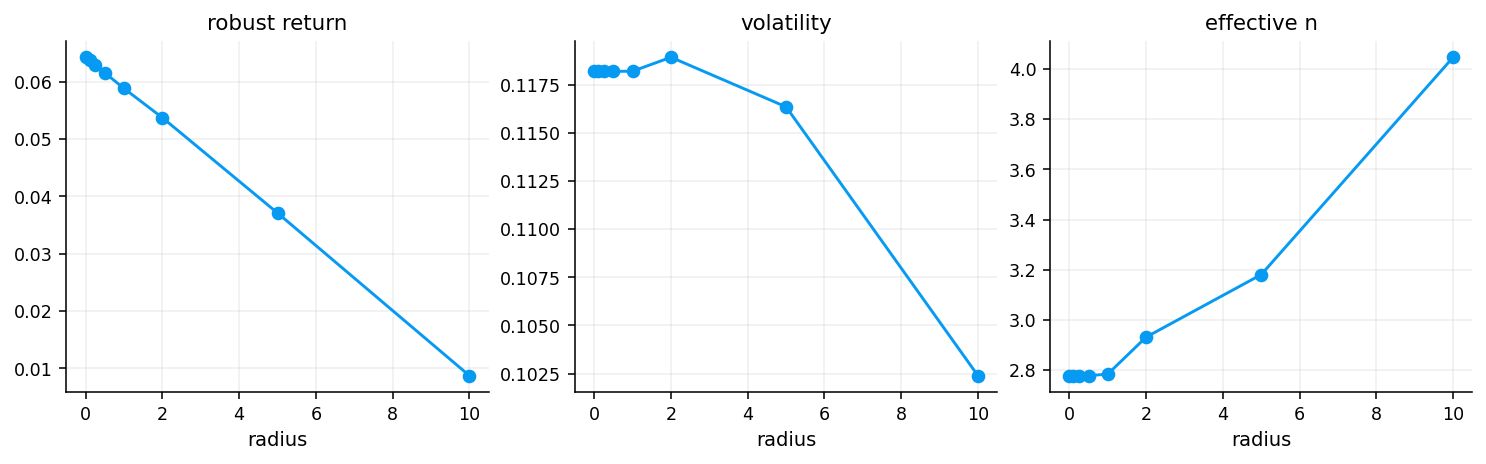

,Wasserstein DRMV
DBC,0.4
GLD,0.4
SHY,0.2
EEM,0.0
AGG,0.0
IEF,0.0
EFA,0.0
TLT,0.0
HYG,0.0
LQD,0.0


,sqrt_delta,empirical_return,dro_penalty,robust_return,volatility,effective_n,max_weight,status
date,,,,,,,,
2026-02-27,0.0022,0.0269,0.0013,0.0256,0.1158,3.0306,0.4,optimal
2026-03-31,0.0023,0.0301,0.0013,0.0288,0.1232,3.2377,0.4,optimal
2026-04-30,0.0023,0.0643,0.0014,0.0629,0.1182,2.7778,0.4,optimal


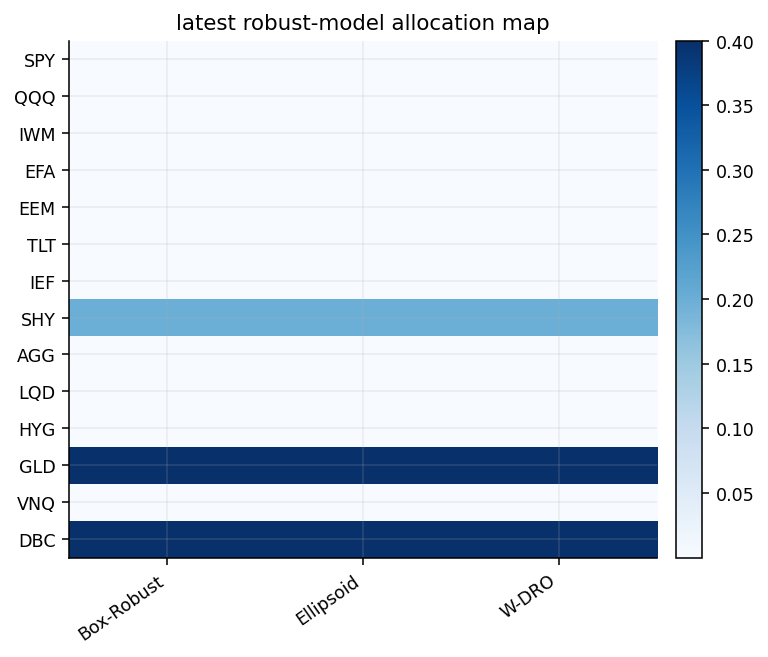

In [26]:
dro_radius = 0.25
wasserstein_mv_lambda = 3.0
wasserstein_rows = []
def solve_wasserstein_utility(state, radius):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    sqrt_delta = float(radius) * math.sqrt(float(np.trace(cov_ann)) / n) / math.sqrt(max(t_mu, 1))
    w = cp.Variable(n)
    dro_penalty = sqrt_delta * cp.norm(w, 2)
    objective = cp.Maximize(mu_ann.values @ w - dro_penalty - 0.5 * wasserstein_mv_lambda * cp.quad_form(w, cp.psd_wrap(cov_ann)))
    problem = cp.Problem(objective, [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None, status, sqrt_delta
    return clean_weight_array(w.value, tickers), status, sqrt_delta

def wasserstein_weight(dt, state, prev_w):
    out, status, sqrt_delta = solve_wasserstein_utility(state, dro_radius)
    if out is None:
        return None
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    wv = out.reindex(tickers).values
    empirical_return = float(mu_ann.values @ wv)
    wasserstein_penalty = float(sqrt_delta * np.linalg.norm(wv))
    wasserstein_rows.append({"date": dt, "sqrt_delta": sqrt_delta, "empirical_return": empirical_return, "dro_penalty": wasserstein_penalty, "robust_return": empirical_return - wasserstein_penalty, "volatility": float(math.sqrt(max(wv @ cov_ann @ wv, 0.0))), "effective_n": float(1.0 / np.square(wv).sum()), "max_weight": float(out.max()), "status": status})
    return out
wasserstein_weights = make_weight_frame_from_func("Wasserstein DRMV", wasserstein_weight)
wasserstein_result = backtest_weight_frame("Wasserstein DRMV", wasserstein_weights)
results["Wasserstein DRMV"] = wasserstein_result
wasserstein_diag = pd.DataFrame(wasserstein_rows).set_index("date")
dro_rows = []
latest_tickers, latest_mu_w, latest_cov_w, latest_t_mu_w = selected_mv_inputs(latest_box_state)
for radius in [0, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00, 10.00]:
    w_radius, status, sqrt_delta = solve_wasserstein_utility(latest_box_state, radius)
    if w_radius is None:
        dro_rows.append({"radius": radius, "sqrt_delta": sqrt_delta, "status": status})
        continue
    wv = w_radius.reindex(latest_tickers).values
    empirical_return = float(latest_mu_w.values @ wv)
    dro_penalty = float(sqrt_delta * np.linalg.norm(wv))
    dro_rows.append({"radius": radius, "sqrt_delta": sqrt_delta, "empirical_return": empirical_return, "dro_penalty": dro_penalty, "robust_return": empirical_return - dro_penalty, "volatility": float(math.sqrt(max(wv @ latest_cov_w @ wv, 0.0))), "effective_n": float(1.0 / np.square(wv).sum()), "max_weight": float(w_radius.max()), "status": status})
wasserstein_radius_path = pd.DataFrame(dro_rows)
display(wasserstein_radius_path.round(4))
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for ax, col, title in zip(axes, ["robust_return", "volatility", "effective_n"], ["robust return", "volatility", "effective n"]):
    ax.plot(wasserstein_radius_path["radius"], wasserstein_radius_path[col], marker="o", color=colors[0])
    ax.set_title(title)
    ax.set_xlabel("radius")
plt.show()
display(wasserstein_weights.iloc[-1].sort_values(ascending=False).to_frame("Wasserstein DRMV").round(4))
display(wasserstein_diag.tail(3).round(4))
robust_latest_weights = pd.concat({"Box-Robust": box_robust_weights.iloc[-1], "Ellipsoid": ellipsoid_robust_weights.iloc[-1], "W-DRO": wasserstein_weights.iloc[-1]}, axis=1).reindex(assets).fillna(0.0)
fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(robust_latest_weights.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(robust_latest_weights.columns)))
ax.set_xticklabels(robust_latest_weights.columns, rotation=35, ha="right")
ax.set_yticks(range(len(robust_latest_weights.index)))
ax.set_yticklabels(robust_latest_weights.index)
ax.set_title("latest robust-model allocation map")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
plt.tight_layout()
plt.show()


,target,empirical_status,target_status,empirical_mv_vol,empirical_effective_n,wasserstein_empirical_vol,wasserstein_tax,wasserstein_robust_risk,wasserstein_effective_n
0,-0.0155,optimal,optimal,0.0350,3.2506,0.0350,0.0013,0.0362,3.2573
1,-0.0124,optimal,optimal,0.0350,3.2506,0.0350,0.0013,0.0362,3.2573
2,-0.0092,optimal,optimal,0.0350,3.2506,0.0350,0.0013,0.0362,3.2573
3,-0.0060,optimal,optimal,0.0350,3.2506,0.0350,0.0013,0.0362,3.2573
4,-0.0029,optimal,optimal,0.0350,3.2713,0.0351,0.0012,0.0363,3.3230
5,0.0003,optimal,optimal,0.0354,3.3866,0.0358,0.0012,0.0370,3.4504
6,0.0034,optimal,optimal,0.0365,3.4448,0.0371,0.0012,0.0383,3.5901
7,0.0066,optimal,optimal,0.0381,3.4862,0.0389,0.0012,0.0401,3.6895
8,0.0097,optimal,optimal,0.0403,3.4809,0.0412,0.0012,0.0424,3.7400
9,0.0129,optimal,optimal,0.0428,3.4280,0.0438,0.0012,0.0450,3.7399


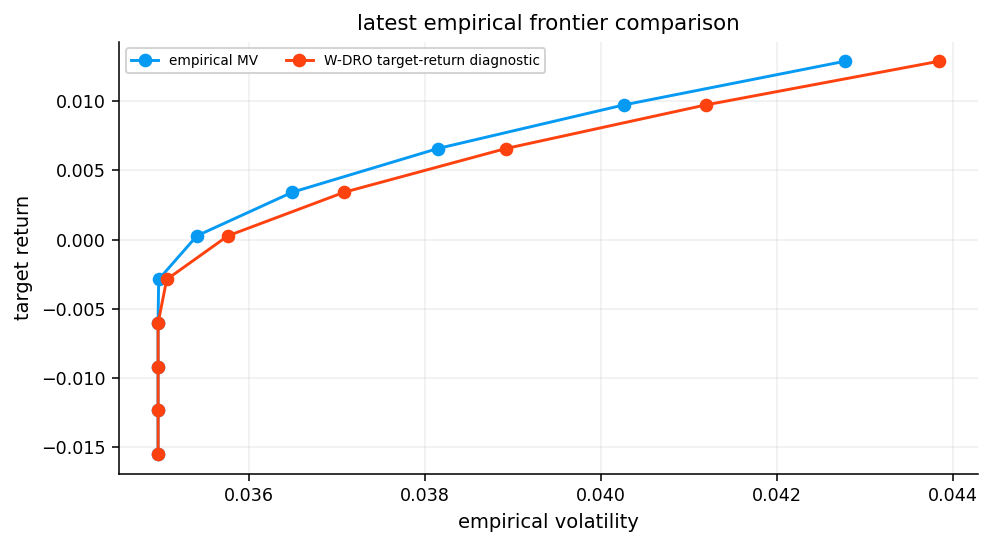

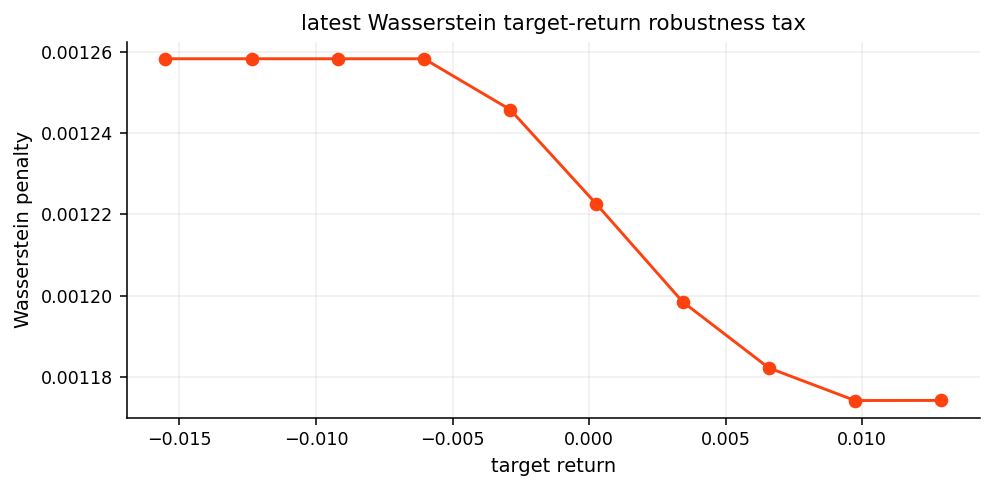

In [27]:
def solve_wasserstein_target_return(state, radius, target_return):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    sigma_sqrt = psd_sqrt(cov_ann)
    sqrt_delta = float(radius) * math.sqrt(float(np.trace(cov_ann)) / n) / math.sqrt(max(t_mu, 1))
    w = cp.Variable(n)
    empirical_risk = cp.norm(sigma_sqrt @ w, 2)
    penalty = sqrt_delta * cp.norm(w, 2)
    problem = cp.Problem(cp.Minimize(empirical_risk + penalty), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, mu_ann.values @ w - penalty >= float(target_return)])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None, status, sqrt_delta
    return clean_weight_array(w.value, tickers), status, sqrt_delta
latest_state = walkforward_grid.cache[model_rebalance_dates[-1]]
tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(latest_state)
caps = cap_array(tickers).to_numpy(dtype=float)
sigma_sqrt = psd_sqrt(cov_ann)
target_grid = np.linspace(float(np.nanpercentile(mu_ann.values, 25)), float(np.nanpercentile(mu_ann.values, 85)), 10)
frontier_rows = []
for target in target_grid:
    n = len(tickers)
    w = cp.Variable(n)
    empirical_risk = cp.norm(sigma_sqrt @ w, 2)
    empirical_problem = cp.Problem(cp.Minimize(empirical_risk), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, mu_ann.values @ w >= float(target)])
    empirical_status = solve_cvx_problem(empirical_problem)
    empirical_w = clean_weight_array(w.value, tickers) if w.value is not None and empirical_status in ["optimal", "optimal_inaccurate"] else None
    w2, target_status, sqrt_delta_used = solve_wasserstein_target_return(latest_state, dro_radius, float(target))
    row = {"target": float(target), "empirical_status": empirical_status, "target_status": target_status}
    if empirical_w is not None:
        ev = empirical_w.reindex(tickers).values
        row.update({"empirical_mv_vol": float(math.sqrt(max(ev @ cov_ann @ ev, 0.0))), "empirical_effective_n": float(1.0 / np.square(ev).sum())})
    if w2 is not None:
        wv = w2.reindex(tickers).values
        vol = float(math.sqrt(max(wv @ cov_ann @ wv, 0.0)))
        tax = float(sqrt_delta_used * np.linalg.norm(wv))
        row.update({"wasserstein_empirical_vol": vol, "wasserstein_tax": tax, "wasserstein_robust_risk": vol + tax, "wasserstein_effective_n": float(1.0 / np.square(wv).sum())})
    frontier_rows.append(row)
frontier_table = pd.DataFrame(frontier_rows)
display(frontier_table.round(4))
frontier_plot = frontier_table.dropna(subset=["empirical_mv_vol", "wasserstein_empirical_vol"], how="all")
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(frontier_plot["empirical_mv_vol"], frontier_plot["target"], marker="o", label="empirical MV")
ax.plot(frontier_plot["wasserstein_empirical_vol"], frontier_plot["target"], marker="o", label="W-DRO target-return diagnostic")
ax.set_title("latest empirical frontier comparison")
ax.set_xlabel("empirical volatility")
ax.set_ylabel("target return")
ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(frontier_table["target"], frontier_table["wasserstein_tax"], marker="o", color=colors[1])
ax.set_title("latest Wasserstein target-return robustness tax")
ax.set_xlabel("target return")
ax.set_ylabel("Wasserstein penalty")
plt.tight_layout()
plt.show()


In [28]:
def full_result_table(result_dict):
    table = compact_result_table(result_dict)
    var_rows = []
    for name, result in result_dict.items():
        r = result.net_returns.dropna()
        var = var_es_table(r.to_frame(name), alpha=0.05, methods=("hist",))
        var_rows.append({
            "Strategy": name,
            "var_95": float(var.loc[name, "hist_var5"]),
            "es_95": float(var.loc[name, "hist_es5"]),
            "worst_month": float(r.resample("ME").apply(lambda x: (1.0 + x).prod() - 1.0).min()),
            "avg_max_weight": float(result.weights.max(axis=1).mean()),
        })
    var_rows = pd.DataFrame(var_rows).set_index("Strategy")
    out = table.drop(columns=[c for c in var_rows.columns if c in table.columns], errors="ignore").join(var_rows, how="left")
    out = out.rename(columns={"vol": "ann_vol", "effective_n": "avg_effective_n"})
    out["ann_return"] = out["cagr"]
    cols = ["cagr", "ann_return", "ann_vol", "sharpe", "sortino", "calmar", "max_drawdown", "var_95", "es_95", "worst_month", "avg_turnover", "total_turnover", "cost_drag", "avg_effective_n", "avg_max_weight"]
    return out[[c for c in cols if c in out.columns]]

full_summary = full_result_table(results)
display(full_summary.sort_values(["sharpe", "max_drawdown", "cagr"], ascending=[False, False, False]).round(4))

display(pd.concat({
    "sharpe": full_summary.sort_values("sharpe", ascending=False).head(8),
    "calmar": full_summary.sort_values("calmar", ascending=False).head(8),
    "es_95": full_summary.sort_values("es_95", ascending=True).head(8),
    "max_drawdown": full_summary.sort_values("max_drawdown", ascending=False).head(8),
}).round(4))
local_model_names = ["Min-CVaR 95", "Mean-CVaR 95", "Risk Parity", "HRP", "NCO-MV", "Box Robust MV", "Ellipsoid Robust MV", "Wasserstein DRMV"]
weight_check_rows = []
for name in local_model_names:
    if name not in results:
        continue
    w = results[name].weights.reindex(columns=assets).fillna(0.0)
    weight_check_rows.append({"model": name, "max_sum_error": float((w.sum(axis=1) - 1.0).abs().max()), "max_cap_excess": float((w - w_max).max(axis=1).clip(lower=0.0).max()), "fallback_count": int(local_fallback_counts.get(name, 0))})
weight_checks = pd.DataFrame(weight_check_rows).set_index("model")
display(weight_checks.round(8))


,cagr,ann_return,ann_vol,sharpe,sortino,calmar,max_drawdown,var_95,es_95,worst_month,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,,,,,
"MaxSharpe (LedoitWolf, Momentum)",0.1179,0.1179,0.1132,0.6908,0.8527,0.7623,-0.1546,0.0114,0.0176,-0.0968,0.2730,34.1262,0.0182,3.2789,0.3857
Mean-CVaR 95,0.0964,0.0964,0.0954,0.6025,0.7506,0.6598,-0.1461,0.0090,0.0145,-0.0552,0.3063,37.9865,0.0212,3.3669,0.3887
Learned-Confidence BL,0.1026,0.1026,0.1092,0.5918,0.7282,0.4691,-0.2187,0.0103,0.0164,-0.0674,0.1762,21.8452,0.0134,5.9795,0.2956
Wasserstein DRMV,0.0972,0.0972,0.1001,0.5856,0.7185,0.6218,-0.1563,0.0095,0.0154,-0.0829,0.3169,39.3002,0.0217,3.5658,0.3761
Ellipsoid Robust MV,0.0905,0.0905,0.0923,0.5608,0.6754,0.5803,-0.1559,0.0088,0.0142,-0.0761,0.3137,38.8992,0.0218,3.4786,0.3816
Box Robust MV,0.0910,0.0910,0.0956,0.5503,0.6663,0.5532,-0.1646,0.0091,0.0148,-0.0802,0.3192,39.5866,0.0222,3.3343,0.3892
NCO-MV,0.0786,0.0786,0.0802,0.4958,0.5928,0.4145,-0.1896,0.0072,0.0119,-0.0640,0.2637,32.6957,0.0203,5.2855,0.2750
Equal Weight,0.0855,0.0855,0.0933,0.4916,0.6029,0.4187,-0.2041,0.0085,0.0138,-0.0806,0.0114,1.4252,0.0010,14.0000,0.0714
"MV (LedoitWolf, BayesStein)",0.0735,0.0735,0.0687,0.4860,0.5852,0.6225,-0.1181,0.0064,0.0105,-0.0624,0.0270,3.3724,0.0021,4.8250,0.3443


cagr  ann_return  ann_vol  sharpe  sortino  calmar  max_drawdown  var_95   es_95  worst_month  avg_turnover  total_turnover  \
             Strategy                                                                                                                                                          
sharpe       MaxSharpe (LedoitWolf, Momentum)  0.1179      0.1179   0.1132  0.6908   0.8527  0.7623       -0.1546  0.0114  0.0176      -0.0968        0.2730         34.1262   
             Mean-CVaR 95                      0.0964      0.0964   0.0954  0.6025   0.7506  0.6598       -0.1461  0.0090  0.0145      -0.0552        0.3063         37.9865   
             Learned-Confidence BL             0.1026      0.1026   0.1092  0.5918   0.7282  0.4691       -0.2187  0.0103  0.0164      -0.0674        0.1762         21.8452   
             Wasserstein DRMV                  0.0972      0.0972   0.1001  0.5856   0.7185  0.6218       -0.1563  0.0095  0.0154      -0.0829        0.3169         39.3002   
             Ellipsoid Robust MV               0.0905      0.0905   0.0923  0.5608   0.6754  0.5803       -0.1559  0.0088  0.0142      -0.0761        0.3137         38.8992   
             Box Robust MV                     0.0910      0.0910   0.0956  0.5503   0.6663  0.5532       -0.1646  0.0091  0.0148      -0.0802        0.3192         39.5866   
             NCO-MV                            0.0786      0.0786   0.0802  0.4958   0.5928  0.4145       -0.1896  0.0072  0.0119      -0.0640        0.2637         32.6957   
             Equal Weight                      0.0855      0.0855   0.0933  0.4916   0.6029  0.4187       -0.2041  0.0085  0.0138      -0.0806        0.0114          1.4252   
calmar       MaxSharpe (LedoitWolf, Momentum)  0.1179      0.1179   0.1132  0.6908   0.8527  0.7623       -0.1546  0.0114  0.0176      -0.0968        0.2730         34.1262   
             Mean-CVaR 95                      0.0964      0.0964   0.0954  0.6025   0.7506  0.6598       -0.1461  0.0090  0.0145      -0.0552        0.3063         37.9865   
             MV (LedoitWolf, BayesStein)       0.0735      0.0735   0.0687  0.4860   0.5852  0.6225       -0.1181  0.0064  0.0105      -0.0624        0.0270          3.3724   
             Wasserstein DRMV                  0.0972      0.0972   0.1001  0.5856   0.7185  0.6218       -0.1563  0.0095  0.0154      -0.0829        0.3169         39.3002   
             Ellipsoid Robust MV               0.0905      0.0905   0.0923  0.5608   0.6754  0.5803       -0.1559  0.0088  0.0142      -0.0761        0.3137         38.8992   
             Box Robust MV                     0.0910      0.0910   0.0956  0.5503   0.6663  0.5532       -0.1646  0.0091  0.0148      -0.0802        0.3192         39.5866   
             Learned-Confidence BL             0.1026      0.1026   0.1092  0.5918   0.7282  0.4691       -0.2187  0.0103  0.0164      -0.0674        0.1762         21.8452   
             Equal Weight                      0.0855      0.0855   0.0933  0.4916   0.6029  0.4187       -0.2041  0.0085  0.0138      -0.0806        0.0114          1.4252   
es_95        Min-CVaR 95                       0.0239      0.0239   0.0361 -0.4098  -0.4998  0.1902       -0.1254  0.0034  0.0054      -0.0331        0.0248          3.0708   
             Risk Parity                       0.0455      0.0455   0.0491  0.1376   0.1718  0.3308       -0.1377  0.0045  0.0072      -0.0409        0.0131          1.6251   
             HRP                               0.0520      0.0520   0.0503  0.2580   0.3287  0.3591       -0.1448  0.0047  0.0075      -0.0462        0.0187          2.3201   
             MV (LedoitWolf, BayesStein)       0.0735      0.0735   0.0687  0.4860   0.5852  0.6225       -0.1181  0.0064  0.0105      -0.0624        0.0270          3.3724   
             MinVar (OAS)                      0.0686      0.0686   0.0754  0.3806   0.4338  0.3476       -0.1975  0.0066  0.0110      -0.0762        0.0031          0.3903   
 

,max_sum_error,max_cap_excess,fallback_count
model,,,
Min-CVaR 95,0.0,0.0,0
Mean-CVaR 95,0.0,0.0,0
Risk Parity,0.0,0.0,0
HRP,0.0,0.0,0
NCO-MV,0.0,0.0,0
Box Robust MV,0.0,0.0,0
Ellipsoid Robust MV,0.0,0.0,0
Wasserstein DRMV,0.0,0.0,0


In [29]:
def rank_for_choice(names, table, columns, ascending):
    available = [name for name in names if name in table.index]
    return table.loc[available].sort_values(columns, ascending=ascending).index[0]

best_cvar_name = rank_for_choice(
    ["Min-CVaR 95", "Mean-CVaR 95"],
    full_summary,
    ["sharpe", "calmar", "es_95", "max_drawdown", "cagr"],
    [False, False, True, False, False],
)

benchmark_models = [
    "Equal Weight",
    best_minvar_name,
    best_mv_name,
    best_maxsharpe_name,
    "Learned-Confidence BL",
]

selected_models_raw = benchmark_models + [best_cvar_name, "Risk Parity", best_hier_name, best_robust_name, "Wasserstein DRMV"]
selected_models = list(dict.fromkeys([name for name in selected_models_raw if name in results]))
short_label_map = {"Equal Weight": "EW", best_minvar_name: "MinVar", best_mv_name: "MV", best_maxsharpe_name: "MaxSharpe", "Learned-Confidence BL": "BL", "Min-CVaR 95": "Min-CVaR", "Mean-CVaR 95": "Mean-CVaR", "Risk Parity": "RP", "HRP": "HRP", "NCO-MV": "NCO-MV", "Box Robust MV": "Box-Robust", "Ellipsoid Robust MV": "Ellipsoid", "Wasserstein DRMV": "W-DRO"}
def short_labels(names):
    return [short_label_map.get(name, name) for name in names]
def small_legend(ax, loc="best"):
    ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85, loc=loc)

reason_rows = []
for name in selected_models:
    if name == "Equal Weight":
        role = "baseline"
        selected_from = "project 2 grid"
    elif name == best_minvar_name:
        role = "minimum variance benchmark"
        selected_from = "project 2 grid"
    elif name == best_mv_name:
        role = "mean-variance benchmark"
        selected_from = "project 2 grid"
    elif name == best_maxsharpe_name:
        role = "sharpe/frontier benchmark"
        selected_from = "project 2 grid"
    elif name == "Learned-Confidence BL":
        role = "black-litterman benchmark"
        selected_from = "project 6 rebuild"
    elif name == best_cvar_name:
        role = "tail-risk allocation"
        selected_from = "Min-CVaR 95 vs Mean-CVaR 95"
    elif name == "Risk Parity":
        role = "risk budget allocation"
        selected_from = "single specified model"
    elif name == best_hier_name:
        role = "hierarchical allocation"
        selected_from = "HRP vs NCO-MV"
    elif name == best_robust_name:
        role = "robust mean-variance"
        selected_from = "Box Robust MV vs Ellipsoid Robust MV"
    else:
        role = "distributionally robust allocation"
        selected_from = "single specified model"
    reason_rows.append({"model": name, "role": role, "selected_from": selected_from})

selected_reason = pd.DataFrame(reason_rows).set_index("model")
display(pd.Series(selected_models, name="model").to_frame())
display(selected_reason)
print("selected CVaR model:", best_cvar_name)


,model
0,Equal Weight
1,MinVar (OAS)
2,"MV (LedoitWolf, BayesStein)"
3,"MaxSharpe (LedoitWolf, Momentum)"
4,Learned-Confidence BL
5,Mean-CVaR 95
6,Risk Parity
7,NCO-MV
8,Ellipsoid Robust MV
9,Wasserstein DRMV


,role,selected_from
model,,
Equal Weight,baseline,project 2 grid
MinVar (OAS),minimum variance benchmark,project 2 grid
"MV (LedoitWolf, BayesStein)",mean-variance benchmark,project 2 grid
"MaxSharpe (LedoitWolf, Momentum)",sharpe/frontier benchmark,project 2 grid
Learned-Confidence BL,black-litterman benchmark,project 6 rebuild
Mean-CVaR 95,tail-risk allocation,Min-CVaR 95 vs Mean-CVaR 95
Risk Parity,risk budget allocation,single specified model
NCO-MV,hierarchical allocation,HRP vs NCO-MV
Ellipsoid Robust MV,robust mean-variance,Box Robust MV vs Ellipsoid Robust MV


selected CVaR model: Mean-CVaR 95


In [30]:

selected_scoreboard = full_summary.loc[selected_models, ["cagr", "ann_vol", "sharpe", "sortino", "calmar", "max_drawdown", "es_95", "avg_turnover", "avg_effective_n", "avg_max_weight"]]
display(selected_scoreboard.round(4))
display(selected_scoreboard.sort_values("sharpe", ascending=False).round(4))


,cagr,ann_vol,sharpe,sortino,calmar,max_drawdown,es_95,avg_turnover,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,
Equal Weight,0.0855,0.0933,0.4916,0.6029,0.4187,-0.2041,0.0138,0.0114,14.0000,0.0714
MinVar (OAS),0.0686,0.0754,0.3806,0.4338,0.3476,-0.1975,0.0110,0.0031,9.1867,0.2389
"MV (LedoitWolf, BayesStein)",0.0735,0.0687,0.4860,0.5852,0.6225,-0.1181,0.0105,0.0270,4.8250,0.3443
"MaxSharpe (LedoitWolf, Momentum)",0.1179,0.1132,0.6908,0.8527,0.7623,-0.1546,0.0176,0.2730,3.2789,0.3857
Learned-Confidence BL,0.1026,0.1092,0.5918,0.7282,0.4691,-0.2187,0.0164,0.1762,5.9795,0.2956
Mean-CVaR 95,0.0964,0.0954,0.6025,0.7506,0.6598,-0.1461,0.0145,0.3063,3.3669,0.3887
Risk Parity,0.0455,0.0491,0.1376,0.1718,0.3308,-0.1377,0.0072,0.0131,5.9556,0.3502
NCO-MV,0.0786,0.0802,0.4958,0.5928,0.4145,-0.1896,0.0119,0.2637,5.2855,0.2750
Ellipsoid Robust MV,0.0905,0.0923,0.5608,0.6754,0.5803,-0.1559,0.0142,0.3137,3.4786,0.3816


,cagr,ann_vol,sharpe,sortino,calmar,max_drawdown,es_95,avg_turnover,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,
"MaxSharpe (LedoitWolf, Momentum)",0.1179,0.1132,0.6908,0.8527,0.7623,-0.1546,0.0176,0.2730,3.2789,0.3857
Mean-CVaR 95,0.0964,0.0954,0.6025,0.7506,0.6598,-0.1461,0.0145,0.3063,3.3669,0.3887
Learned-Confidence BL,0.1026,0.1092,0.5918,0.7282,0.4691,-0.2187,0.0164,0.1762,5.9795,0.2956
Wasserstein DRMV,0.0972,0.1001,0.5856,0.7185,0.6218,-0.1563,0.0154,0.3169,3.5658,0.3761
Ellipsoid Robust MV,0.0905,0.0923,0.5608,0.6754,0.5803,-0.1559,0.0142,0.3137,3.4786,0.3816
NCO-MV,0.0786,0.0802,0.4958,0.5928,0.4145,-0.1896,0.0119,0.2637,5.2855,0.2750
Equal Weight,0.0855,0.0933,0.4916,0.6029,0.4187,-0.2041,0.0138,0.0114,14.0000,0.0714
"MV (LedoitWolf, BayesStein)",0.0735,0.0687,0.4860,0.5852,0.6225,-0.1181,0.0105,0.0270,4.8250,0.3443
MinVar (OAS),0.0686,0.0754,0.3806,0.4338,0.3476,-0.1975,0.0110,0.0031,9.1867,0.2389


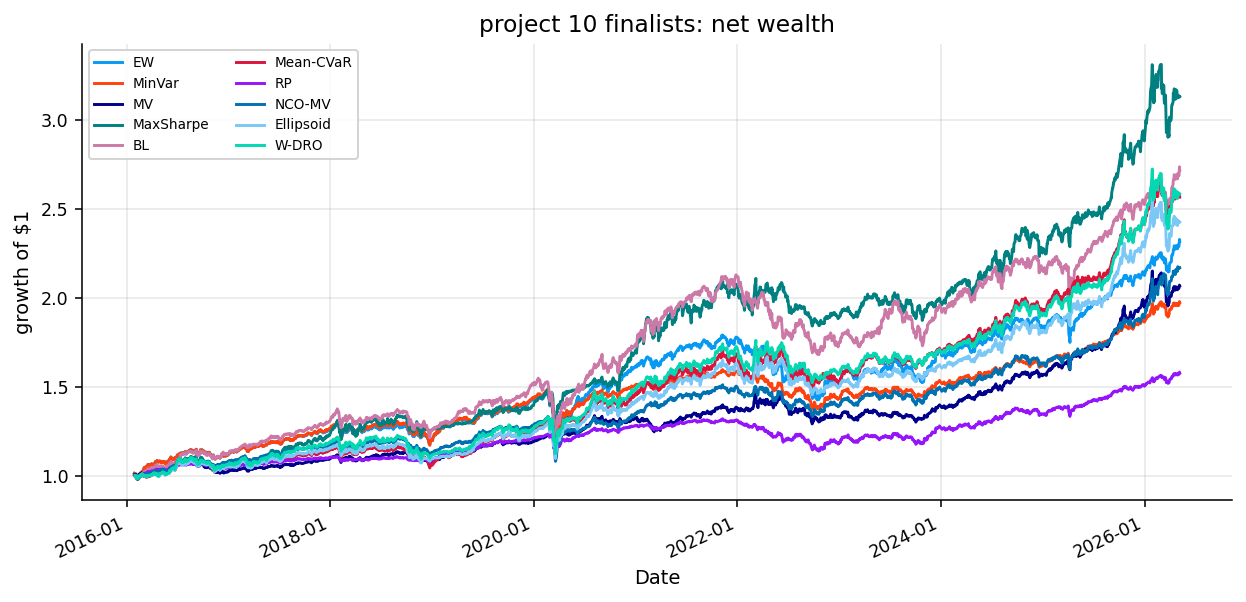

In [31]:
selected_nav = pd.DataFrame({name: results[name].net_values for name in selected_models}).dropna(how="all")
fig, ax = plt.subplots(figsize=(9.0, 4.4))
plot_strategy_nav(selected_nav[selected_models], ax=ax, title="project 10 finalists: net wealth", labels=short_labels(selected_models))
ax.set_ylabel("growth of $1")
small_legend(ax, loc="upper left")
plt.tight_layout()
plt.show()


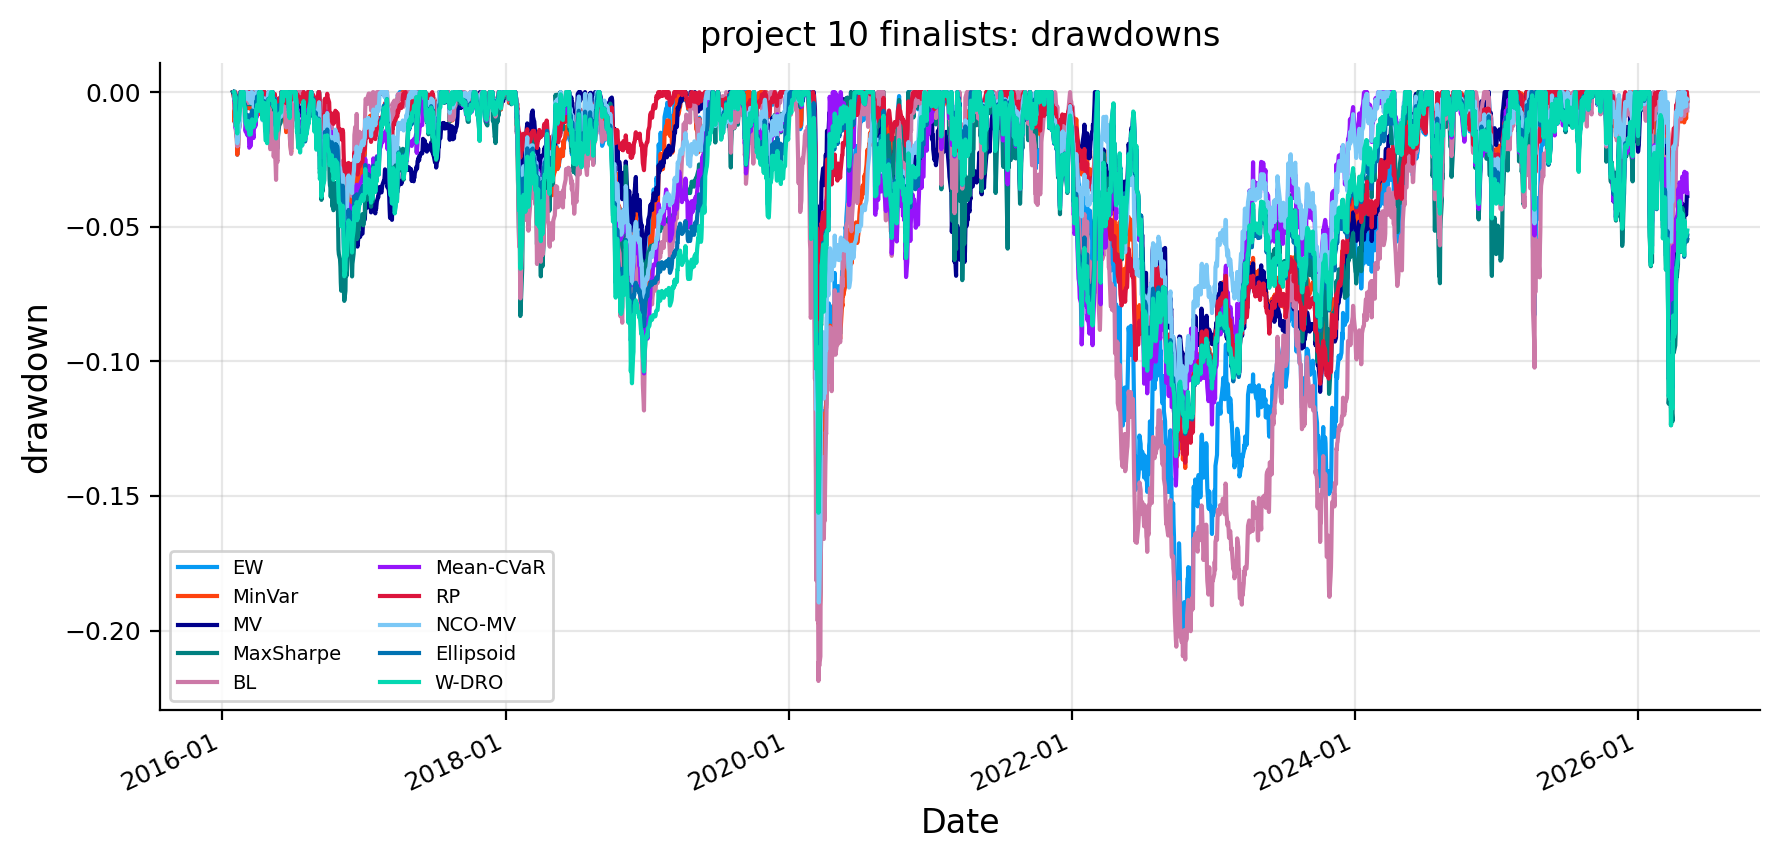

In [32]:
selected_nav = pd.DataFrame({name: results[name].net_values for name in selected_models}).dropna(how="all")
fig, ax = plt.subplots(figsize=(9.0, 4.4))
plot_strategy_drawdowns(selected_nav[selected_models], ax=ax, title="project 10 finalists: drawdowns", labels=short_labels(selected_models))
ax.set_ylabel("drawdown")
small_legend(ax, loc="lower left")
plt.tight_layout()
plt.show()


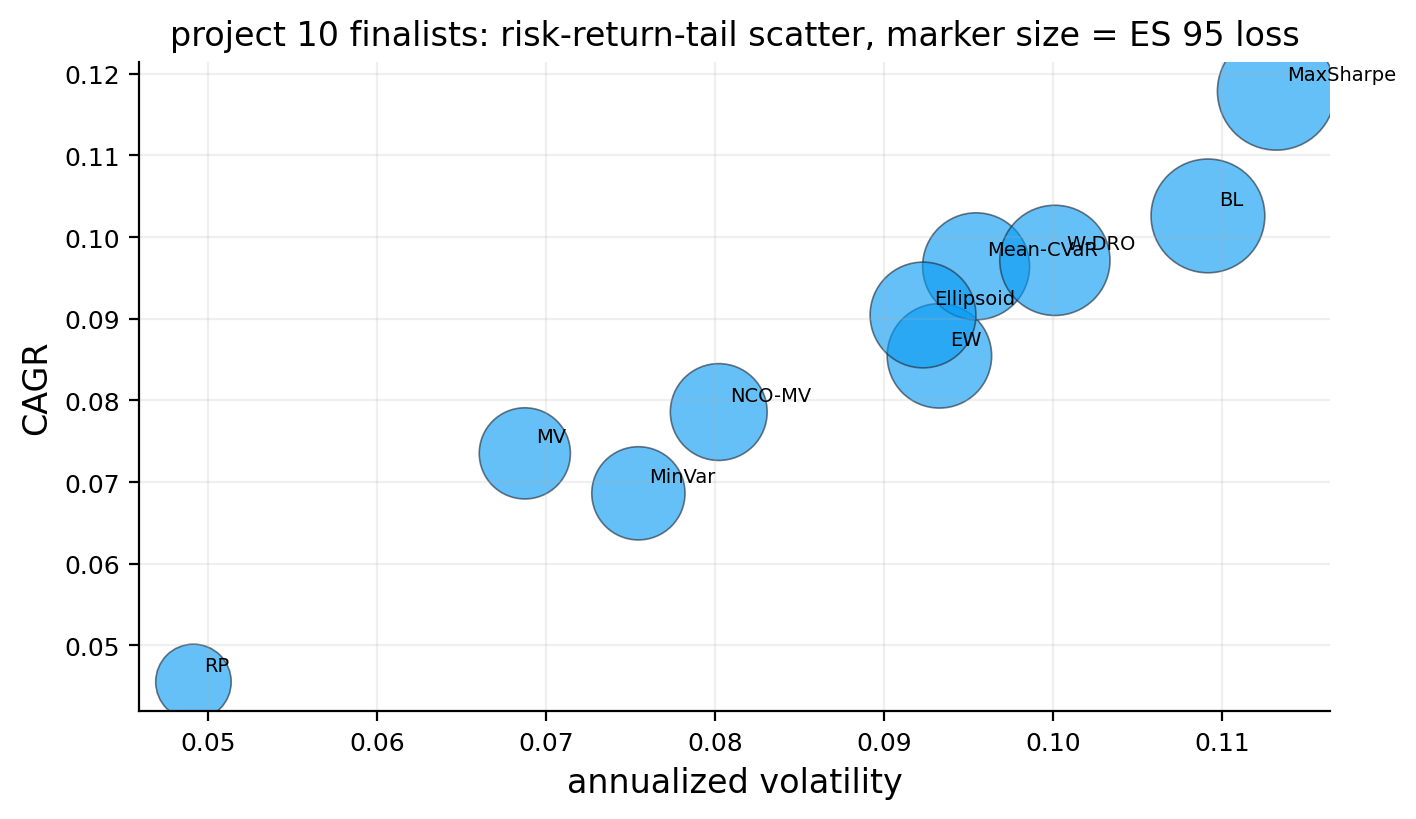

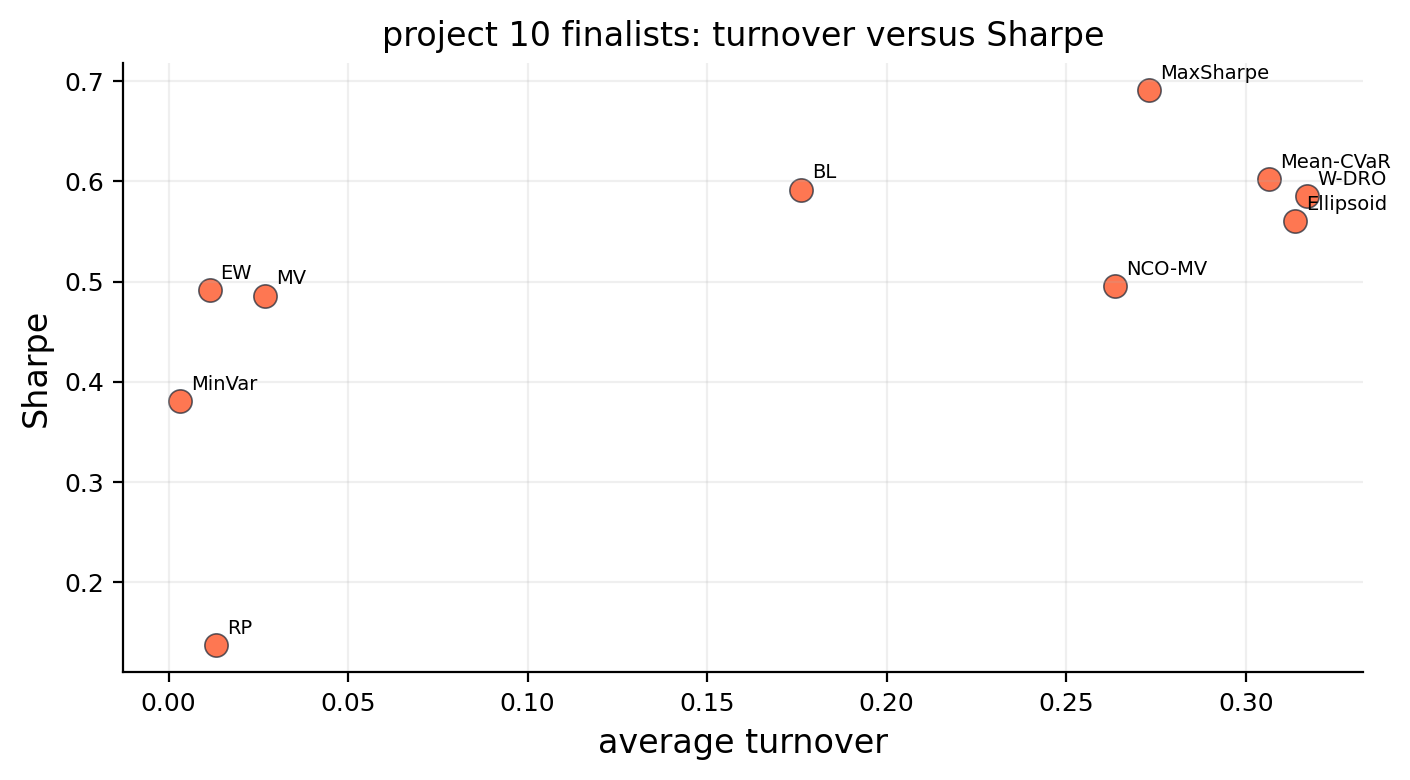

In [33]:
scatter_data = selected_scoreboard.copy()
fig, ax = plt.subplots(figsize=(7.2, 4.2))
size = 1800 * scatter_data["es_95"].abs() / scatter_data["es_95"].abs().max()
ax.scatter(scatter_data["ann_vol"], scatter_data["cagr"], s=size, alpha=0.62, color=colors[0], edgecolor="#1f2937", linewidth=0.6)
for name, row in scatter_data.iterrows():
    ax.annotate(short_label_map.get(name, name), (row["ann_vol"], row["cagr"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_title("project 10 finalists: risk-return-tail scatter, marker size = ES 95 loss")
ax.set_xlabel("annualized volatility")
ax.set_ylabel("CAGR")
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.scatter(scatter_data["avg_turnover"], scatter_data["sharpe"], s=70, alpha=0.72, color=colors[1], edgecolor="#1f2937", linewidth=0.6)
for name, row in scatter_data.iterrows():
    ax.annotate(short_label_map.get(name, name), (row["avg_turnover"], row["sharpe"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_title("project 10 finalists: turnover versus Sharpe")
ax.set_xlabel("average turnover")
ax.set_ylabel("Sharpe")
plt.tight_layout()
plt.show()


,model,asset,avg_weight
0,Equal Weight,SPY,0.0714
1,Equal Weight,QQQ,0.0714
2,Equal Weight,IWM,0.0714
3,MinVar (OAS),SHY,0.2278
4,MinVar (OAS),SPY,0.0842
5,MinVar (OAS),GLD,0.0824
6,"MV (LedoitWolf, BayesStein)",SHY,0.3339
7,"MV (LedoitWolf, BayesStein)",GLD,0.1347
8,"MV (LedoitWolf, BayesStein)",IEF,0.1000
9,"MaxSharpe (LedoitWolf, Momentum)",GLD,0.1560


,avg_equities,avg_duration,avg_credit,avg_diversifiers,avg_effective_n,avg_max_weight
Equal Weight,0.3571,0.2857,0.1429,0.2143,14.0000,0.0714
MinVar (OAS),0.2676,0.4132,0.1291,0.1901,9.1867,0.2389
"MV (LedoitWolf, BayesStein)",0.1533,0.5700,0.0656,0.2110,4.8250,0.3443
"MaxSharpe (LedoitWolf, Momentum)",0.3579,0.2675,0.0611,0.3135,3.2789,0.3857
Learned-Confidence BL,0.5789,0.2854,0.0241,0.1117,5.9795,0.2956
Mean-CVaR 95,0.2209,0.3633,0.1014,0.3144,3.3669,0.3887
Risk Parity,0.0998,0.5797,0.1924,0.1281,5.9556,0.3502
NCO-MV,0.1790,0.3484,0.2271,0.2455,5.2855,0.2750
Ellipsoid Robust MV,0.2150,0.3995,0.1053,0.2802,3.4786,0.3816
Wasserstein DRMV,0.2562,0.3413,0.0885,0.3141,3.5658,0.3761


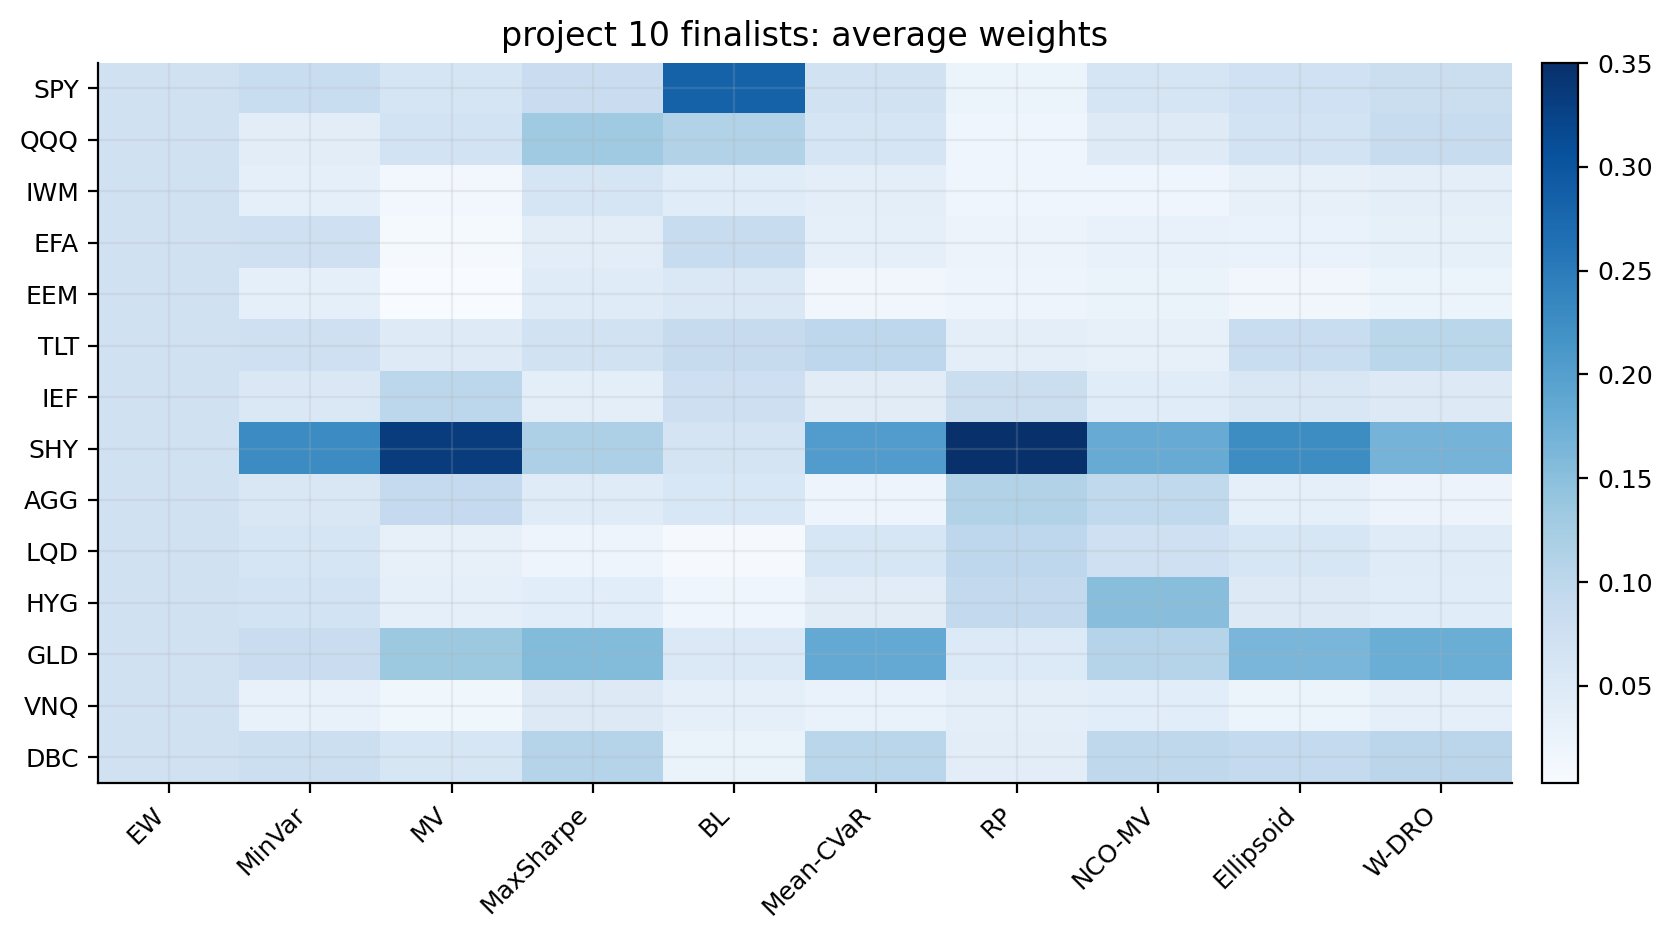

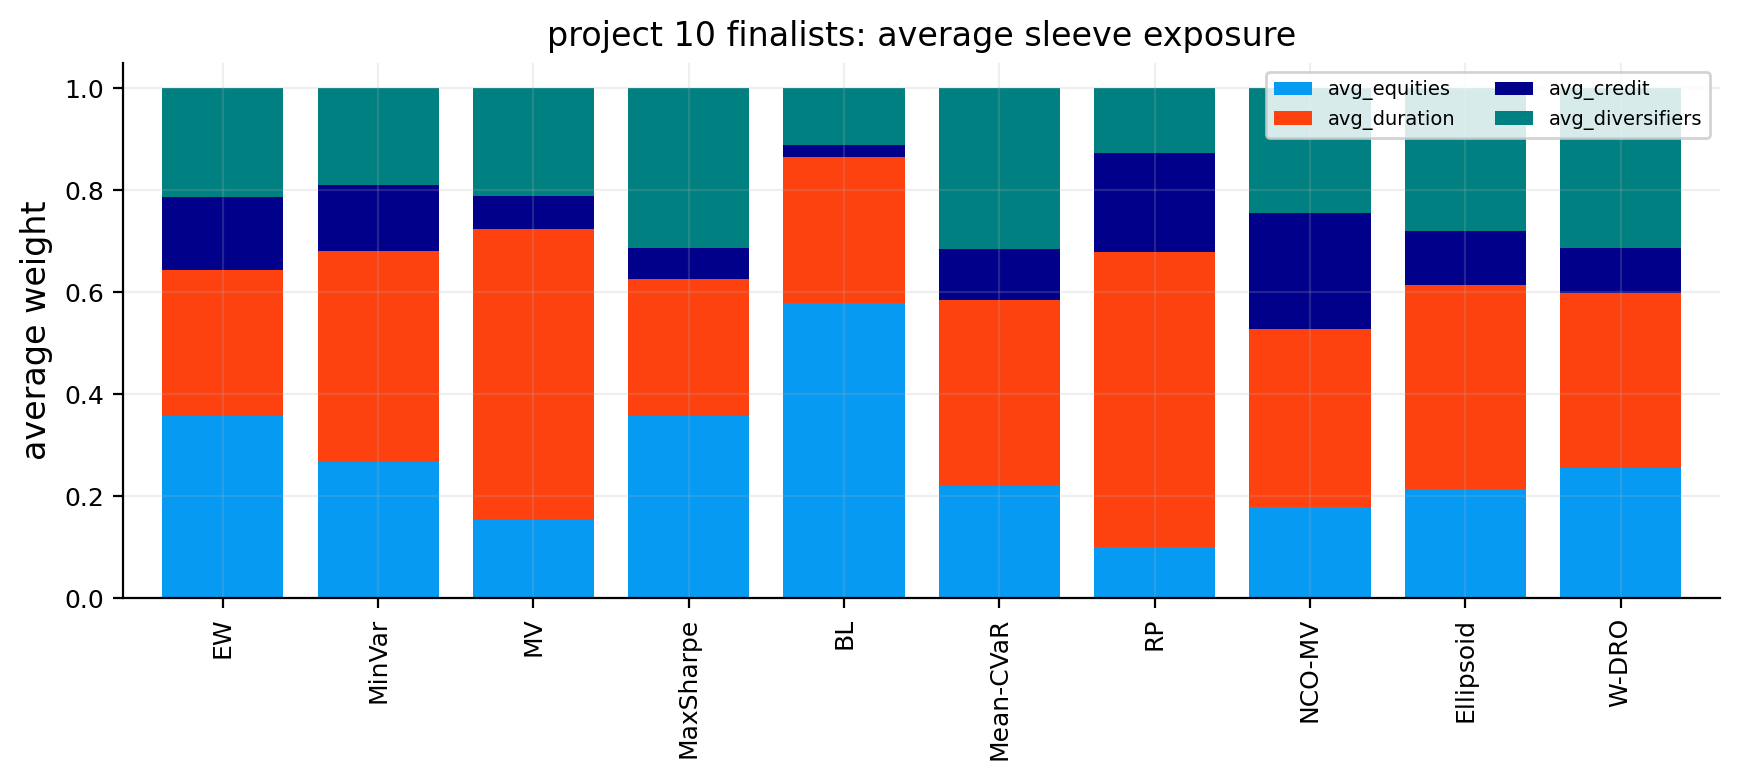

In [34]:
average_weights = pd.DataFrame({name: results[name].weights.reindex(columns=assets).mean() for name in selected_models}).reindex(assets)

def average_sleeves(result):
    w = result.weights.reindex(columns=assets).fillna(0.0)
    row = {}
    for sleeve, members in sleeve_groups.items():
        row[f"avg_{sleeve}"] = float(w[members].sum(axis=1).mean())
    row["avg_effective_n"] = float((1.0 / (w.pow(2).sum(axis=1))).replace([np.inf, -np.inf], np.nan).mean())
    row["avg_max_weight"] = float(w.max(axis=1).mean())
    return row

sleeve_exposure = pd.DataFrame({name: average_sleeves(results[name]) for name in selected_models}).T
top_average_holdings = []
for name in selected_models:
    for asset, value in average_weights[name].nlargest(3).items():
        top_average_holdings.append({"model": name, "asset": asset, "avg_weight": value})
top_average_holdings = pd.DataFrame(top_average_holdings)
display(top_average_holdings.round(4))
display(sleeve_exposure.round(4))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
im = ax.imshow(average_weights.fillna(0.0).values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(average_weights.columns)))
ax.set_xticklabels(short_labels(average_weights.columns), rotation=45, ha="right")
ax.set_yticks(range(len(average_weights.index)))
ax.set_yticklabels(average_weights.index)
ax.set_title("project 10 finalists: average weights")
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
plt.tight_layout()
plt.show()
sleeve_cols = [f"avg_{s}" for s in sleeve_groups]
sleeve_plot = sleeve_exposure[sleeve_cols].copy()
sleeve_plot.index = short_labels(sleeve_plot.index)
ax = sleeve_plot.plot(kind="bar", stacked=True, figsize=(8.8, 4.0), width=0.78)
ax.set_title("project 10 finalists: average sleeve exposure")
ax.set_ylabel("average weight")
small_legend(ax, loc="upper right")
plt.tight_layout()
plt.show()


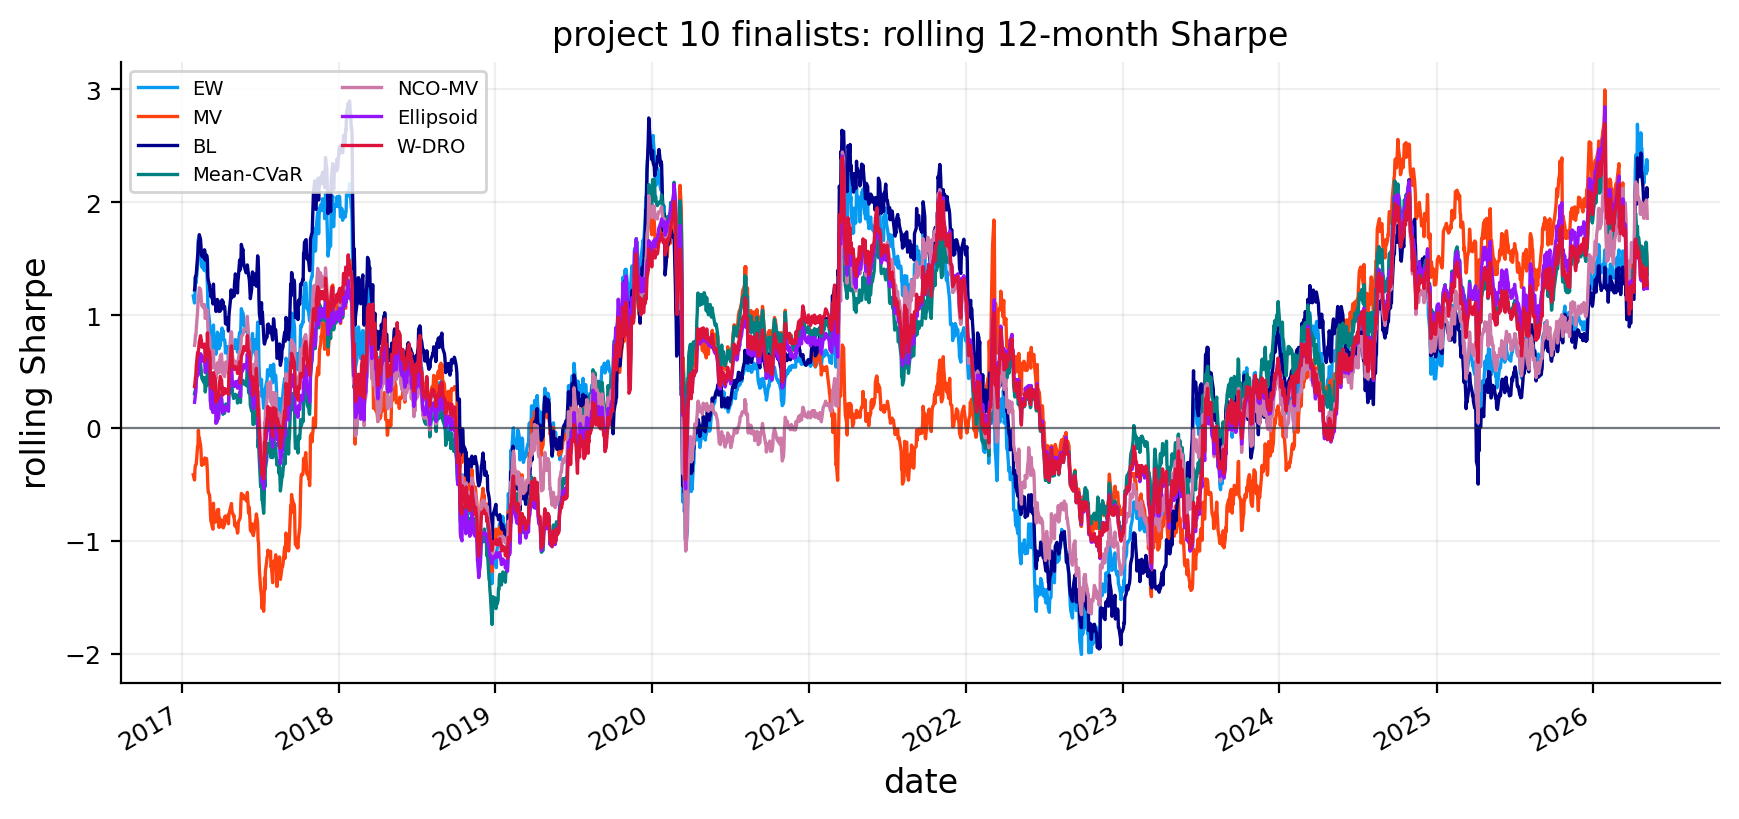

date,latest_12m_return
Equal Weight,0.2291
"MV (LedoitWolf, BayesStein)",0.2117
Learned-Confidence BL,0.2476
Mean-CVaR 95,0.2111
NCO-MV,0.2663
Ellipsoid Robust MV,0.2238
Wasserstein DRMV,0.2419


In [35]:
selected_returns = pd.DataFrame({name: results[name].net_returns for name in selected_models}).dropna(how="all")
rolling_return_252 = (1.0 + selected_returns).rolling(252).apply(np.prod, raw=True) - 1.0
rolling_vol_252 = selected_returns.rolling(252).std() * np.sqrt(annualization)
rolling_mean_252 = selected_returns.rolling(252).mean() * annualization
rolling_sharpe_252 = (rolling_mean_252 - risk_free_rate_annual) / rolling_vol_252

rolling_plot_names = selected_models
if len(rolling_plot_names) > 7:
    rolling_plot_names = list(dict.fromkeys(["Equal Weight", best_mv_name, "Learned-Confidence BL", best_cvar_name, best_hier_name, best_robust_name, "Wasserstein DRMV"]))

fig, ax = plt.subplots(figsize=(8.8, 4.2))
rolling_sharpe_252[rolling_plot_names].rename(columns=dict(zip(rolling_plot_names, short_labels(rolling_plot_names)))).plot(ax=ax, linewidth=1.2)
ax.axhline(0.0, color="#1f2937", linewidth=0.8, alpha=0.6)
ax.set_title("project 10 finalists: rolling 12-month Sharpe")
ax.set_ylabel("rolling Sharpe")
small_legend(ax, loc="upper left")
plt.tight_layout()
plt.show()

display(rolling_return_252[rolling_plot_names].tail(1).T.rename(columns={rolling_return_252.index[-1]: "latest_12m_return"}).round(4))


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
BL,0.0103,0.0164,0.0107,0.0259,0.0122,0.0184
EW,0.0085,0.0138,0.0091,0.0244,0.0102,0.0155
Ellipsoid,0.0088,0.0142,0.0097,0.0209,0.0166,0.0244
MV,0.0064,0.0105,0.0071,0.0154,0.0107,0.0160
MaxSharpe,0.0114,0.0176,0.0118,0.0214,0.0190,0.0271
Mean-CVaR,0.0090,0.0145,0.0099,0.0198,0.0113,0.0165
MinVar,0.0066,0.0110,0.0072,0.0279,0.0073,0.0113
NCO-MV,0.0072,0.0119,0.0080,0.0222,0.0113,0.0172
RP,0.0045,0.0072,0.0047,0.0122,0.0056,0.0084


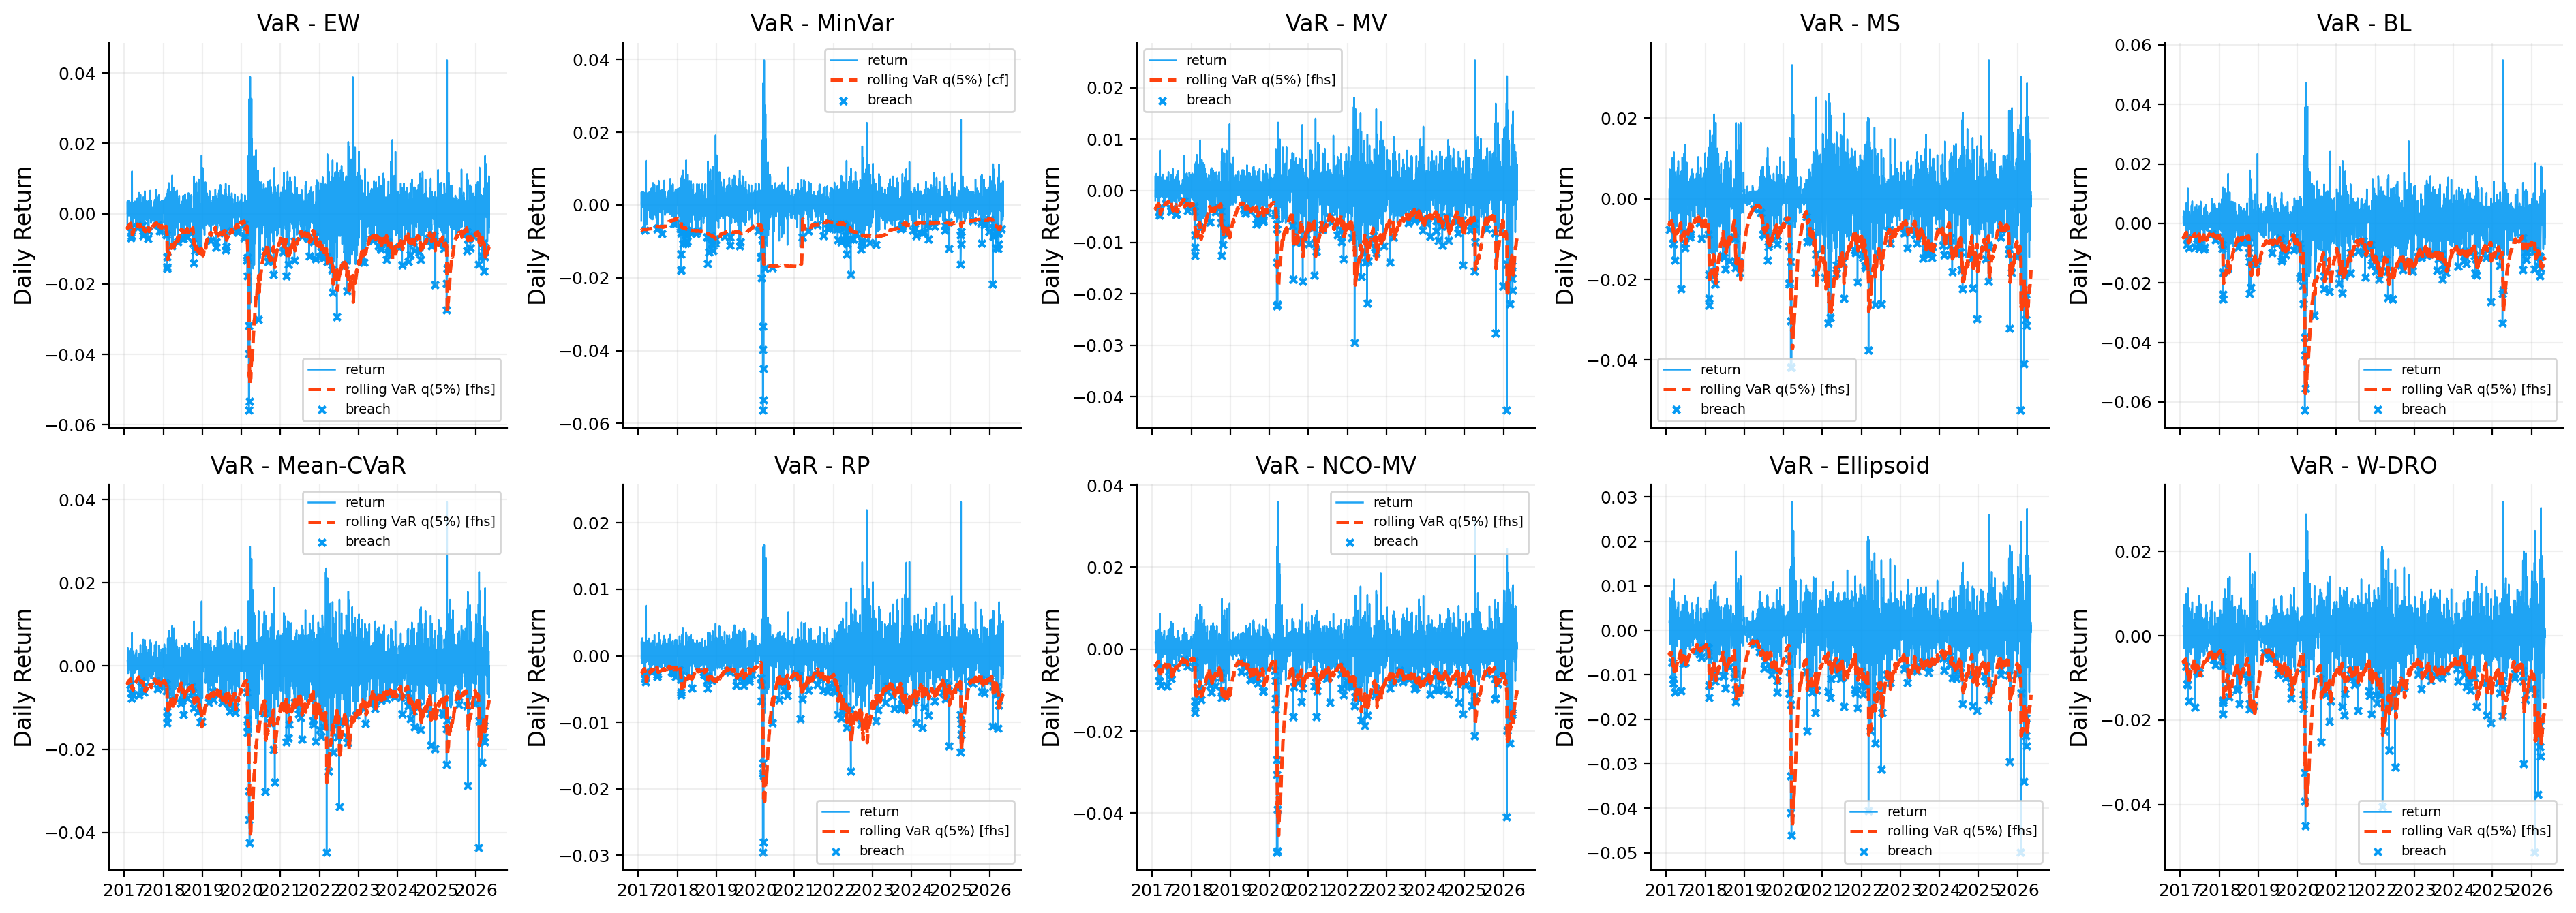

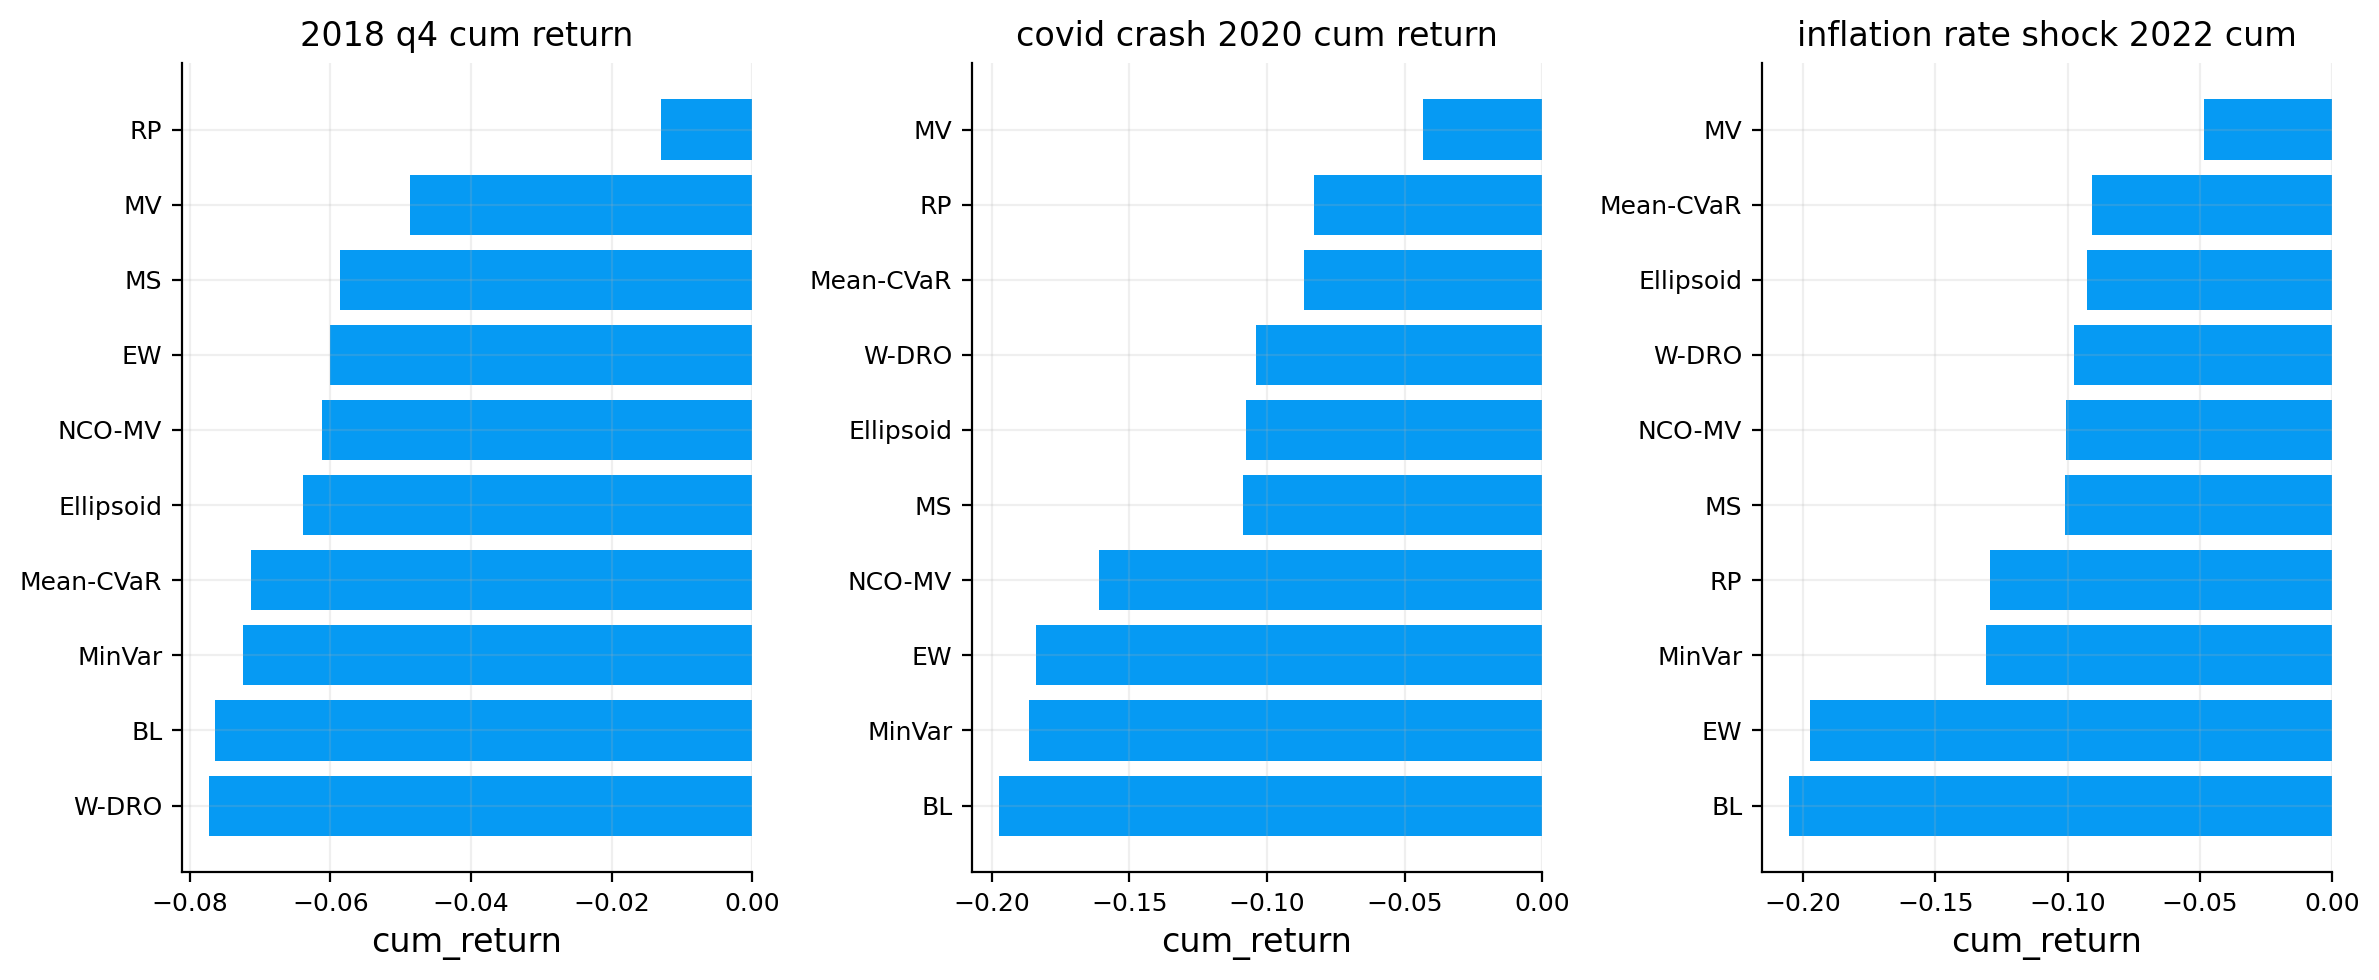

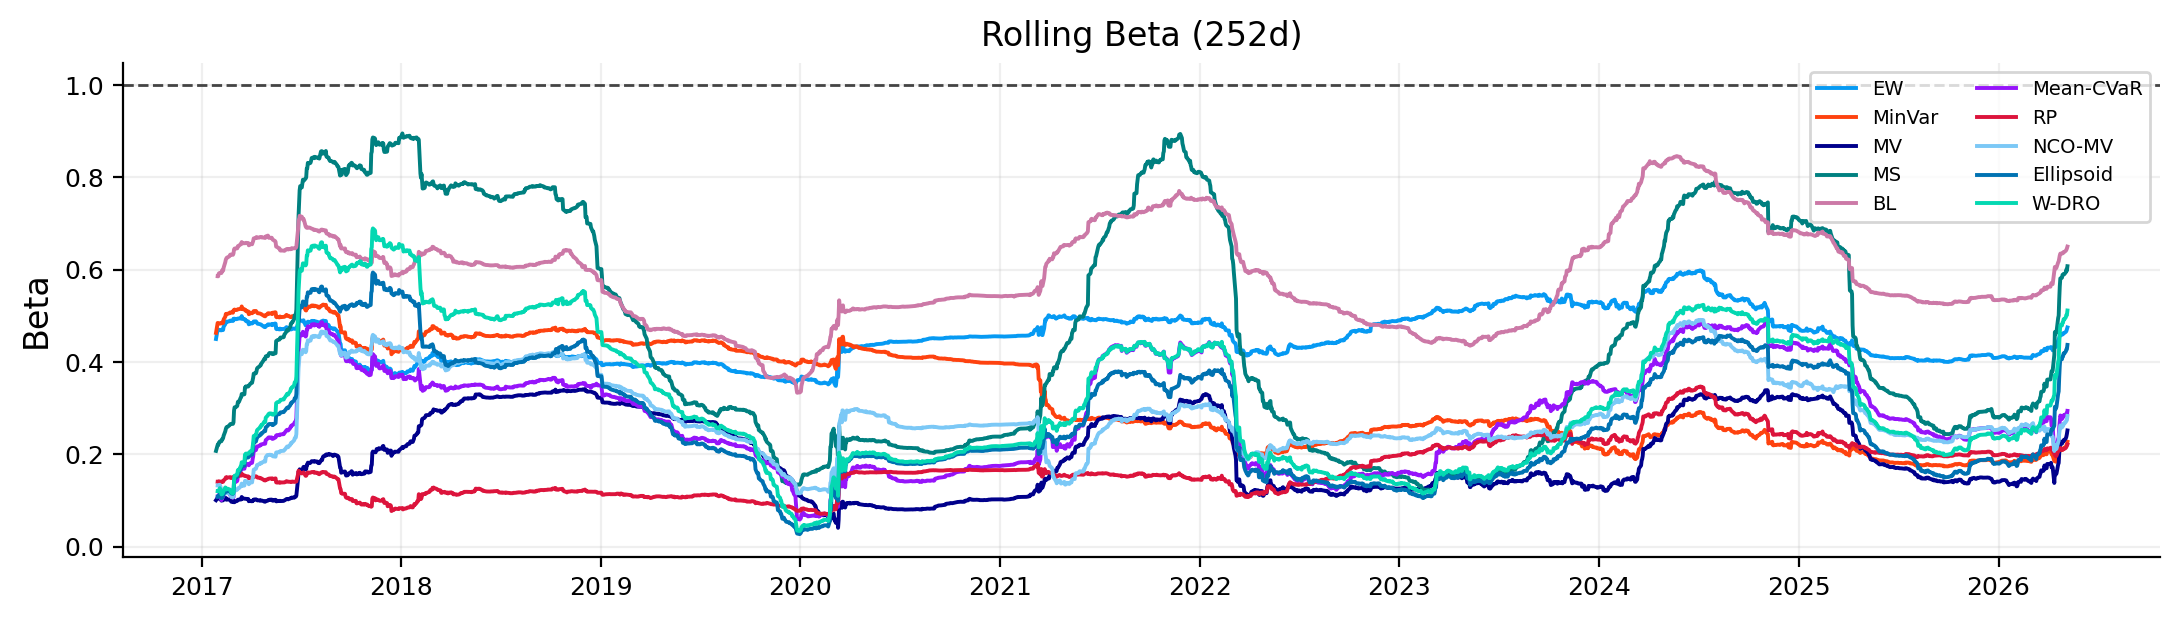

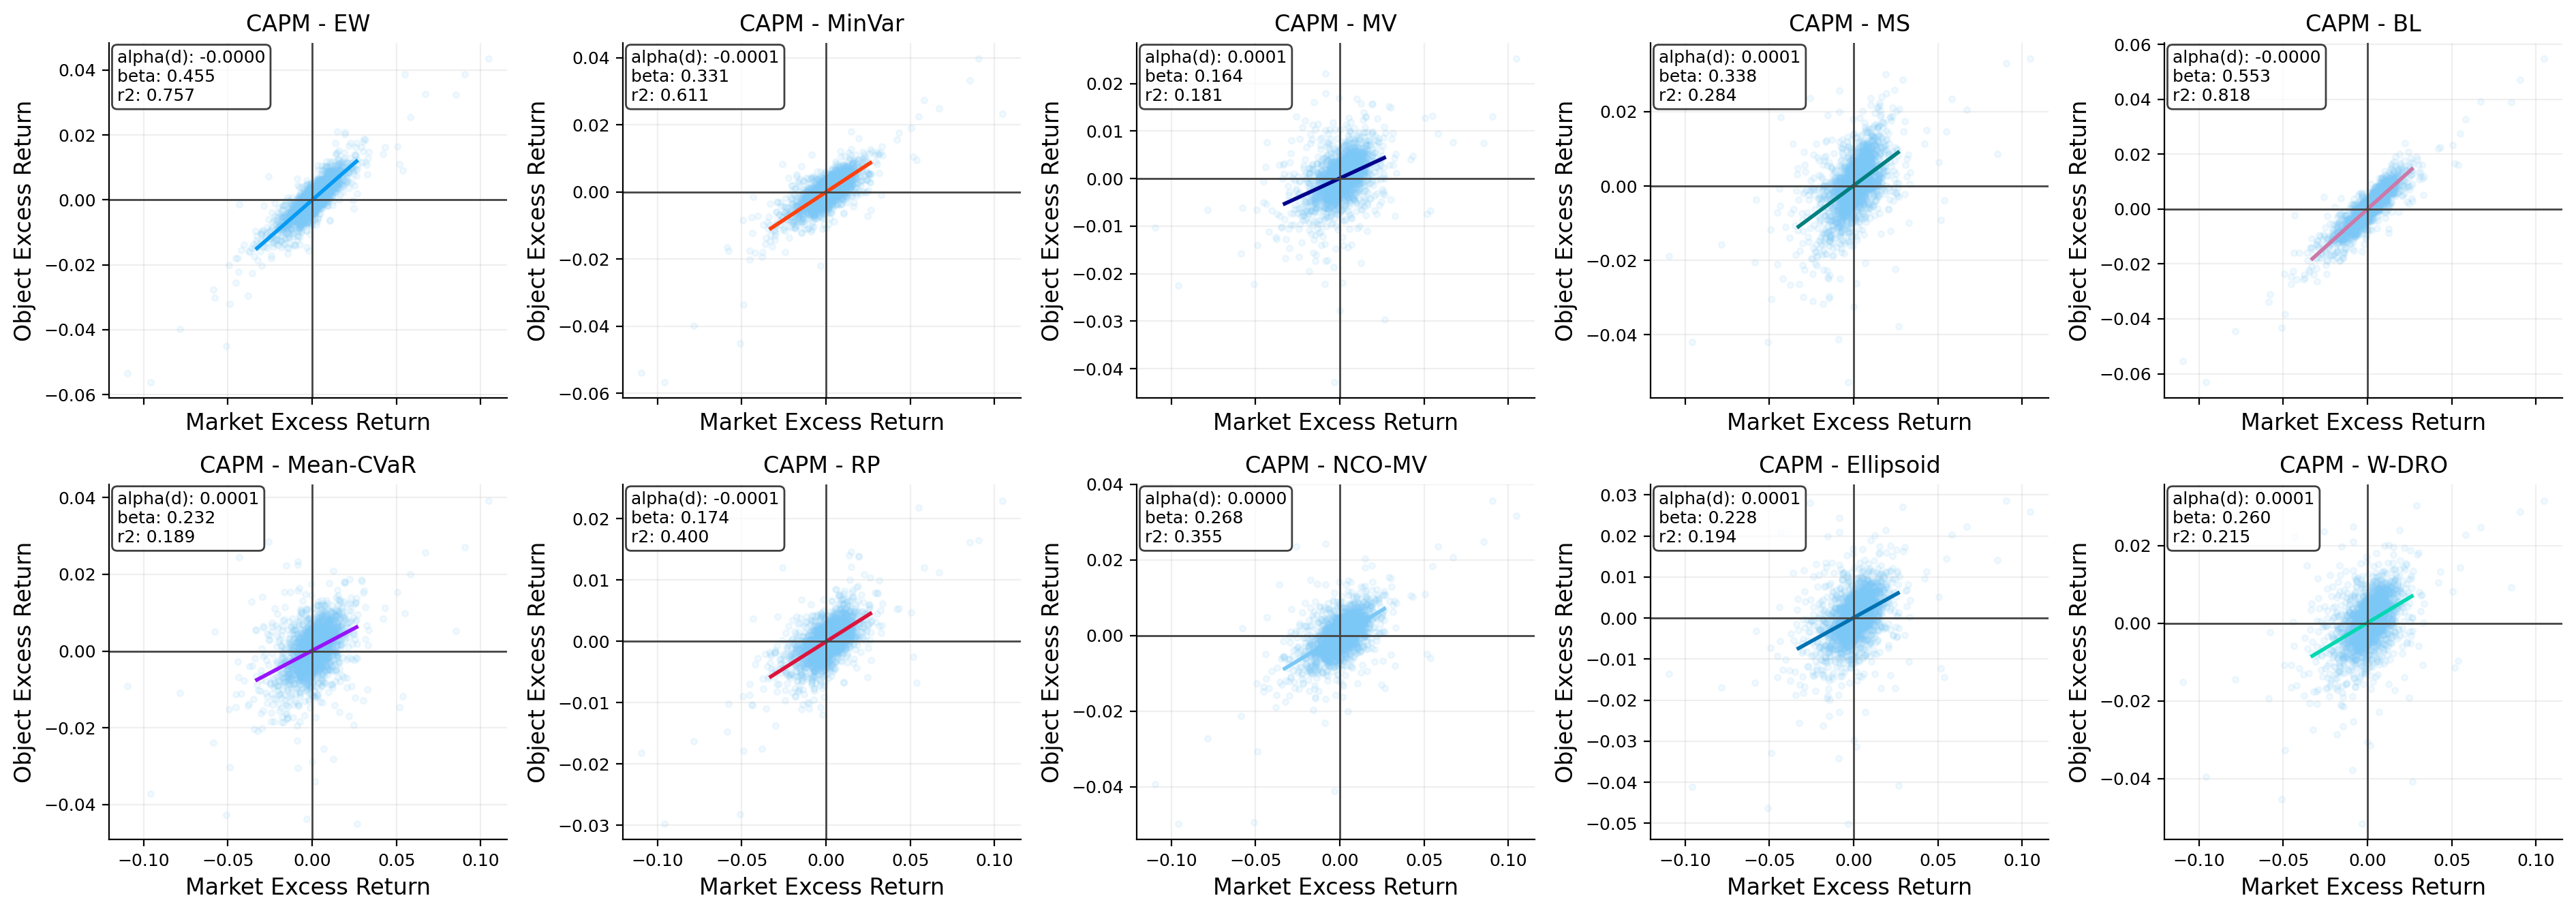

In [36]:
risk_returns = selected_returns.dropna(how="all")
stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "covid_crash_2020": ("2020-02-19", "2020-03-23"),
    "inflation_rate_shock_2022": ("2022-01-03", "2022-10-14"),
}

spy_ref = returns["SPY"].reindex(risk_returns.index).dropna()
label_overrides = dict(zip(selected_models, short_labels(selected_models)))
risk_report_artifacts = risk_report(
    objects={name: risk_returns[name] for name in selected_models},
    market_ret=spy_ref,
    rf_daily=risk_free_daily,
    include={"performance_tables": False, "shape_tables": False, "drawdowns": False, "drawdown_episodes": False, "var_es": True, "var_backtest": True, "stress": True, "capm": True, "rolling_beta": True, "correlation": False, "attribution": False, "exec_bullets": False},
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    rolling_settings={"vol_windows": [252], "beta_windows": [252]},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": 5, "sharex": True, "sharey": False},
    output={"display_table_keys": ["var_es"], "round_tables": 4, "print_exec_bullets": False, "show_figures": False, "short_labels": True, "label_max_len": 12, "label_map": label_overrides},
)
risk_report_tables = risk_report_artifacts.tables
stress = risk_report_artifacts.series.get("stress_full", risk_report_tables.get("stress"))
var_es = risk_report_tables["var_es"]
var_backtest = risk_report_tables["var_backtest"]
for key in ["var_backtest", "stress", "rolling_beta"]:
    for fig in risk_report_artifacts.figures.get(key, []):
        display(fig)
        plt.close(fig)


In [37]:

criterion_rows = []
criteria = [
    ("highest cagr", "cagr", False),
    ("highest sharpe", "sharpe", False),
    ("highest sortino", "sortino", False),
    ("highest calmar", "calmar", False),
    ("lowest max drawdown", "max_drawdown", False),
    ("lowest es 95", "es_95", True),
    ("lowest avg turnover", "avg_turnover", True),
    ("highest avg effective n", "avg_effective_n", False),
]
for criterion, column, ascending in criteria:
    values = selected_scoreboard[column].dropna()
    winner = values.sort_values(ascending=ascending).index[0]
    criterion_rows.append({"criterion": criterion, "winner": winner, "value": values.loc[winner]})

rank_data = selected_scoreboard.copy()
rank_table = pd.DataFrame(index=rank_data.index)
rank_table["sharpe_rank"] = rank_data["sharpe"].rank(ascending=False, method="min")
rank_table["calmar_rank"] = rank_data["calmar"].rank(ascending=False, method="min")
rank_table["es_95_rank"] = rank_data["es_95"].rank(ascending=True, method="min")
rank_table["max_drawdown_rank"] = rank_data["max_drawdown"].rank(ascending=False, method="min")
rank_table["avg_turnover_rank"] = rank_data["avg_turnover"].rank(ascending=True, method="min")
rank_table["avg_effective_n_rank"] = rank_data["avg_effective_n"].rank(ascending=False, method="min")
rank_table["balanced_rank_score"] = (
    0.25 * rank_table["sharpe_rank"]
    + 0.20 * rank_table["calmar_rank"]
    + 0.20 * rank_table["es_95_rank"]
    + 0.15 * rank_table["max_drawdown_rank"]
    + 0.10 * rank_table["avg_turnover_rank"]
    + 0.10 * rank_table["avg_effective_n_rank"]
)
rank_table = rank_table.sort_values("balanced_rank_score")
criterion_rows.append({"criterion": "best balanced rank", "winner": rank_table.index[0], "value": rank_table.iloc[0]["balanced_rank_score"]})

display(pd.DataFrame(criterion_rows).set_index("criterion").round(4))
display(rank_table.round(3))


,winner,value
criterion,,
highest cagr,"MaxSharpe (LedoitWolf, Momentum)",0.1179
highest sharpe,"MaxSharpe (LedoitWolf, Momentum)",0.6908
highest sortino,"MaxSharpe (LedoitWolf, Momentum)",0.8527
highest calmar,"MaxSharpe (LedoitWolf, Momentum)",0.7623
lowest max drawdown,"MV (LedoitWolf, BayesStein)",-0.1181
lowest es 95,Risk Parity,0.0072
lowest avg turnover,MinVar (OAS),0.0031
highest avg effective n,Equal Weight,14.0000
best balanced rank,"MV (LedoitWolf, BayesStein)",4.1500


,sharpe_rank,calmar_rank,es_95_rank,max_drawdown_rank,avg_turnover_rank,avg_effective_n_rank,balanced_rank_score
Strategy,,,,,,,
"MV (LedoitWolf, BayesStein)",8.0,3.0,2.0,1.0,4.0,6.0,4.15
Mean-CVaR 95,2.0,2.0,7.0,3.0,8.0,9.0,4.45
"MaxSharpe (LedoitWolf, Momentum)",1.0,1.0,10.0,4.0,7.0,10.0,4.75
Risk Parity,10.0,10.0,1.0,2.0,3.0,4.0,5.70
Equal Weight,7.0,7.0,5.0,9.0,2.0,1.0,5.80
Ellipsoid Robust MV,5.0,5.0,6.0,5.0,9.0,8.0,5.90
Wasserstein DRMV,4.0,4.0,8.0,6.0,10.0,7.0,6.00
Learned-Confidence BL,3.0,6.0,9.0,10.0,5.0,3.0,6.05
NCO-MV,6.0,8.0,4.0,7.0,6.0,5.0,6.05


In [38]:

selected_reason_lookup = selected_reason["role"].to_dict()
selected_from_lookup = selected_reason["selected_from"].to_dict()
final_comparison = selected_scoreboard[["cagr", "sharpe", "calmar", "max_drawdown", "es_95", "avg_turnover", "avg_effective_n"]].copy()
final_comparison.insert(0, "role", [selected_reason_lookup[name] for name in final_comparison.index])
final_comparison.insert(0, "model", final_comparison.index)
final_comparison["selected_reason"] = [selected_from_lookup[name] for name in final_comparison["model"]]
final_comparison = final_comparison.reset_index(drop=True)
display(final_comparison.round(4))


,model,role,cagr,sharpe,calmar,max_drawdown,es_95,avg_turnover,avg_effective_n,selected_reason
0,Equal Weight,baseline,0.0855,0.4916,0.4187,-0.2041,0.0138,0.0114,14.0000,project 2 grid
1,MinVar (OAS),minimum variance benchmark,0.0686,0.3806,0.3476,-0.1975,0.0110,0.0031,9.1867,project 2 grid
2,"MV (LedoitWolf, BayesStein)",mean-variance benchmark,0.0735,0.4860,0.6225,-0.1181,0.0105,0.0270,4.8250,project 2 grid
3,"MaxSharpe (LedoitWolf, Momentum)",sharpe/frontier benchmark,0.1179,0.6908,0.7623,-0.1546,0.0176,0.2730,3.2789,project 2 grid
4,Learned-Confidence BL,black-litterman benchmark,0.1026,0.5918,0.4691,-0.2187,0.0164,0.1762,5.9795,project 6 rebuild
5,Mean-CVaR 95,tail-risk allocation,0.0964,0.6025,0.6598,-0.1461,0.0145,0.3063,3.3669,Min-CVaR 95 vs Mean-CVaR 95
6,Risk Parity,risk budget allocation,0.0455,0.1376,0.3308,-0.1377,0.0072,0.0131,5.9556,single specified model
7,NCO-MV,hierarchical allocation,0.0786,0.4958,0.4145,-0.1896,0.0119,0.2637,5.2855,HRP vs NCO-MV
8,Ellipsoid Robust MV,robust mean-variance,0.0905,0.5608,0.5803,-0.1559,0.0142,0.3137,3.4786,Box Robust MV vs Ellipsoid Robust MV
9,Wasserstein DRMV,distributionally robust allocation,0.0972,0.5856,0.6218,-0.1563,0.0154,0.3169,3.5658,single specified model


sector returns: (1972, 11) 2018-07-03 to 2026-05-07
rebalance dates: 59 2021-07-30 to 2026-05-07
selected grid models: {'MinVar': 'MinVar (LedoitWolf)', 'MV': 'MV (EWMA, BayesStein)', 'MaxSharpe': 'MaxSharpe (LedoitWolf, BayesStein)'}
BL view rows: 244 candidate, 202 selected


,CAGR,Vol,Sharpe,Sortino,Calmar,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,,
Equal Weight,0.1062,0.1494,0.4942,0.6758,0.5525,-0.1923,0.0133,11.0000
MinVar,0.0707,0.1317,0.2907,0.4103,0.3669,-0.1927,0.0060,5.1148
MV,0.0965,0.1397,0.4542,0.6181,0.6193,-0.1559,0.1112,3.7124
MaxSharpe,0.1721,0.1635,0.8226,1.1335,1.0871,-0.1583,0.1729,2.9823
Learned-Confidence BL,0.1182,0.1525,0.5585,0.7764,0.6107,-0.1935,0.1418,8.2425


,CAGR,Vol,Sharpe,Sortino,Calmar,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,,
Equal Weight,0.1062,0.1494,0.4942,0.6758,0.5525,-0.1923,0.0133,11.0000
MinVar,0.0707,0.1317,0.2907,0.4103,0.3669,-0.1927,0.0060,5.1148
MV,0.0965,0.1397,0.4542,0.6181,0.6193,-0.1559,0.1112,3.7124
MaxSharpe,0.1721,0.1635,0.8226,1.1335,1.0871,-0.1583,0.1729,2.9823
Learned-Confidence BL,0.1182,0.1525,0.5585,0.7764,0.6107,-0.1935,0.1418,8.2425
Mean-CVaR 95,0.0819,0.1321,0.3712,0.5156,0.5114,-0.1600,0.2122,3.6270
Risk Parity,0.0953,0.1443,0.4347,0.5950,0.4859,-0.1961,0.0223,10.5099
NCO-MV,0.0965,0.1382,0.4561,0.6470,0.5647,-0.1709,0.1936,4.7593
Ellipsoid Robust MV,0.1154,0.1426,0.5668,0.7914,0.7484,-0.1542,0.2147,3.1676


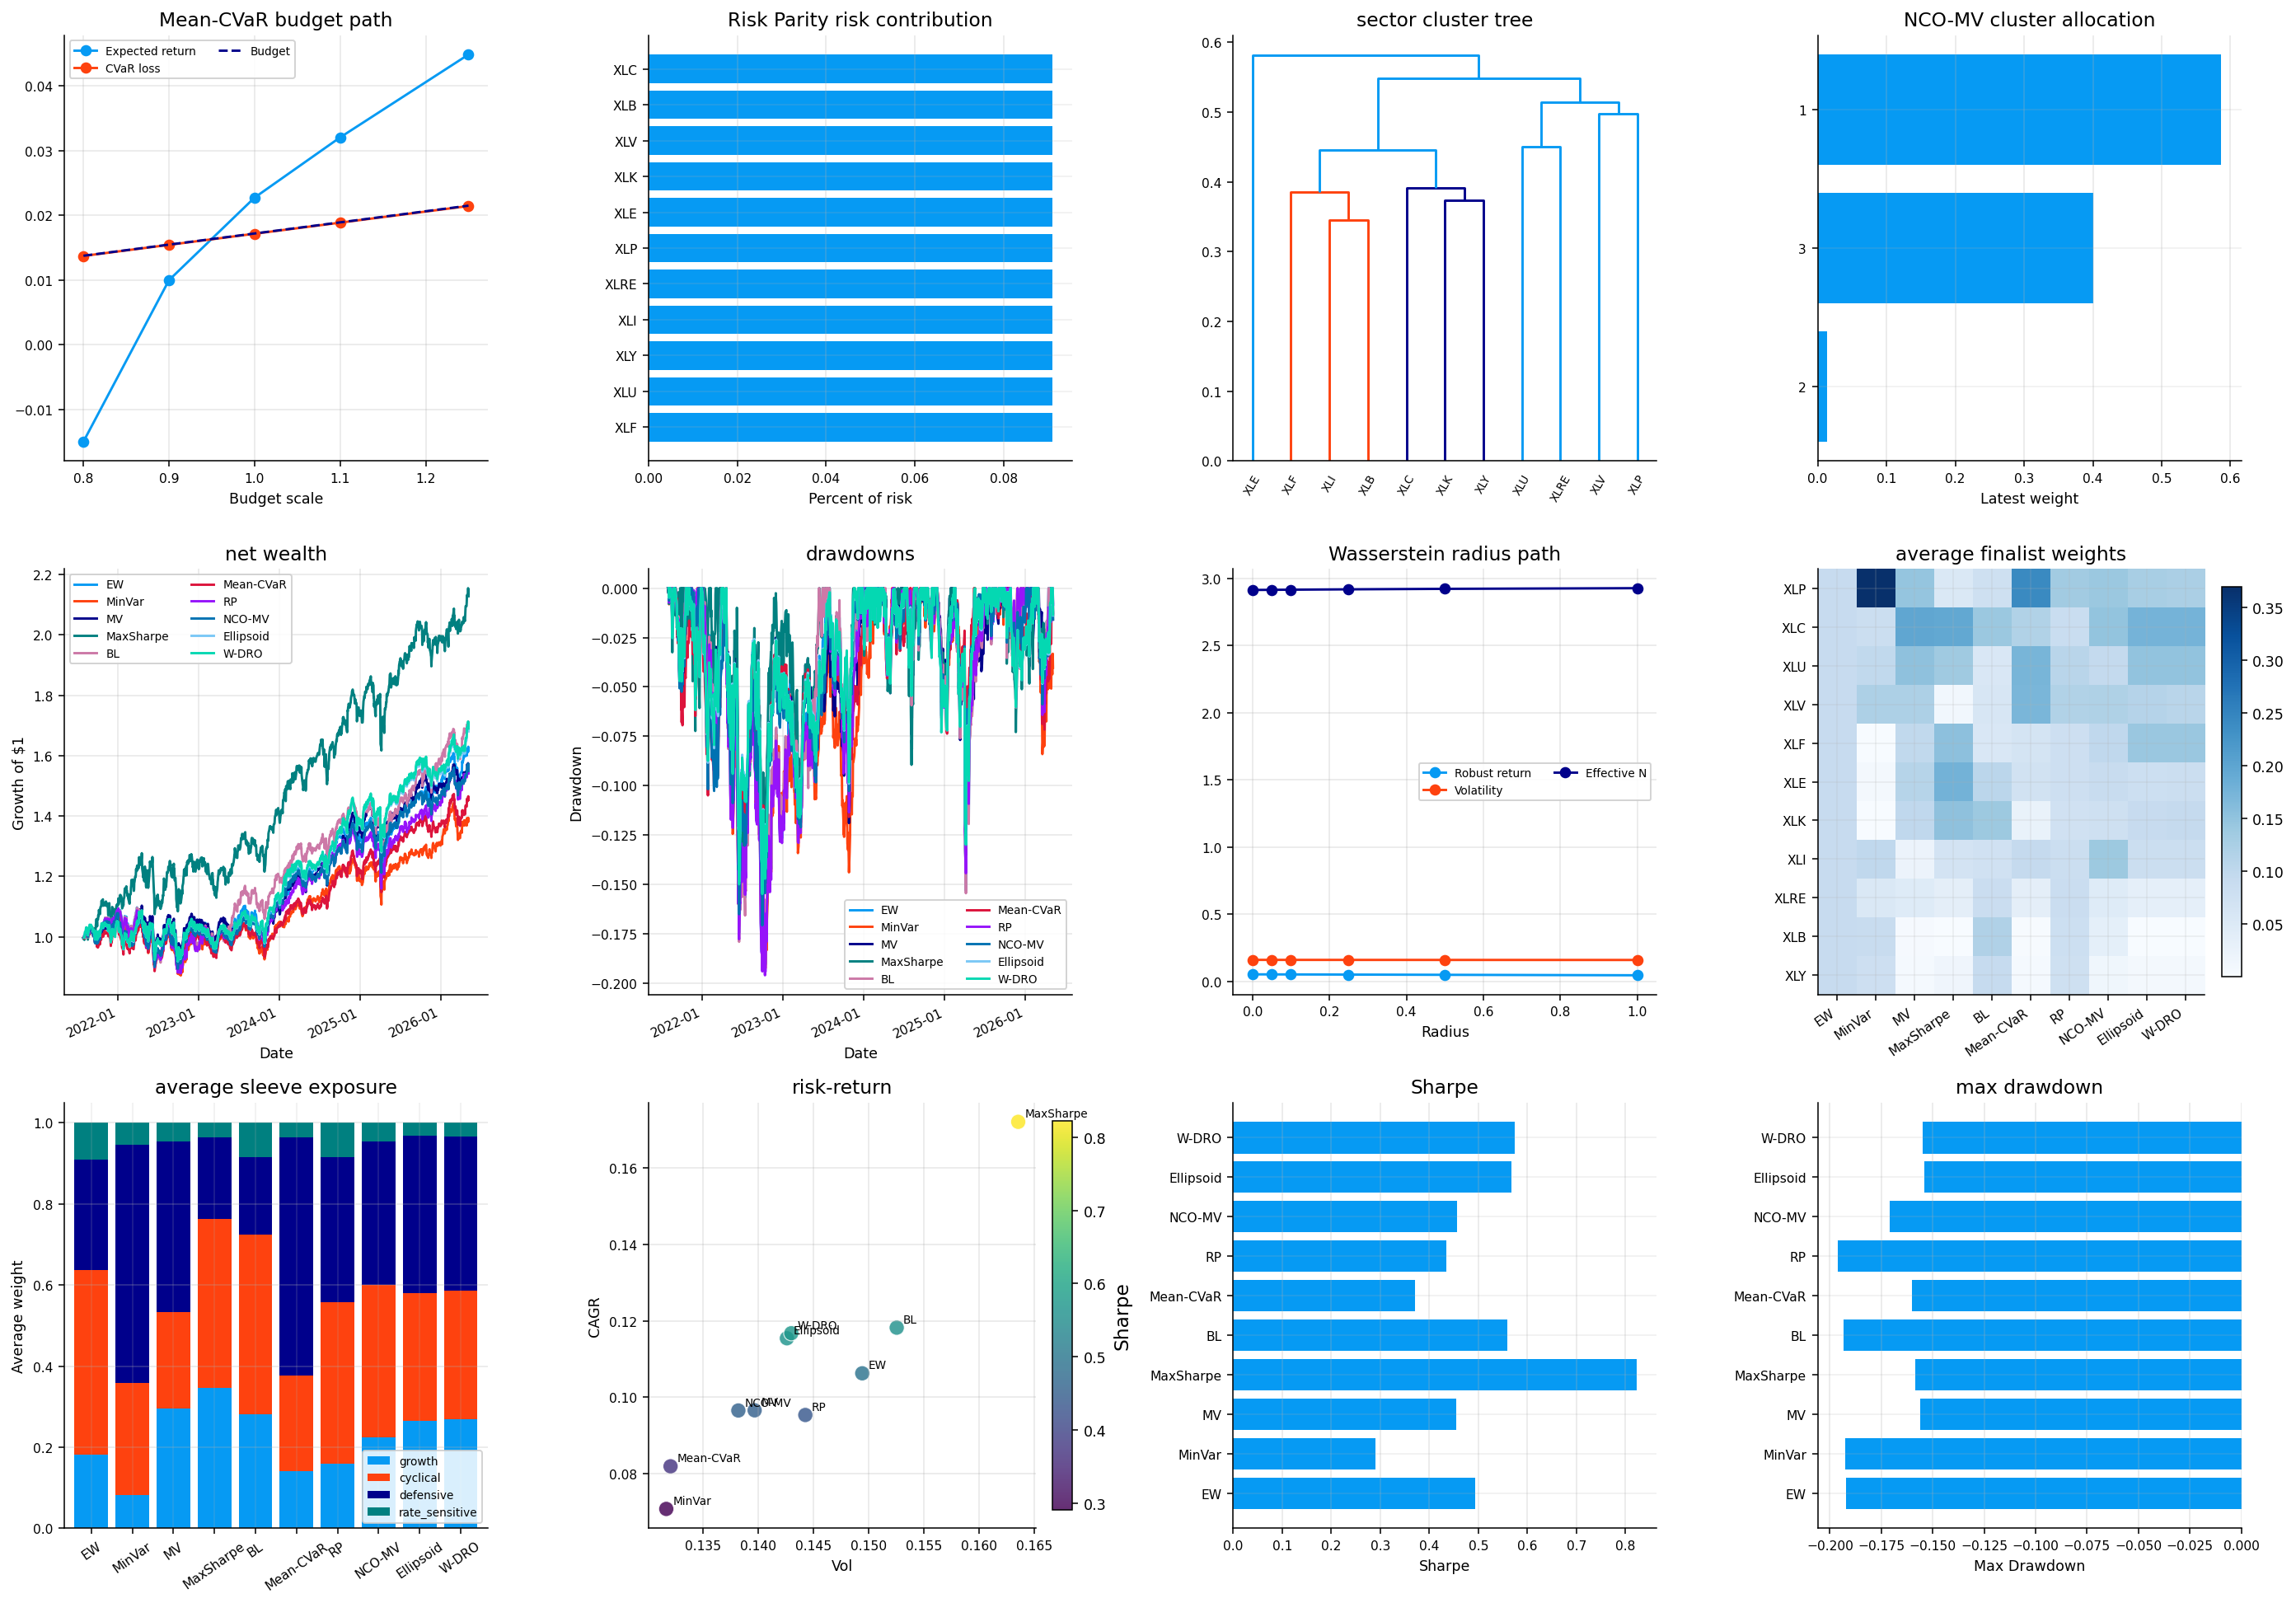

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
BL,0.0144,0.0221,0.0144,0.0273,0.0105,0.0151
EW,0.0140,0.0216,0.0138,0.0280,0.0112,0.0156
Ellipsoid,0.0141,0.0204,0.0142,0.0252,0.0108,0.0161
MV,0.0138,0.0205,0.0139,0.0254,0.0093,0.0135
MaxSharpe,0.0159,0.0237,0.0165,0.0273,0.0102,0.0146
Mean-CVaR,0.0126,0.0190,0.0132,0.0235,0.0120,0.0169
MinVar,0.0124,0.0187,0.0128,0.0236,0.0125,0.0179
NCO-MV,0.0137,0.0195,0.0137,0.0232,0.0104,0.0148
RP,0.0134,0.0210,0.0136,0.0269,0.0105,0.0150


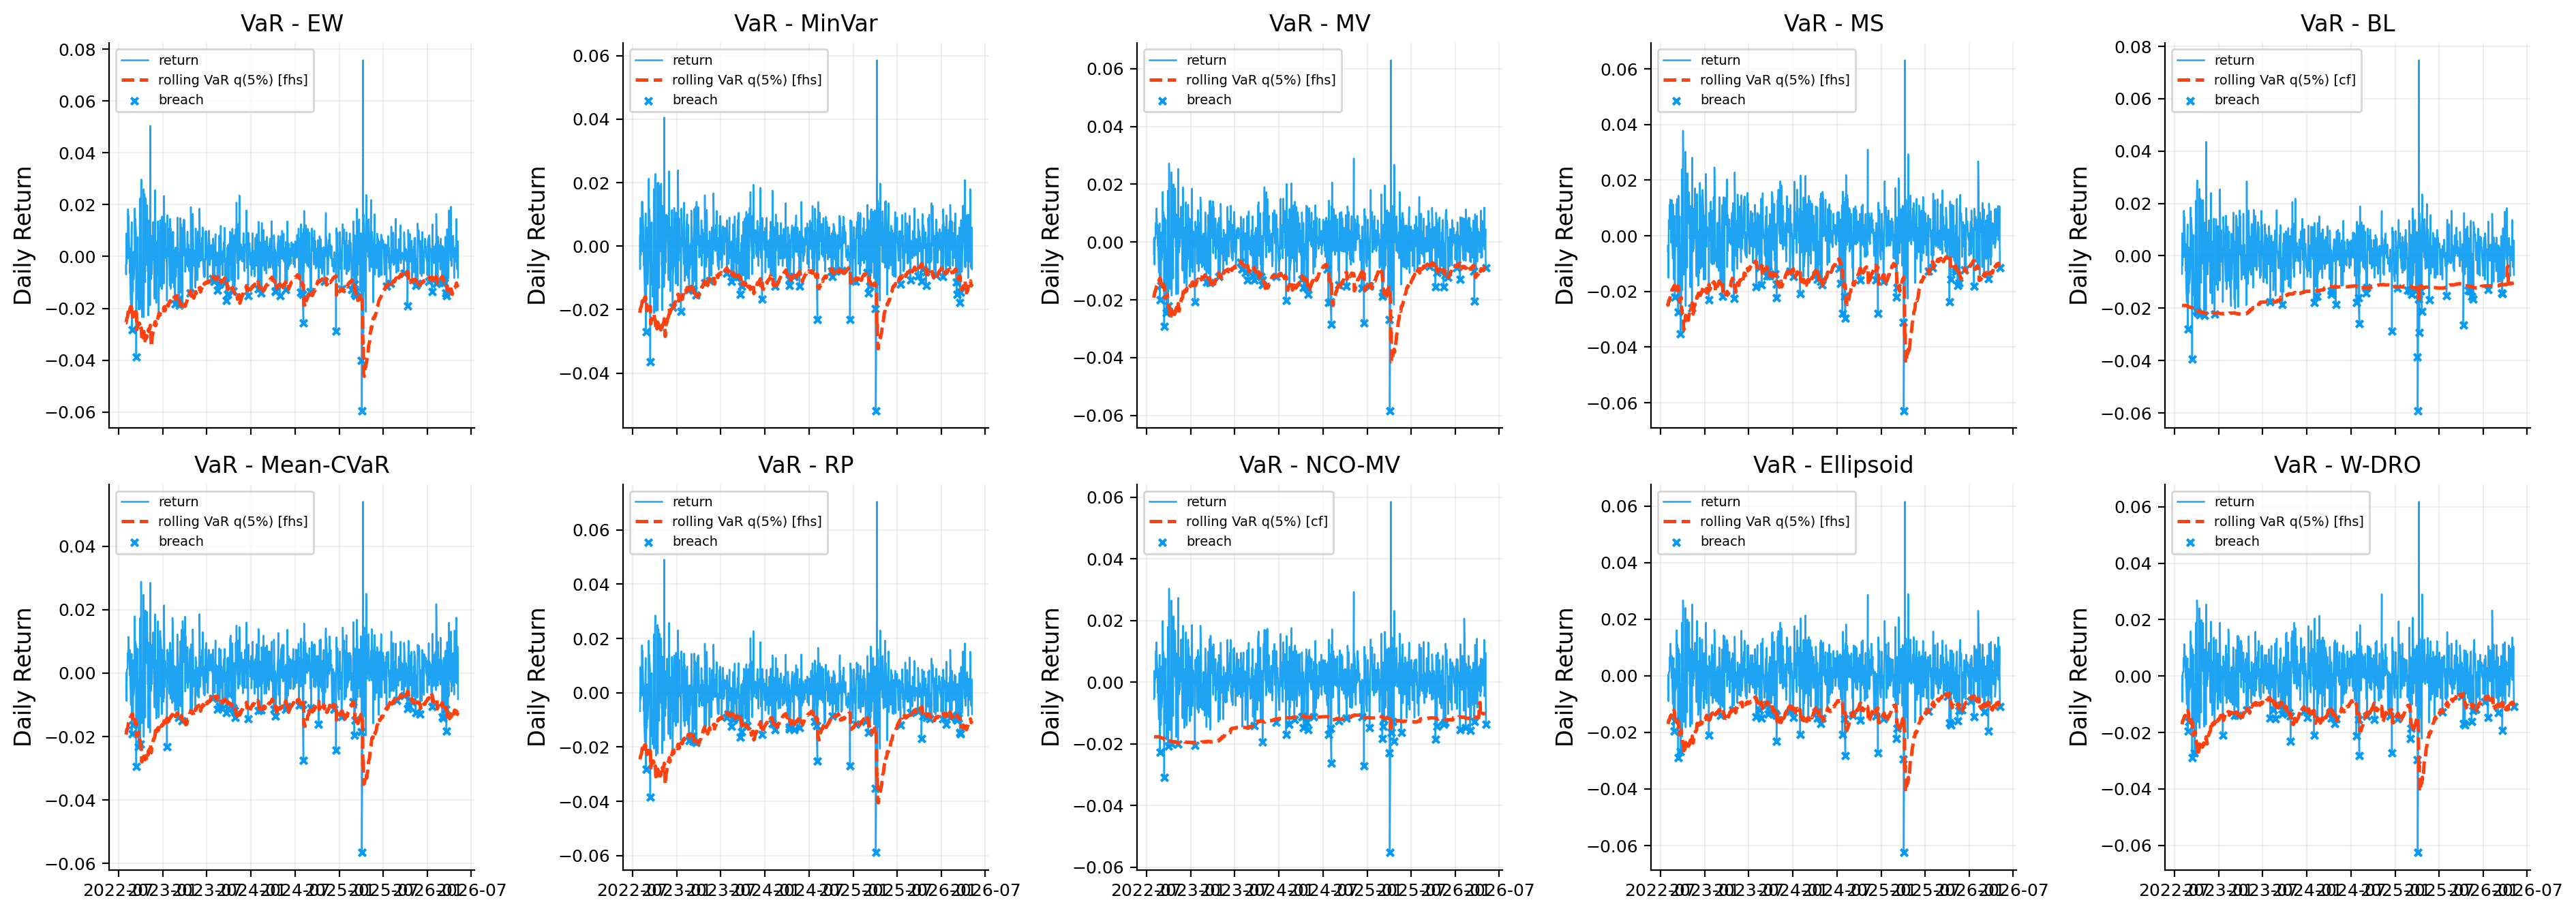

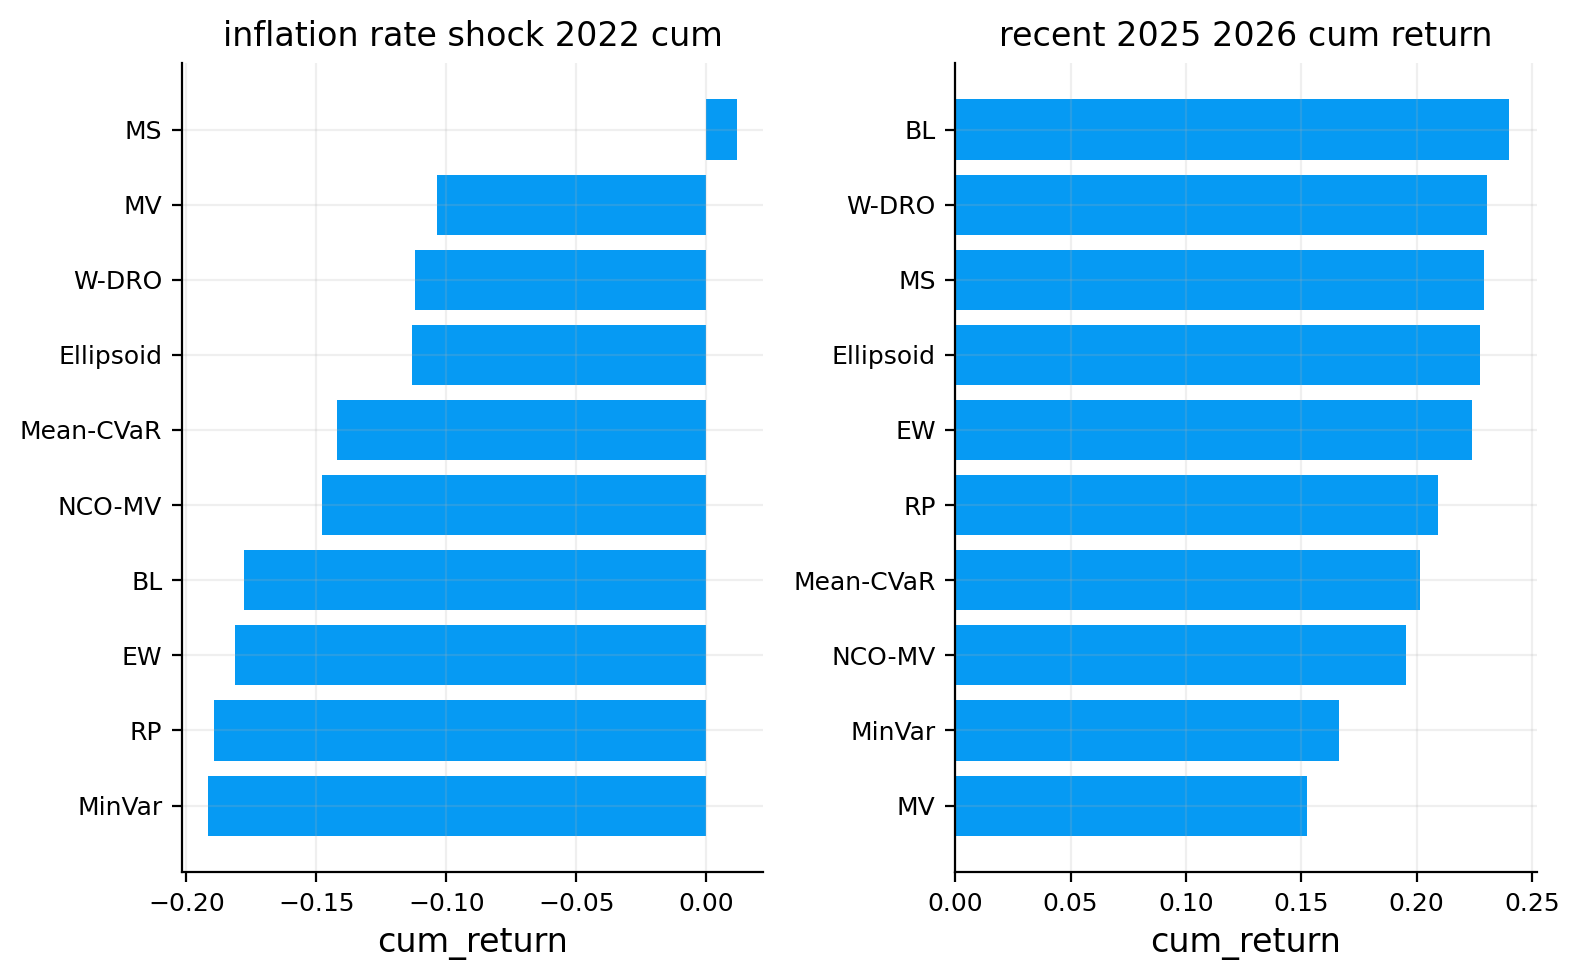

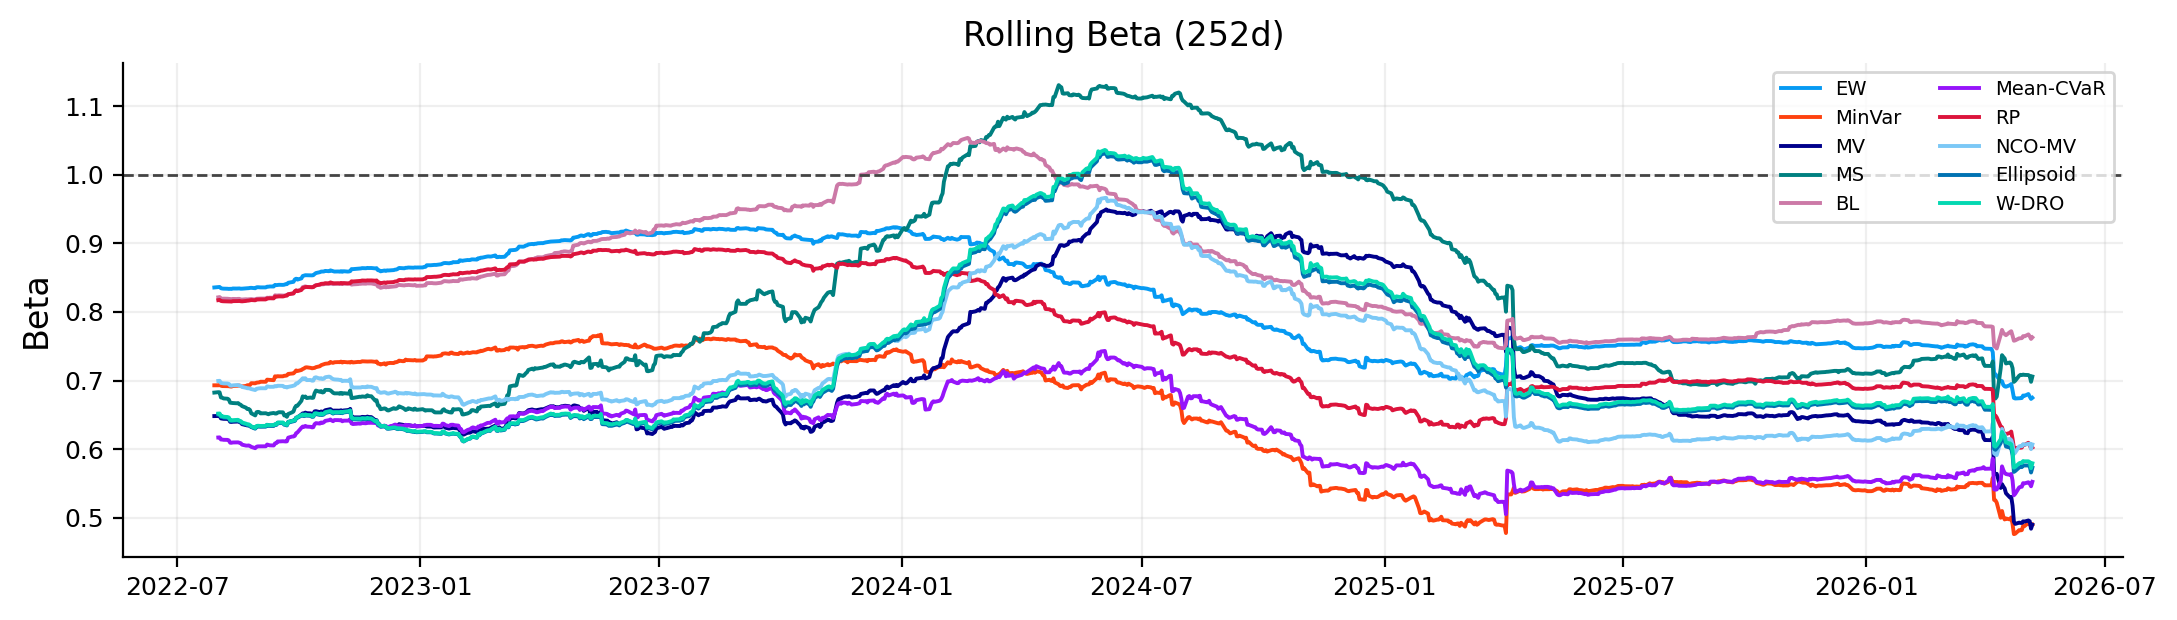

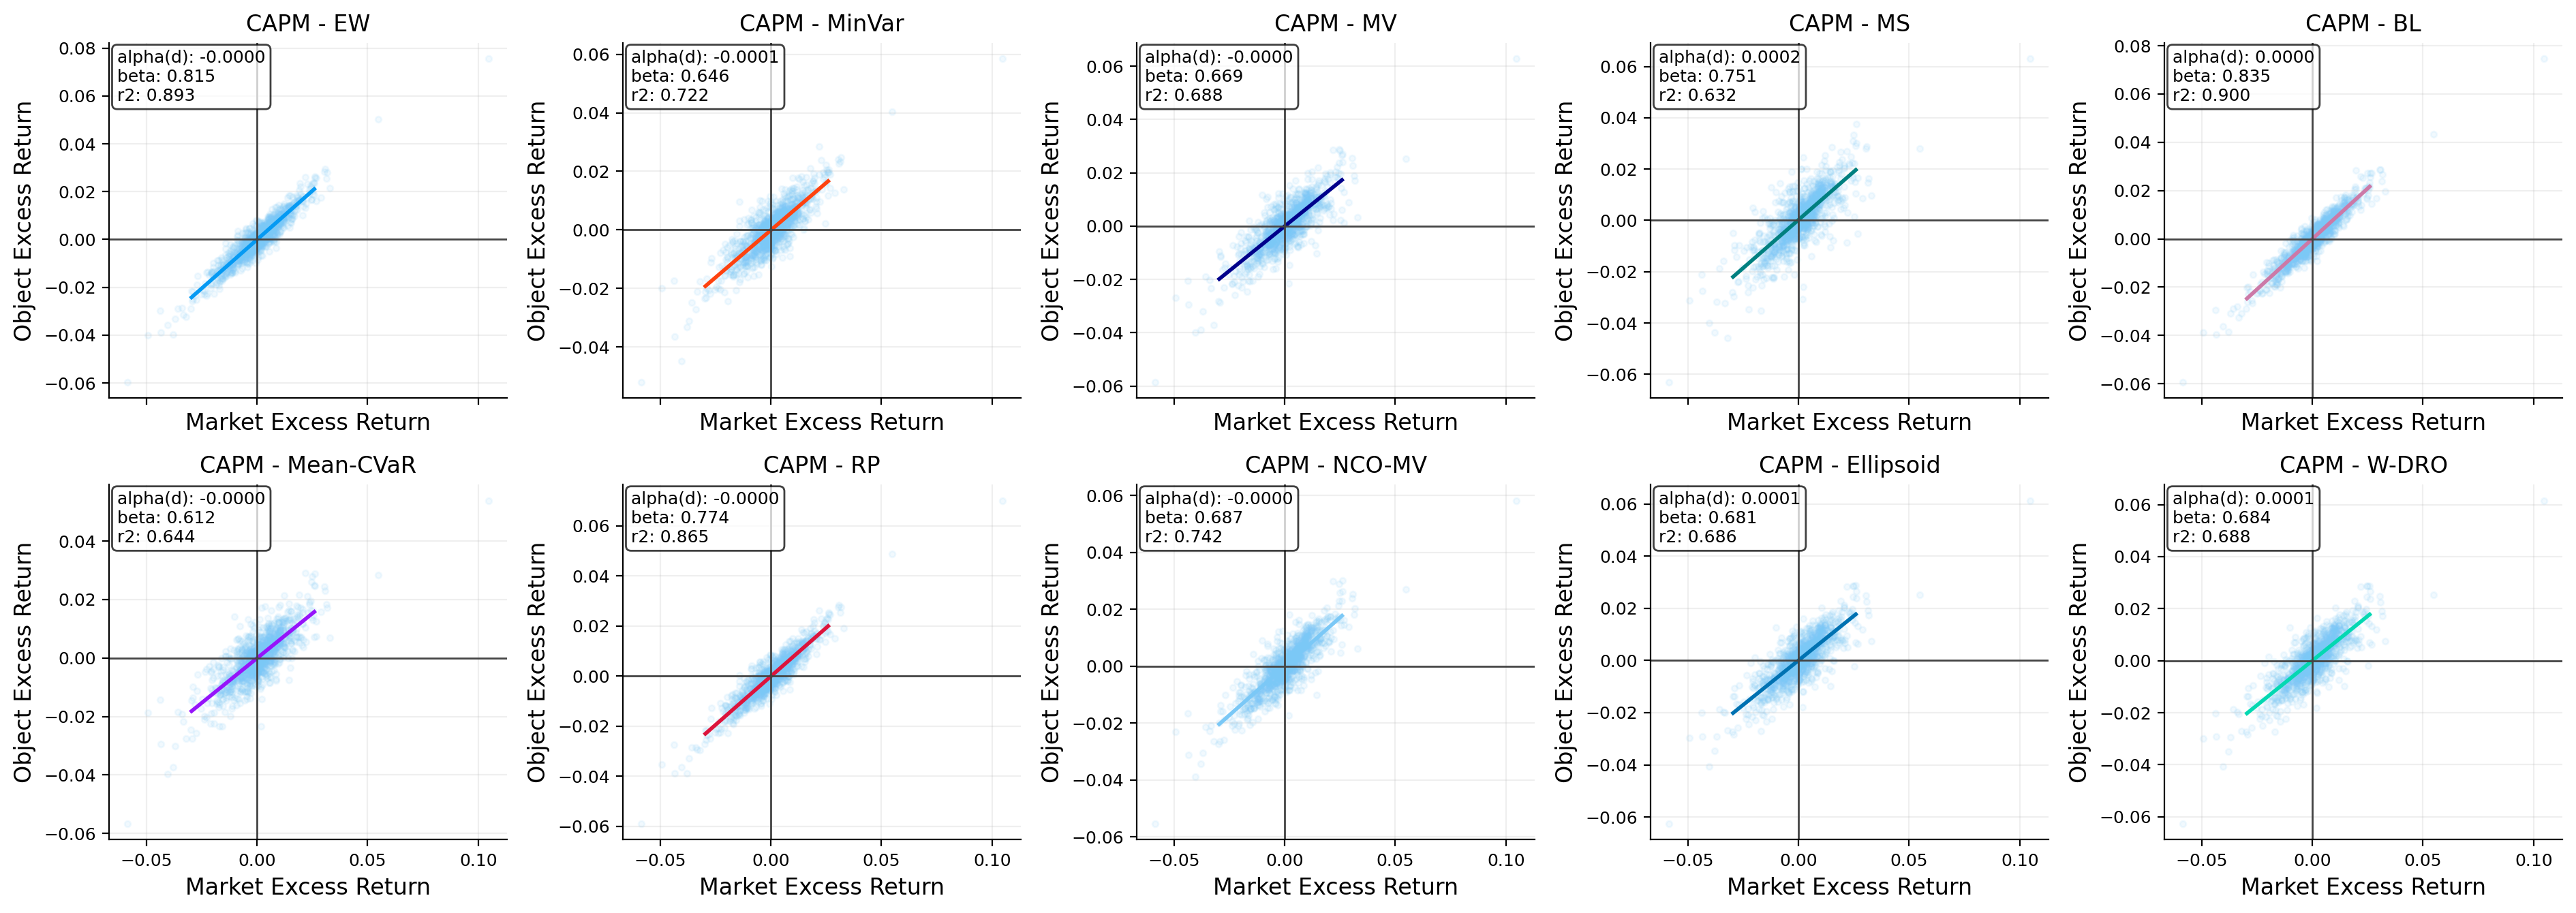

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cycler import cycler
from IPython.display import display

from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import prices_to_returns, make_rebalance_dates, selection
from quantfinlab.portfolio.walkforward import run_walkforward_grid, append_frontiergrid_from_best_maxsharpe
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import views as bl_views
from quantfinlab.portfolio.cvar import min_cvar_weight_frame, mean_cvar_weight_frame, cvar_budget_path
from quantfinlab.portfolio.risk_parity import risk_parity_weight_frame, risk_contribution_table
from quantfinlab.portfolio.hrp import hrp_weight_frame, nco_mv_weight_frame, cluster_membership_table
from quantfinlab.portfolio.robust import box_robust_weight_frame, ellipsoid_robust_weight_frame, wasserstein_weight_frame, robust_radius_path
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.reports import risk_report
from quantfinlab.plotting.portfolio import (
    plot_average_weight_heatmap,
    plot_cvar_budget_path,
    plot_finalist_drawdowns,
    plot_finalist_metric_bar,
    plot_finalist_nav,
    plot_hrp_dendrogram,
    plot_nco_cluster_weights,
    plot_risk_contribution_bar,
    plot_risk_return_scatter,
    plot_sleeve_exposure_bar,
    plot_wasserstein_radius_path,
)

warnings.filterwarnings("ignore")

colors = [
    "#069AF3", "#FE420F", "#00008B", "#008080",
    "#CC79A7", "#DC143C", "#9614fa", "#0072B2",
    "#7BC8F6", "#04D8B2", "#800080", "#FF8072",
]

plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update(
    {
        "figure.figsize": (7, 3.5),
        "figure.dpi": 140,
        "savefig.dpi": 250,
        "axes.grid": True,
        "grid.alpha": 0.20,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7,
    }
)

sector_start = "2018-07-01"
annualization = 252
rebal_freq = "ME"
cov_lookback = 756
mu_lookback = 252
ewma_lambda = 0.97
risk_free_rate_annual = 0.04
risk_free_daily = (1.0 + risk_free_rate_annual) ** (1.0 / annualization) - 1.0
cost_bps = 10.0
w_min = 0.0
w_max = 0.40
mv_lambda = 6.0
alt_mv_lambda = 3.0

assets = ["XLK", "XLC", "XLY", "XLF", "XLI", "XLE", "XLB", "XLV", "XLP", "XLU", "XLRE"]
signal_assets = ["SPY", "QQQ", "IWM", "TLT", "IEF", "SHY", "LQD", "HYG", "GLD", "DBC", "UUP"]

sleeve_map = {
    "XLK": "growth",
    "XLC": "growth",
    "XLY": "cyclical",
    "XLF": "cyclical",
    "XLI": "cyclical",
    "XLE": "cyclical",
    "XLB": "cyclical",
    "XLV": "defensive",
    "XLP": "defensive",
    "XLU": "defensive",
    "XLRE": "rate_sensitive",
}

label_map = {
    "Equal Weight": "EW",
    "MinVar": "MinVar",
    "MV": "MV",
    "MaxSharpe": "MaxSharpe",
    "Learned-Confidence BL": "BL",
    "Min-CVaR 95": "Min-CVaR",
    "Mean-CVaR 95": "Mean-CVaR",
    "Risk Parity": "RP",
    "HRP": "HRP",
    "NCO-MV": "NCO-MV",
    "Box Robust MV": "Box-Robust",
    "Ellipsoid Robust MV": "Ellipsoid",
    "Wasserstein DRMV": "W-DRO",
}

data_path = Path("../data/ETF_data.csv")
if not data_path.exists():
    data_path = Path("data/ETF_data.csv")

close_all = load_yfinance_panel(data_path, fields=("close",), lowercase=False, source="yfinance_export")["close"]
available_assets = [ticker for ticker in assets if ticker in close_all.columns]
available_signals = [ticker for ticker in signal_assets if ticker in close_all.columns]
if len(available_assets) != len(assets):
    raise ValueError(f"missing sector ETF data: {sorted(set(assets) - set(available_assets))}")

close = close_all.loc[pd.Timestamp(sector_start):, assets].ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)
close = close.reindex(returns.index).ffill(limit=3)

signal_tickers = list(dict.fromkeys(assets + available_signals))
signal_close = close_all.loc[returns.index.min():, signal_tickers].ffill(limit=3).reindex(returns.index).ffill(limit=3)
signal_returns = prices_to_returns(signal_close, kind="simple").replace([np.inf, -np.inf], np.nan).reindex(returns.index).fillna(0.0)

rebalance_dates = make_rebalance_dates(
    returns.index,
    freq=rebal_freq,
    min_history_days=max(cov_lookback, mu_lookback),
)

universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in rebalance_dates
}

print("sector returns:", returns.shape, returns.index.min().date(), "to", returns.index.max().date())
print("rebalance dates:", len(rebalance_dates), rebalance_dates[0].date(), "to", rebalance_dates[-1].date())

sector_grid = run_walkforward_grid(
    returns=returns,
    close=close,
    rebalance_dates=rebalance_dates,
    universe_by_date=universe_by_date,
    cov_lookback=cov_lookback,
    mu_lookback=mu_lookback,
    min_cov_observations=cov_lookback - 1,
    min_mu_observations=mu_lookback - 1,
    max_weight=w_max,
    min_weight=w_min,
    long_only=True,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=cost_bps,
    fallback="equal",
    rf_daily=risk_free_daily,
    annualization=annualization,
    ewma_lambda=ewma_lambda,
    optimizer_params={
        "MV": {"mv_lambda": mv_lambda},
        "RidgeMV": {"mv_lambda": mv_lambda},
        "FrontierGrid": {"grid_n": 15},
    },
)

sector_grid = append_frontiergrid_from_best_maxsharpe(sector_grid, metric="Sharpe", grid_n=25)
grid_summary = sector_grid.results.replace([np.inf, -np.inf], np.nan)

equal_grid_name = "EW" if "EW" in sector_grid.backtests else str(grid_summary.index[grid_summary["Optimizer"].eq("EW")][0])
minvar_name = str(grid_summary.loc[grid_summary["Optimizer"].eq("MinVar")].dropna(subset=["Sharpe"]).sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0])
mv_name = str(grid_summary.loc[grid_summary["Optimizer"].eq("MV")].dropna(subset=["Sharpe"]).sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0])
maxsharpe_candidates = grid_summary.loc[grid_summary["Optimizer"].eq("MaxSharpe")].dropna(subset=["Sharpe"])
if maxsharpe_candidates.empty:
    maxsharpe_candidates = grid_summary.loc[grid_summary["Optimizer"].eq("FrontierGrid")].dropna(subset=["Sharpe"])
maxsharpe_name = str(maxsharpe_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0])

_, _, minvar_cov = selection.parse_strategy_spec(minvar_name, sector_grid.backtests[minvar_name])
_, mv_mu, mv_cov = selection.parse_strategy_spec(mv_name, sector_grid.backtests[mv_name])
_, maxsharpe_mu, maxsharpe_cov = selection.parse_strategy_spec(maxsharpe_name, sector_grid.backtests[maxsharpe_name])

print("selected grid models:", {"MinVar": minvar_name, "MV": mv_name, "MaxSharpe": maxsharpe_name})

sector_benchmark_w = pd.Series(1.0 / len(assets), index=assets, dtype=float)
sector_roles_raw = {
    "assets": assets,
    "growth": ["XLK", "XLC", "XLY"],
    "defensive": ["XLP", "XLU", "XLV"],
    "cyclical": ["XLI", "XLF", "XLB", "XLE"],
    "inflation_beneficiaries": ["XLE", "XLB"],
    "rate_sensitive": ["XLU", "XLV", "XLRE"],
    "credit_sensitive": ["XLF", "XLY", "XLI"],
    "quality_defensive": ["XLV", "XLP"],
    "small_cap_sensitive": ["XLI", "XLF", "XLY"],
    "risky": assets,
    "sleeve_map": {ticker: "Sector" for ticker in assets},
}
sector_roles = {
    key: ([ticker for ticker in value if ticker in assets] if isinstance(value, list) else value)
    for key, value in sector_roles_raw.items()
}

sector_family_caps = {
    "sector_momentum": 0.012,
    "growth_leadership": 0.030,
    "defensive_rotation": 0.006,
    "cyclical_breadth": 0.020,
    "credit_beta": 0.012,
    "inflation_beneficiaries": 0.008,
    "duration_sensitive": 0.014,
    "small_cap_risk_on": 0.010,
    "quality_defensive": 0.004,
    "sector_reversal": 0.004,
}

sector_view_settings = bl_views.ViewSettings(
    family_q_caps=sector_family_caps,
    family_display_names=bl_views.DEFAULT_SECTOR_DISPLAY_NAMES,
    assets=assets,
    entry_z=0.50,
    q_strength_scale=1.25,
    annualization=annualization,
    view_horizon_days=21,
)

sector_bl_settings = bl.BLSettings(
    cov_lookback=504,
    mu_lookback=252,
    risk_free_rate_annual=risk_free_rate_annual,
    transaction_cost_bps=cost_bps,
    tau=0.05,
    ewma_lambda=ewma_lambda,
    max_weight=0.35,
    active_weight_limit=0.15,
    active_weight_relaxed=0.22,
    max_selected_views=5,
    redundancy_similarity=0.85,
    max_same_direction=3,
)

sector_view_functions = (
    bl_views.sector_momentum,
    bl_views.growth_leadership,
    bl_views.defensive_rotation,
    bl_views.cyclical_breadth,
    bl_views.credit_beta,
    bl_views.inflation_beneficiaries,
    bl_views.duration_sensitive,
    bl_views.small_cap_risk_on,
    bl_views.quality_defensive,
    bl_views.sector_reversal,
)

sector_asset_caps = pd.Series(sector_bl_settings.max_weight, index=assets, dtype=float)
sector_bl_run = bl.learned_confidence_bl(
    returns=returns,
    signal_returns=signal_returns,
    rebalance_dates=rebalance_dates,
    benchmark_weights=sector_benchmark_w,
    roles=sector_roles,
    view_functions=sector_view_functions,
    view_settings=sector_view_settings,
    settings=sector_bl_settings,
    constraints={"asset_caps": sector_asset_caps},
)

sector_bl_result = run_many_weights_backtests(
    {"Learned-Confidence BL": sector_bl_run.weights},
    returns=returns,
    cost_bps=cost_bps,
    rf_daily=risk_free_daily,
    w_min=sector_bl_settings.min_weight,
    w_max=sector_bl_settings.max_weight,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)["Learned-Confidence BL"]

print("BL view rows:", len(sector_bl_run.candidate_view_log), "candidate,", len(sector_bl_run.selected_view_log), "selected")

benchmark_results = {
    "Equal Weight": sector_grid.backtests[equal_grid_name],
    "MinVar": sector_grid.backtests[minvar_name],
    "MV": sector_grid.backtests[mv_name],
    "MaxSharpe": sector_grid.backtests[maxsharpe_name],
    "Learned-Confidence BL": sector_bl_result,
}

benchmark_table = selection.build_strategy_summary(
    benchmark_results,
    rf_daily=risk_free_daily,
    annualization=annualization,
)
display(benchmark_table[["CAGR", "Vol", "Sharpe", "Sortino", "Calmar", "Max Drawdown", "Turnover", "Effective N"]].round(4))

weights_min_cvar = min_cvar_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=minvar_cov,
    alpha=0.95,
    w_min=w_min,
    w_max=w_max,
)

weights_mean_cvar = mean_cvar_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    reference="equal",
    alpha=0.95,
    budget_scale=0.90,
    w_min=w_min,
    w_max=w_max,
)

weights_rp = risk_parity_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=minvar_cov,
    w_min=w_min,
    w_max=w_max,
)

weights_hrp = hrp_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=minvar_cov,
    linkage_method="average",
    w_min=w_min,
    w_max=w_max,
)

weights_nco = nco_mv_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    n_clusters=3,
    inner_lambda=alt_mv_lambda,
    outer_lambda=alt_mv_lambda,
    cluster_cap=0.75,
    linkage_method="average",
    w_min=w_min,
    w_max=w_max,
)

weights_box = box_robust_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    radius=0.25,
    mv_lambda=alt_mv_lambda,
    w_min=w_min,
    w_max=w_max,
)

weights_ellipsoid = ellipsoid_robust_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    radius=0.25,
    mv_lambda=alt_mv_lambda,
    w_min=w_min,
    w_max=w_max,
)

weights_wasserstein = wasserstein_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    radius=0.10,
    mv_lambda=alt_mv_lambda,
    w_min=w_min,
    w_max=w_max,
)

weights_by_name = {
    "Min-CVaR 95": weights_min_cvar,
    "Mean-CVaR 95": weights_mean_cvar,
    "Risk Parity": weights_rp,
    "HRP": weights_hrp,
    "NCO-MV": weights_nco,
    "Box Robust MV": weights_box,
    "Ellipsoid Robust MV": weights_ellipsoid,
    "Wasserstein DRMV": weights_wasserstein,
}

results = dict(benchmark_results)
results.update(
    run_many_weights_backtests(
        weights_by_name,
        returns=returns,
        cost_bps=cost_bps,
        rf_daily=risk_free_daily,
        w_min=w_min,
        w_max=w_max,
        long_only=True,
        normalize=True,
        weight_timing="next_close",
    )
)

summary = selection.build_strategy_summary(
    results,
    rf_daily=risk_free_daily,
    annualization=annualization,
).sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False])

best_cvar = summary.loc[["Min-CVaR 95", "Mean-CVaR 95"]].sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False]).index[0]
best_hier = summary.loc[["HRP", "NCO-MV"]].sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False]).index[0]
best_robust = summary.loc[["Box Robust MV", "Ellipsoid Robust MV"]].sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False]).index[0]

finalists = list(
    dict.fromkeys(
        [
            "Equal Weight",
            "MinVar",
            "MV",
            "MaxSharpe",
            "Learned-Confidence BL",
            best_cvar,
            "Risk Parity",
            best_hier,
            best_robust,
            "Wasserstein DRMV",
        ]
    )
)

final_table = summary.loc[finalists, ["CAGR", "Vol", "Sharpe", "Sortino", "Calmar", "Max Drawdown", "Turnover", "Effective N"]]
display(final_table.round(4))

nav = pd.concat({name: results[name].net_values for name in finalists}, axis=1)
returns_final = pd.concat({name: results[name].net_returns for name in finalists}, axis=1).dropna(how="all")
weights_final = {name: results[name].weights for name in finalists}

latest_dt = pd.Timestamp(weights_wasserstein.index[-1])
latest_state = sector_grid.cache[latest_dt]
latest_tickers = list(latest_state["tickers"])
latest_cov = pd.DataFrame(latest_state["cov_ann_map"][maxsharpe_cov], index=latest_tickers, columns=latest_tickers)
latest_mu = latest_state["mu_ann_map"][maxsharpe_cov][maxsharpe_mu].reindex(latest_tickers).fillna(0.0)

cvar_path = cvar_budget_path(
    returns=latest_state["R_cov"].reindex(columns=latest_tickers),
    mu_ann=latest_mu,
    budget_scales=[0.80, 0.90, 1.00, 1.10, 1.25],
    alpha=0.95,
    w_min=w_min,
    w_max=w_max,
)

rp_table = risk_contribution_table(
    weights=weights_rp.iloc[-1].reindex(latest_tickers).fillna(0.0),
    cov_ann=latest_state["cov_ann_map"][minvar_cov],
)

cluster_table = cluster_membership_table(
    cov_ann=latest_state["cov_ann_map"][maxsharpe_cov],
    tickers=latest_tickers,
    n_clusters=3,
    linkage_method="average",
)

wasserstein_path = robust_radius_path(
    model="wasserstein",
    mu_ann=latest_mu,
    cov_ann=latest_cov,
    n_mu_obs=len(latest_state["R_mu"]),
    radii=[0.0, 0.05, 0.10, 0.25, 0.50, 1.00],
    mv_lambda=alt_mv_lambda,
    w_min=w_min,
    w_max=w_max,
)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.ravel()

plot_cvar_budget_path(cvar_path, ax=axes[0], title="Mean-CVaR budget path")
plot_risk_contribution_bar(rp_table, ax=axes[1], title="Risk Parity risk contribution")
plot_hrp_dendrogram(latest_state["cov_ann_map"][maxsharpe_cov], labels=latest_tickers, linkage_method="average", ax=axes[2], title="sector cluster tree")
plot_nco_cluster_weights(cluster_table, weights_nco.iloc[-1], ax=axes[3], title="NCO-MV cluster allocation")
plot_finalist_nav(nav, strategies=finalists, ax=axes[4], title="net wealth", short_labels=label_map)
plot_finalist_drawdowns(nav, strategies=finalists, ax=axes[5], title="drawdowns", short_labels=label_map)
plot_wasserstein_radius_path(wasserstein_path, ax=axes[6], title="Wasserstein radius path")
plot_average_weight_heatmap(weights_final, ax=axes[7], title="average finalist weights", short_labels=label_map)
plot_sleeve_exposure_bar(weights_final, sleeve_map, ax=axes[8], title="average sleeve exposure", short_labels=label_map)
plot_risk_return_scatter(final_table, ax=axes[9], title="risk-return", risk_col="Vol", return_col="CAGR", color_col="Sharpe", short_labels=label_map)
plot_finalist_metric_bar(final_table, metric="Sharpe", ax=axes[10], title="Sharpe", short_labels=label_map)
plot_finalist_metric_bar(final_table, metric="Max Drawdown", ax=axes[11], title="max drawdown", short_labels=label_map)

plt.tight_layout()
plt.show()

stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "covid_crash_2020": ("2020-02-19", "2020-03-23"),
    "inflation_rate_shock_2022": ("2022-01-03", "2022-10-14"),
}

if returns_final.index.max() >= pd.Timestamp("2025-01-01"):
    stress_windows["recent_2025_2026"] = ("2025-01-01", str(returns_final.index.max().date()))

market_ret = signal_returns["SPY"].reindex(returns_final.index) if "SPY" in signal_returns.columns else returns.mean(axis=1).reindex(returns_final.index)

sector_risk_report = risk_report(
    objects={name: returns_final[name].dropna() for name in finalists},
    market_ret=market_ret,
    rf_daily=risk_free_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    rolling_settings={"vol_windows": [252], "beta_windows": [252]},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": 5, "sharex": True, "sharey": False},
    output={
        "display_table_keys": ["var_es"],
        "round_tables": 4,
        "print_exec_bullets": False,
        "show_figures": False,
        "short_labels": True,
        "label_max_len": 12,
        "label_map": label_map,
    },
)

for key in ["var_backtest", "stress", "rolling_beta"]:
    for fig in sector_risk_report.figures.get(key, []):
        display(fig)
        plt.close(fig)

